In [ ]:
#use the corv_wd_models.yml environment

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import interpolate
from scipy.optimize import curve_fit
from scipy import stats
from IPython.display import Image

from astropy.table import Table, Column, MaskedColumn, join, vstack
from astropy.coordinates import SkyCoord
from astropy.coordinates import CartesianRepresentation, CartesianDifferential
import astropy.units as u
from astropy.coordinates import LSR
from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord, LSR, ICRS, CartesianDifferential, Distance

import pandas as pd
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# Suppress SettingWithCopyWarnings
pd.options.mode.chained_assignment = None  # default='warn'

#put the path the WD_models and import the module
import sys
import os
sys.path.append('../Software')
import WD_models

plt.style.use('stefan.mplstyle')

# This notebook calculates masses for each WD and LSR corrections to the RV. Then we perform data quality cuts to get the final sample for the EoS plots and correct the RVs for the asymmetric drift of this sample and bin the sample in radius/surface gravity. We then save the final full samples and the final temperature dependence samples.

# Import the datasets


In [3]:
SDSSV_tab=pd.read_csv('csv/SDSSV_DA_df.csv')
eSDSS_tab=pd.read_csv('csv/eSDSS_DA_df.csv')

# Import the La Plata WD Models
- http://evolgroup.fcaglp.unlp.edu.ar/TRACKS/newtables.html
- Varying H-layer thickness according to mass of WD, more massive WDs have thicker H layers than less massive
- DAmassradiusZ0.02.txt gives DA mass/radius in solar units as function of logg/log teff
    - He-core: Althaus et al. 2013, CO-core: Camisassa et al. 2016,    ONe-core: Camisassa et al. 2019

In [4]:
la_plata_mass=pd.read_csv('data/whitedwarfsZ0.02/DAmassradiusZ0.02_readable.txt',delimiter=' ')
la_plata_mass=la_plata_mass.rename(columns={"Unnamed: 1": "logteff"})
la_plata_mass=la_plata_mass.drop(['log(teff)/log(g)'],axis=1)
#reset the indices
indices=np.arange(0,len(la_plata_mass))
la_plata_mass.set_index(indices,inplace=True)

la_plata_radius=pd.read_csv('data/whitedwarfsZ0.02/DAmassradiusZ0.02_readable.txt',delimiter=' ')
la_plata_radius=la_plata_radius.rename(columns={"Unnamed: 1": "logteff"})
la_plata_radius=la_plata_radius.drop(['log(teff)/log(g)'],axis=1)
#reset the indices
indices=np.arange(0,len(la_plata_radius))
la_plata_radius.set_index(indices,inplace=True)

#separate mass and radius info
for col in la_plata_mass.columns.to_list()[1:]:
    masses=[]
    radii=[]
    for i in range(len(la_plata_mass)):
        mass,radius=la_plata_mass[col][i].split(',')
        masses.append(float(mass))
        radii.append(float(radius))
    la_plata_mass[col]=masses
    la_plata_radius[col]=radii

In [5]:
#turn models into interpolation grids

#make grid of mass/radius as function of teff/logg
rows=la_plata_mass['logteff']
teffs = 10**(rows)
columns=la_plata_radius.columns.to_list()[1:]
loggs=[float(i) for i in columns]
mass_teff_logg_grid = np.zeros((len(teffs), len(loggs), 1))
radius_teff_logg_grid = np.zeros((len(teffs), len(loggs), 1))
for i in range(len(teffs)):
    for j in range(len(loggs)):
        logteff=rows[i]
        mass_teff_logg_grid[i,j] = la_plata_mass.query('logteff==@logteff')[columns[j]]
        radius_teff_logg_grid[i,j] = la_plata_radius.query('logteff==@logteff')[columns[j]]
    
#get equal-sized arrays
teffs_long=[]
loggs_long=[]
masses_long=[]
radii_long=[]
for i in range(len(teffs)):
    for j in range(len(loggs)):
        logteff=rows[i]
        teff=teffs[i]
        logg=loggs[j]
        mass= la_plata_mass.query('logteff==@logteff')[columns[j]].to_list()[0]
        radius= la_plata_radius.query('logteff==@logteff')[columns[j]].to_list()[0]
        teffs_long.append(teff)
        loggs_long.append(logg)
        masses_long.append(mass)
        radii_long.append(radius)   
teffs_long=np.asarray(teffs_long)
loggs_long=np.asarray(loggs_long)
masses_long=np.asarray(masses_long)
radii_long=np.asarray(radii_long)

#define the interpolation functions
mass_from_logg_teff=WD_models.interp_xy_z_func(x=loggs_long, y=teffs_long, z=masses_long, interp_type='linear')     
mass_from_radius_teff=WD_models.interp_xy_z_func(x=radii_long, y=teffs_long, z=masses_long, interp_type='linear')  
radius_from_logg_teff=WD_models.interp_xy_z_func(x=loggs_long, y=teffs_long, z=radii_long, interp_type='linear')  
radius_from_mass_teff=WD_models.interp_xy_z_func(x=masses_long, y=teffs_long, z=radii_long, interp_type='linear')  


# Add the masses to the data frame

- mass_rad_logg is obtained by combining the measured photometric radius with the measured spectroscopic logg

$$M(R,\log{g})=gR^2/G=10^{\log{g}}R^2/G$$
$$\delta M(R,\log{g})=\frac{10^{\log{g}}R}{G}\sqrt{4\delta R^2+(R\ln{10})^2\delta(\log{g})^2}$$

- mass_logg_theory is obtained by combining the measured spectroscopic logg and spectroscopic effective temperature with the La Plata models
    - The error on this quantity is taken from calculating the masses at the endpoints of the logg and teff errorbars and taking the largest difference in masses
- mass_radius_theory is obtained by combining the measured photometric radius and photometric effective temperature with the La Plata models
    - The error on this quantity is taken from calculating the masses at the endpoints of the logg and teff errorbars and taking the largest difference in masses

In [5]:
MsunCGS=1.989*10**33 #g
RsunCGS=6.955*10**10 #cm
cCGS=2.99792458*10**10 #cm/s
GCGS=6.6743*10**(-8) #cm^3 g^-1 s^-2

def data_m_from_r_logg(radii,loggs,e_radii,e_loggs):
    #compute the mass and error on the mass in solar units
    #given measured radius and logg
    masses=[]
    e_masses=[]
    #convert radii from solar units to CGS units
    radii=radii*RsunCGS
    e_radii=e_radii*RsunCGS
    #get the surface gravity
    gs=10**(loggs)
    for i in range(len(radii)):
        M=(gs[i]*(radii[i]**2)/GCGS)/MsunCGS
        masses.append(M)
        E_M=((gs[i]*radii[i]/GCGS)*np.sqrt(4*(e_radii[i]**2)+((radii[i]*np.log(10))**2)*(e_loggs[i]**2)))/MsunCGS
        e_masses.append(E_M)
    return(masses,e_masses)

def data_m_from_logg_theory(loggs,teffs,e_loggs,e_teffs):
    #compute the mass and error on the mass in solar units
    #given measured logg and teff
    masses=[]
    e_masses=[]
    for i in range(len(loggs)):
        #get the logg/teff and their mins and maxes
        logg=loggs[i]
        e_logg=e_loggs[i]
        teff=teffs[i]
        e_teff=e_teffs[i]
        logg_min=logg-e_logg
        logg_max=logg+e_logg
        teff=teffs[i]
        teff_min=teff-e_teff
        teff_max=teff+e_teff
        #calculate the mass and all possible masses
        M=mass_from_logg_teff(logg,teff)
        E_M_array=mass_from_logg_teff([logg_min,logg_min,logg_max,logg_max],[teff_min,teff_max,teff_min,teff_max])
        E_M=max(E_M_array)-min(E_M_array)
        masses.append(M.item())
        e_masses.append(E_M.item())
    return(masses,e_masses)

def data_m_from_rad_theory(radii,teffs,e_radii,e_teffs):
    #compute the mass and error on the mass in solar units
    #given measured radius and teff
    masses=[]
    e_masses=[]
    for i in range(len(radii)):
        #get the logg/teff and their mins and maxes
        rad=radii[i]
        e_rad=e_radii[i]
        teff=teffs[i]
        e_teff=e_teffs[i]
        rad_min=rad-e_rad
        rad_max=rad+e_rad
        teff=teffs[i]
        teff_min=teff-e_teff
        teff_max=teff+e_teff
        #calculate the mass and all possible masses
        M=mass_from_radius_teff(rad,teff)
        E_M_array=mass_from_radius_teff([rad_min,rad_min,rad_max,rad_max],[teff_min,teff_max,teff_min,teff_max])
        E_M=max(E_M_array)-min(E_M_array)
        masses.append(M.item())
        e_masses.append(E_M.item())
    return(masses,e_masses)


In [6]:
def add_masses(table):
    #compute the mass in solar units using coadded spectral parameters
    
    #from measured logg and measured radius
    mass_rad_logg, e_mass_rad_logg=data_m_from_r_logg(table['radius_phot'],table['logg_prf_coadd'],table['e_radius_phot_full'],
                                table['e_logg_prf_coadd_full'])
    
    #from measured logg/teff and theory
    mass_logg_theory, e_mass_logg_theory=data_m_from_logg_theory(table['logg_prf_coadd'],table['teff_prf_coadd'],table['e_logg_prf_coadd_full'],
                                table['e_teff_prf_coadd_full'])
    
    #from measured radius/teff and theory
    mass_rad_theory, e_mass_rad_theory=data_m_from_rad_theory(table['radius_phot'],table['teff_phot'],table['e_radius_phot_full'],
                                table['e_teff_phot_full'])
    
    table['mass_rad_logg']=mass_rad_logg
    table['e_mass_rad_logg']=e_mass_rad_logg
    
    table['mass_logg_theory']=mass_logg_theory
    table['e_mass_logg_theory']=e_mass_logg_theory
    
    table['mass_rad_theory']=mass_rad_theory
    table['e_mass_rad_theory']=e_mass_rad_theory

    
    return(table)

In [7]:
SDSSV_tab=add_masses(SDSSV_tab)
eSDSS_tab=add_masses(eSDSS_tab)

### Compare our masses to the Kepler DR14 mass distribution

In [8]:
filename='keplerDR14_table3.dat.gz.txt'

#read in the DR14 table data
DR14_df = pd.read_csv('data/'+filename,delimiter='|')
#drop the last row of NaNs and the first row of dashes
DR14_df=DR14_df.dropna()
DR14_df=DR14_df.drop([0])
#reset the indices
indices=np.arange(0,len(DR14_df))
DR14_df.set_index(indices,inplace=True)
#remove space from column names
DR14_df.columns = DR14_df.columns.str.replace(' ', '')
#separate into plate, mjd, and fiber columns
plates=[]
mjds=[]
fibers=[]
for pmf in DR14_df['P-M-F'].to_list():
    plate,mjd,fiber=pmf.split('-')
    plates.append(plate)
    mjds.append(mjd)
    fibers.append(fiber)
DR14_df['plate']=plates
DR14_df['mjd']=mjds
DR14_df['fiber']=fibers
#standardize PMFs to compare across data releases
cols=['plate','mjd','fiber']
for col in cols:
    DR14_df[col]=DR14_df[col].astype(int) #convert first to integer to strip 0s
    DR14_df[col]=DR14_df[col].astype(str) #convert back to string
#add unique PMF identifyer
DR14_df['pmf']=DR14_df['plate']+DR14_df['mjd']+DR14_df['fiber']
DR14_df['pmf']=DR14_df['pmf'].astype(int)
#rename columns
DR14_df=DR14_df.rename(columns={'S/N':'snr_sdss_dr',"Teff":"teff1d","e_Teff": "e_teff","logg":"logg1d","e_logg":"e_logg","RV":"rv",
                                "e_RV":"e_rv","Mass":"mass1d","e_Mass":"e_mass1d","Teff3D":"teff","logg3D":"logg",
                                "Mass3D":"mass","e_":"e_mass"})
#replace ' ---  ' signifying no measurement with np.nans
DR14_df=DR14_df.replace(' ---  ', np.nan)
DR14_df=DR14_df.replace('---  ', np.nan)
#convert to floats
cols=['snr_sdss_dr','teff', 'e_teff', 'logg', 'e_logg', 'rv', 'e_rv','mass', 'e_mass','teff1d','logg1d','mass1d','e_mass1d']
for col in cols:
    DR14_df[col]=DR14_df[col].astype(float)
#calculate the radius in solar units
DR14_df['radius']=(1/RsunCGS)*np.sqrt(GCGS*MsunCGS*DR14_df['mass']/10**DR14_df['logg'])
DR14_df['radius1d']=(1/RsunCGS)*np.sqrt(GCGS*MsunCGS*DR14_df['mass1d']/10**DR14_df['logg1d'])
#calculate errors on the radius
DR14_df['e_radius']=DR14_df['radius']*np.sqrt(((1/(4*(DR14_df['mass'])**2))*(DR14_df['e_mass'])**2)+((1/4)*((np.log(10))**2)*(DR14_df['e_logg'])**2))
DR14_df['e_radius1d']=DR14_df['radius1d']*np.sqrt(((1/(4*(DR14_df['mass1d'])**2))*(DR14_df['e_mass1d'])**2)+((1/4)*((np.log(10))**2)*(DR14_df['e_logg'])**2))
#convert the SDSS name to coordinates
ras=[]
decs=[]
for i in range(len(DR14_df)):
    hour=DR14_df['SDSSJ'][i][:2]
    minit=DR14_df['SDSSJ'][i][2:4]
    sec=DR14_df['SDSSJ'][i][4:9]
    sign=DR14_df['SDSSJ'][i][9:10]
    deg=DR14_df['SDSSJ'][i][10:12]
    arcmin=DR14_df['SDSSJ'][i][12:14]
    arcsec=DR14_df['SDSSJ'][i][14:]
    ra=str(hour)+'h'+str(minit)+'m'+str(sec)+'s'
    dec=str(sign)+str(deg)+'d'+str(arcmin)+'m'+str(arcsec)+'s'
    coord=SkyCoord(ra, dec)
    ras.append(float(coord.to_string('decimal').split()[0]))
    decs.append(float(coord.to_string('decimal').split()[1]))
DR14_df['ra_sdss_dr']=ras
DR14_df['dec_sdss_dr']=decs

#drop all extra columns
DR14_df=DR14_df.drop(['P-M-F', 'SDSSJ','SNg','umag', 'e_umag', 'gmag', 'e_gmag', 'rmag', 'e_rmag', 'imag', 'e_imag', 'zmag',
                  'e_zmag', 'E(B-V)', 'PM','GLONGLAT', 'DT(SP)', 'd', 'z','DTeff', 'Dlogg',
                  'plate', 'mjd', 'fiber','Type'],axis=1)

In [9]:
#define a function to bootstrap calculating a median
def bootstrap_median(data, n_iterations=1000):
    full_median=np.nanmedian(data)
    
    medians = []
    for _ in range(n_iterations):
        # Sample with replacement
        sample = np.random.choice(data, size=len(data), replace=True)
        # Calculate the median of the resampled data
        median = np.nanmedian(sample)
        medians.append(median)
    
    # Return the full median and std of the medians
    return (full_median, np.std(medians))


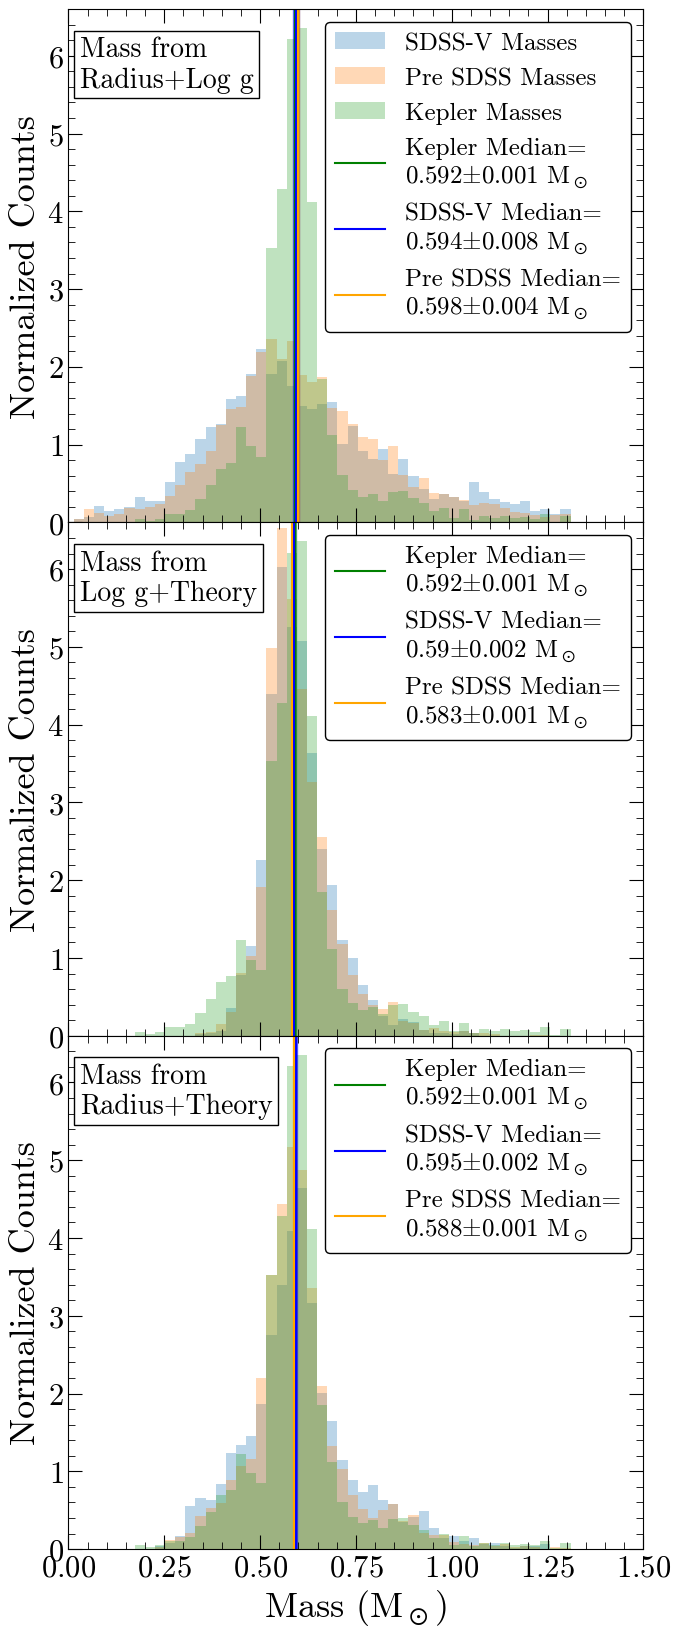

In [10]:
#make quality cut of coadd spectrum SNR>20 and remove binaries
#we use only coadds so drop duplicate gaia dr3 source ids

snr_cut=20

SDSSV_tab_cut=SDSSV_tab.drop_duplicates(subset='gaia_dr3_source_id').query('snr_coadd>@snr_cut & binary_flag==0')
eSDSS_tab_cut=eSDSS_tab.drop_duplicates(subset='gaia_dr3_source_id').query('snr_coadd>@snr_cut & binary_flag==0')
DR14_df_cut=DR14_df.query('snr_sdss_dr>@snr_cut')

#calculate medians and stds (found by bootstrapping)
med_kepler,std_kepler=bootstrap_median(DR14_df_cut['mass'].astype('float').to_list())
med_sdssv_rad_logg,std_sdssv_rad_logg=bootstrap_median(SDSSV_tab_cut['mass_rad_logg'])
med_esdss_rad_logg,std_esdss_rad_logg=bootstrap_median(eSDSS_tab_cut['mass_rad_logg'])
med_sdssv_logg_theory,std_sdssv_logg_theory=bootstrap_median(SDSSV_tab_cut['mass_logg_theory'])
med_esdss_logg_theory,std_esdss_logg_theory=bootstrap_median(eSDSS_tab_cut['mass_logg_theory'])
med_sdssv_rad_theory,std_sdssv_rad_theory=bootstrap_median(SDSSV_tab_cut['mass_rad_theory'])
med_esdss_rad_theory,std_esdss_rad_theory=bootstrap_median(eSDSS_tab_cut['mass_rad_theory'])

fig, ((ax1),(ax2),(ax3)) = plt.subplots(3, 1,figsize=(10,20),sharey=True,sharex=True)

#set bin size
bins=np.linspace(0.014,1.310,50)

#plot the Kepler measured masses vs our eSDSS and SDSS-V distributions
ax1.hist(SDSSV_tab_cut['mass_rad_logg'],bins=bins,density=True,histtype='stepfilled',alpha=0.3,label='SDSS-V Masses')
ax1.hist(eSDSS_tab_cut['mass_rad_logg'],bins=bins,density=True,histtype='stepfilled',alpha=0.3,label='Pre SDSS Masses')
ax1.hist(DR14_df_cut['mass'].astype('float').to_list(), bins=bins,density=True,histtype='stepfilled',alpha=0.3,label='Kepler Masses')
ax1.axvline(med_kepler,color='green',label='Kepler Median=\n'+str(np.round(med_kepler,3))+r'$\mathrm{\pm}$'+str(np.round(std_kepler,3))+' $M_\odot$')
ax1.axvspan(med_kepler-std_kepler,med_kepler+std_kepler,color='green',alpha=0.5)
ax1.axvline(med_sdssv_rad_logg,color='blue',label='SDSS-V Median=\n'+str(np.round(med_sdssv_rad_logg,3))+r'$\mathrm{\pm}$'+str(np.round(std_sdssv_rad_logg,3))+' $M_\odot$')
ax1.axvspan(med_sdssv_rad_logg-std_sdssv_rad_logg,med_sdssv_rad_logg+std_sdssv_rad_logg,color='blue',alpha=0.5)
ax1.axvline(med_esdss_rad_logg,color='orange',label='Pre SDSS Median=\n'+str(np.round(med_esdss_rad_logg,3))+r'$\mathrm{\pm}$'+str(np.round(std_esdss_rad_logg,3))+' $M_\odot$')
ax1.axvspan(med_esdss_rad_logg-std_esdss_rad_logg,med_esdss_rad_logg+std_esdss_rad_logg,color='orange',alpha=0.5)
ax1.text(0.03, 5.6, 'Mass from\nRadius+Log g', fontsize = 20, bbox = dict(facecolor = 'white'))
ax1.set_ylabel('Normalized Counts')
ax1.set_ylim(0,6.6)
ax1.set_xlim(0,1.5)

#plot the Kepler measured masses vs our eSDSS and SDSS-V logg distributions
#converted to mass distributions
ax2.hist(SDSSV_tab_cut['mass_logg_theory'],bins=bins,density=True,histtype='stepfilled',alpha=0.3)
ax2.hist(eSDSS_tab_cut['mass_logg_theory'],bins=bins,density=True,histtype='stepfilled',alpha=0.3)
ax2.hist(DR14_df_cut['mass'].astype('float').to_list(), bins=bins,density=True,histtype='stepfilled',alpha=0.3)
ax2.axvline(med_kepler,color='green',label='Kepler Median=\n'+str(np.round(med_kepler,3))+r'$\mathrm{\pm}$'+str(np.round(std_kepler,3))+' $M_\odot$')
ax2.axvspan(med_kepler-std_kepler,med_kepler+std_kepler,color='green',alpha=0.5)
ax2.axvline(med_sdssv_logg_theory,color='blue',label='SDSS-V Median=\n'+str(np.round(med_sdssv_logg_theory,3))+r'$\mathrm{\pm}$'+str(np.round(std_sdssv_logg_theory,3))+' $M_\odot$')
ax2.axvspan(med_sdssv_logg_theory-std_sdssv_logg_theory,med_sdssv_logg_theory+std_sdssv_logg_theory,color='blue',alpha=0.5)
ax2.axvline(med_esdss_logg_theory,color='orange',label='Pre SDSS Median=\n'+str(np.round(med_esdss_logg_theory,3))+r'$\mathrm{\pm}$'+str(np.round(std_esdss_logg_theory,3))+' $M_\odot$')
ax2.axvspan(med_esdss_logg_theory-std_esdss_logg_theory,med_esdss_logg_theory+std_esdss_logg_theory,color='orange',alpha=0.5)
ax2.text(0.03, 5.6, 'Mass from\nLog g+Theory', fontsize = 20, bbox = dict(facecolor = 'white'))
ax2.set_ylabel('Normalized Counts')

#plot the Kepler measured masses vs our eSDSS and SDSS-V radius distributions
#converted to mass distributions
ax3.hist(SDSSV_tab_cut['mass_rad_theory'],bins=bins,density=True,histtype='stepfilled',alpha=0.3)
ax3.hist(eSDSS_tab_cut['mass_rad_theory'],bins=bins,density=True,histtype='stepfilled',alpha=0.3)
ax3.hist(DR14_df_cut['mass'].astype('float').to_list(), bins=bins,density=True,histtype='stepfilled',alpha=0.3)
ax3.axvline(med_kepler,color='green',label='Kepler Median=\n'+str(np.round(med_kepler,3))+r'$\mathrm{\pm}$'+str(np.round(std_kepler,3))+' $M_\odot$')
ax3.axvspan(med_kepler-std_kepler,med_kepler+std_kepler,color='green',alpha=0.5)
ax3.axvline(med_sdssv_rad_theory,color='blue',label='SDSS-V Median=\n'+str(np.round(med_sdssv_rad_theory,3))+r'$\mathrm{\pm}$'+str(np.round(std_sdssv_rad_theory,3))+' $M_\odot$')
ax3.axvspan(med_sdssv_rad_theory-std_sdssv_rad_theory,med_sdssv_rad_theory+std_sdssv_rad_theory,color='blue',alpha=0.5)
ax3.axvline(med_esdss_rad_theory,color='orange',label='Pre SDSS Median=\n'+str(np.round(med_esdss_rad_theory,3))+r'$\mathrm{\pm}$'+str(np.round(std_esdss_rad_theory,3))+' $M_\odot$')
ax3.axvspan(med_esdss_rad_theory-std_esdss_rad_theory,med_esdss_rad_theory+std_esdss_rad_theory,color='orange',alpha=0.5)
ax3.text(0.03, 5.6, 'Mass from\nRadius+Theory', fontsize = 20, bbox = dict(facecolor = 'white'))
ax3.set_xlabel('Mass ($M_\odot$)')
ax3.set_ylabel('Normalized Counts')

ax1.legend()#fontsize=22,loc='upper right')#,bbox_to_anchor=(2.0, 0.8))
ax2.legend()
ax3.legend()
 
plt.subplots_adjust(wspace=0, hspace=0,right=0.7)

plt.savefig('mass_distribution.pdf')#,pad_inches=0.3)

# Correct the RVs to the local standard of rest (LSR)
- SDSS spectra are wavelength-calibrated in the solar system barycenter. We assume our sample is a locally co-moving population since all stars lie within 500 parsecs of the Sun (Binney & Tremaine 1987). Under this assumption, we correct our apparent radial velocity measurements to the local standard of rest (LSR). We assume the solar velocity relative to the local standard of rest to be $$(U, V, W )= (11.1, 12.24, 7.25) \text{ km s}^{−1}$$ (Sch ̈onrich et al. 2010). We use the coordinate transform tool from astropy to perform a 3-D velocity transform using our measured radial velocities along with geometric distances from Gaia (Bailer-Jones et al. 2018) and calculate LSRcorrected radial velocities for our sample.
- After this correction, the observed apparent radial velocity is solely due to the gravitational redshift plus the Doppler shift of random stellar motions caused by noncircular orbits in the galaxy (Falcon et al. 2010).
- https://docs.astropy.org/en/stable/coordinates/velocities.html
- https://docs.astropy.org/en/stable/api/astropy.coordinates.LSR.html#astropy.coordinates.LSR

In [15]:
def lsr_corr(table):
    #make a SkyCoord object with the WD spatial and velocity coordinates
    sc = SkyCoord(ra=table['ra'].to_list()*u.deg, 
                  dec=table['dec'].to_list()*u.deg, 
                  distance=table['r_med_geo'].to_list()*u.pc,
                  pm_ra_cosdec=table['pmra'].to_list()*u.mas/u.yr,
                  pm_dec=table['pmdec'].to_list()*u.mas/u.yr,
                  radial_velocity=table['rv_corv_coadd'].to_list()*u.km/u.s)
    
    #convert to LSR
    sc_lsr=sc.lsr
    
    #add to the dataframe
    table['rv_corv_lsr']=sc_lsr.radial_velocity.value
    
    #the uncertainty in this is just E_RV_corv_full since all other parameters have negligible uncertainties
    
    return(table)

In [16]:
SDSSV_tab=lsr_corr(SDSSV_tab)
eSDSS_tab=lsr_corr(eSDSS_tab)

In [17]:
#what is the typical LSR correction

SDSSV_lsr_corr=SDSSV_tab.drop_duplicates(subset='gaia_dr3_source_id')['rv_corv_coadd']-SDSSV_tab.drop_duplicates(subset='gaia_dr3_source_id')['rv_corv_lsr']
eSDSS_lsr_corr=eSDSS_tab.drop_duplicates(subset='gaia_dr3_source_id')['rv_corv_coadd']-eSDSS_tab.drop_duplicates(subset='gaia_dr3_source_id')['rv_corv_lsr']

print('min and max corr for SDSSV=',min(SDSSV_lsr_corr),', ',max(SDSSV_lsr_corr))
print('min and max corr for eSDSS=',min(eSDSS_lsr_corr),', ',max(eSDSS_lsr_corr))
print('')

print('overall mean corr for SDSSV=',np.mean(SDSSV_lsr_corr),'for eSDSS=',np.mean(eSDSS_lsr_corr))
print('overall mean abs corr for SDSSV=',np.mean(np.abs(SDSSV_lsr_corr)),'for eSDSS=',np.mean(np.abs(eSDSS_lsr_corr)))
print('')

SDSSV_mean_l=np.mean(SDSSV_tab['l'])
SDSSV_mean_b=np.mean(SDSSV_tab['b'])
eSDSS_mean_l=np.mean(eSDSS_tab['l'])
eSDSS_mean_b=np.mean(eSDSS_tab['b'])

print('SDSSV mean l,b=',SDSSV_mean_l,SDSSV_mean_b)
print('eSDSS mean l,b=',eSDSS_mean_l,eSDSS_mean_b)
print('')

SDSSV_peak_coord=SDSSV_tab.query('@SDSSV_mean_l-10<l<@SDSSV_mean_l+10 & @SDSSV_mean_b-10<b<@SDSSV_mean_b+10')
eSDSS_peak_coord=eSDSS_tab.query('@eSDSS_mean_l-10<l<@eSDSS_mean_l+10 & @eSDSS_mean_b-10<b<@eSDSS_mean_b+10')
SDSSV_lsr_corr=SDSSV_peak_coord['rv_corv_coadd']-SDSSV_peak_coord['rv_corv_lsr']
eSDSS_lsr_corr=eSDSS_peak_coord['rv_corv_coadd']-eSDSS_peak_coord['rv_corv_lsr']
print('at mean (l,b), mean corr for SDSSV=',np.mean(SDSSV_lsr_corr),'for eSDSS=',np.mean(eSDSS_lsr_corr))
print('at mean (l,b), mean abs corr for SDSSV=',np.mean(np.abs(SDSSV_lsr_corr)),'for eSDSS=',np.mean(np.abs(eSDSS_lsr_corr)))
print('')

#eSDSS has far more WDs at b=+-50 and none at b=0, SDSSV has more at b=0

SDSSV_peak_coord=SDSSV_tab.query('@SDSSV_mean_l-10<l<@SDSSV_mean_l+10 & -10<b<10')
eSDSS_peak_coord=eSDSS_tab.query('@eSDSS_mean_l-10<l<@eSDSS_mean_l+10 & 40<b<60')
SDSSV_lsr_corr=SDSSV_peak_coord['rv_corv_coadd']-SDSSV_peak_coord['rv_corv_lsr']
eSDSS_lsr_corr=eSDSS_peak_coord['rv_corv_coadd']-eSDSS_peak_coord['rv_corv_lsr']
print('at mean l, mean corr for SDSSV (b=0)=',np.mean(SDSSV_lsr_corr),'for eSDSS (b=50)=',np.mean(eSDSS_lsr_corr))
print('at mean l, mean abs corr for SDSSV(b=0)=',np.mean(np.abs(SDSSV_lsr_corr)),'for eSDSS (b=50)=',np.mean(np.abs(eSDSS_lsr_corr)))
print('')

min and max corr for SDSSV= -17.87742397031387 ,  17.154092693068424
min and max corr for eSDSS= -18.037630346250538 ,  16.779690616743242

overall mean corr for SDSSV= -6.295560123715349 for eSDSS= -3.0926902733277206
overall mean abs corr for SDSSV= 11.626223251095627 for eSDSS= 8.203494402343855

SDSSV mean l,b= 135.36503917372283 12.667741450621715
eSDSS mean l,b= 149.10255883123094 31.10749527926013

at mean (l,b), mean corr for SDSSV= -1.0122706319763137 for eSDSS= -0.7394892570748063
at mean (l,b), mean abs corr for SDSSV= 1.0921232780523258 for eSDSS= 0.8037880148904504

at mean l, mean corr for SDSSV (b=0)= -0.6439956810604781 for eSDSS (b=50)= -3.2149748661062016
at mean l, mean abs corr for SDSSV(b=0)= 0.6827475761564068 for eSDSS (b=50)= 3.2149748661062016



# Thick Disk and Halo Star Flag

Stefan: Roberto Raddi used a Toomre diagram to identify thin-disk white dwarfs in figure 7 of his 2022 paper (linked below). He took anything with total velocities less than 100km/s to be a thin-disk object. I've attached a python file with the code I've been using to calculate LSR transverse velocities. You can use that to cut out anything with a total velocity greater than 100km/s like the blue line in the figure below. That's what I've been doing lately.
https://ui.adsabs.harvard.edu/abs/2022A%26A...658A..22R/abstract

In [18]:
#Stefan's Code for a Toomre Diagram

def make_transformation(dataframe):
    coord = ICRS(ra=dataframe.ra.values*u.deg, dec=dataframe.dec.values*u.deg, distance=dataframe.r_med_geo.values*u.pc, 
        pm_ra_cosdec=dataframe.pmra.values * u.mas / u.yr, pm_dec=dataframe.pmdec.values * u.mas / u.yr,
        radial_velocity=dataframe.rv_corv_coadd.values * u.km / u.s)
    # Transform to Galactocentric frame
    lsr = coord.transform_to(LSR())
    dataframe['pmra_lsr'] = lsr.pm_ra_cosdec.value 
    dataframe['pmdec_lsr'] = lsr.pm_dec.value
    dataframe['vtransverse'] = (4.74e-3*dataframe.r_med_geo)*np.sqrt((dataframe.pmra_lsr**2)+(dataframe.pmdec_lsr**2))
    return dataframe


In [19]:
thin_disk=pd.concat([SDSSV_tab[['gaia_dr3_source_id','snr_coadd','ra','dec','r_med_geo','pmra','pmdec','rv_corv_coadd','rv_corv_lsr','radius_phot','teff_phot']],
                       eSDSS_tab[['gaia_dr3_source_id','snr_coadd','ra','dec','r_med_geo','pmra','pmdec','rv_corv_coadd','rv_corv_lsr','radius_phot','teff_phot']]])

thin_disk_unique=thin_disk.drop_duplicates(subset='gaia_dr3_source_id')

thin_disk_unique=make_transformation(thin_disk_unique)

In [20]:
#use the La Plata models to get the true RV from the apparent RV and gravitational redshift 
#this is essentially mass_rad_theory, which we found to be the best mass in the paper

def theo_vg_from_r_teff(radius_array, teff_array):
    #this function takes in an array of radii in solar units and temperatures in K
    #returns the predicted gravitational redshift in km/s from a model
    
    #WD mass in CGS units
    mass_wd = mass_from_radius_teff(radius_array, teff_array)* MsunCGS
    
    #gravitational redshift in km/s
    rv = (GCGS * mass_wd / (cCGS * radius_array*RsunCGS))*10**(-5)

    return rv

In [21]:
radius_array=thin_disk_unique['radius_phot']
teff_array=thin_disk_unique['teff_phot']
theo_vgs=theo_vg_from_r_teff(radius_array, teff_array)

thin_disk_unique['vg_rad_theory']=theo_vgs
thin_disk_unique['true_rv']=thin_disk_unique['rv_corv_lsr']-thin_disk_unique['vg_rad_theory']


Text(0, 0.5, 'LSR Transverse Velocity (km/s)')

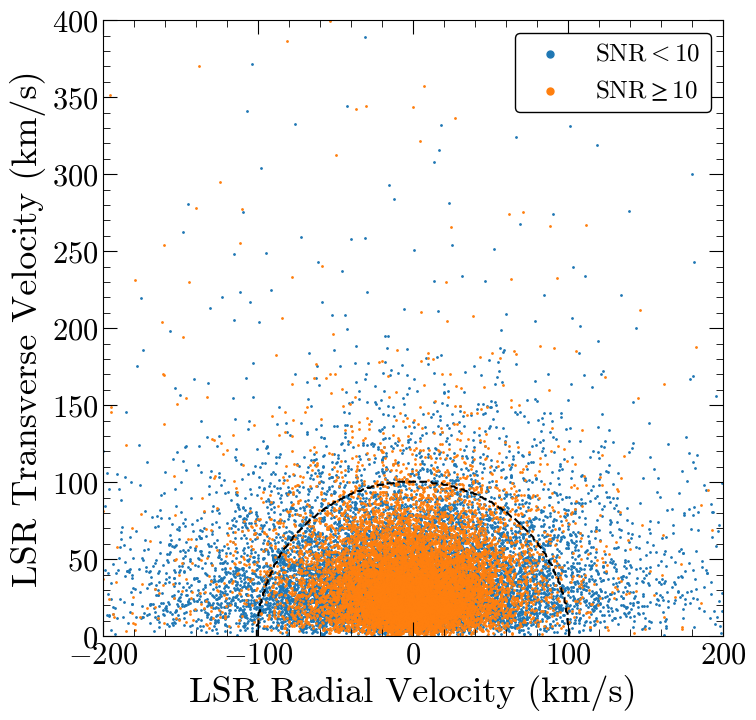

In [22]:
fig, ax=plt.subplots(1,1,figsize=(8,8))

#plot data
ax.scatter(thin_disk_unique.query('snr_coadd<10')['true_rv'],thin_disk_unique.query('snr_coadd<10')['vtransverse'],s=1,label='SNR$\mathrm{<}$10')
ax.scatter(thin_disk_unique.query('snr_coadd>=10')['true_rv'],thin_disk_unique.query('snr_coadd>=10')['vtransverse'],s=1,label='SNR$\geq$10')

#plot contour
x = np.linspace(-200, 200, 400)
y = np.linspace(0, 400, 400)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
# Define the radius 
Z = 100
mask = R < Z
ax.contour(X, Y, mask, levels=[0, 1], colors='black',linestyles='dashed')

ax.set_xlim(-200,200)
ax.set_ylim(0,400)
ax.legend(markerscale=5)
ax.set_xlabel('LSR Radial Velocity (km/s)')
ax.set_ylabel('LSR Transverse Velocity (km/s)')

In [23]:
thin_disk_unique['speed_lsr']=np.sqrt(thin_disk_unique['true_rv']**2+thin_disk_unique['vtransverse']**2)

thin_disk_unique['thin_disk_flag']=thin_disk_unique['speed_lsr'] < 100

In [24]:
thin_disk_merge=thin_disk_unique[['gaia_dr3_source_id','speed_lsr','thin_disk_flag']]

In [25]:
thin_disk_unique.query('thin_disk_flag==True')

,gaia_dr3_source_id,snr_coadd,ra,dec,r_med_geo,pmra,pmdec,rv_corv_coadd,rv_corv_lsr,radius_phot,teff_phot,pmra_lsr,pmdec_lsr,vtransverse,vg_rad_theory,true_rv,speed_lsr,thin_disk_flag
0,74698071455360,17.888636,44.726467,0.511271,67.303879,-77.832683,15.265021,73.537029,61.330641,0.008811,6216.240027,-112.865641,37.792950,37.971414,64.868633,-3.537991,38.135884,True
1,152935195517952,21.944845,45.925846,0.886115,224.510941,-31.145043,-27.364172,-1.900241,-14.290588,0.014460,14397.339856,-41.403603,-20.532501,49.181346,23.398371,-37.688960,61.961782,True
2,288175125714560,71.806174,44.287430,0.774349,153.012146,-18.373571,-18.706614,30.287071,18.199814,0.013135,12415.216971,-33.912326,-8.721925,25.396295,28.323198,-10.123384,27.339617,True
4,294840915182080,15.336507,44.417908,0.850883,606.620605,12.692574,2.134741,72.938501,60.835296,0.012567,20349.164362,8.782784,4.658994,28.587066,32.690913,28.144383,40.116413,True
7,212638161469919360,9.643525,81.128426,48.425362,281.882019,-3.817262,1.667460,72.293501,66.633498,0.010629,11669.350618,-5.100501,14.425077,20.442995,45.638223,20.995275,29.303884,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25400,6913313534421369344,21.068730,311.498523,-6.411461,371.764040,6.530882,-13.048575,61.029381,72.015347,0.013679,13429.441119,-0.063314,-8.306334,14.637528,26.030977,45.984370,48.257844,True
25403,6913442658317973120,8.279637,311.523134,-5.498122,497.886780,11.369381,-11.994522,-66.213542,-55.100723,0.012899,10253.541469,6.443445,-8.528415,25.225545,29.162139,-84.262863,87.957706,True
25411,6917429010739700224,5.289943,315.231526,-0.759035,210.176670,-13.901988,-58.779363,10.318023,21.292028,0.009857,9317.329594,-26.315555,-51.528413,57.641490,52.686288,-31.394260,65.636430,True
25412,6917466527278161152,3.912636,314.635762,-0.679329,329.665280,-25.981793,3.429230,62.410569,73.522607,0.016468,8102.770357,-33.821936,8.043239,54.324521,16.939237,56.583370,78.439986,True


In [26]:
#add the new columns
SDSSV_tab=pd.merge(left=SDSSV_tab,right=thin_disk_merge,on='gaia_dr3_source_id',how="left")

eSDSS_tab=pd.merge(left=eSDSS_tab,right=thin_disk_merge,on='gaia_dr3_source_id',how="left")

# Create tables for temperature-dependence paper measurements
- We use only coadded parameters so drop all gaia_dr3_source_id duplicates and information about individual spectra

In [30]:
#keep only the relevant columns
SDSSV_tab_tempdep=SDSSV_tab[['gaia_dr3_source_id','ra', 'dec','l','b','r_med_geo','phot_g_mean_mag','pmra','pmdec',
                             'rv_corv_coadd','e_rv_corv_coadd_full','snr_coadd','nspec_coadd','teff_prf_coadd',
                             'e_teff_prf_coadd_full','logg_prf_coadd','e_logg_prf_coadd_full','phot_used','phot_err_sdss',
                             'phot_err_gaia','radius_phot','e_radius_phot_full','teff_phot','e_teff_phot_full',
                             'mass_rad_logg','e_mass_rad_logg','mass_logg_theory','e_mass_logg_theory',
                             'mass_rad_theory','e_mass_rad_theory','rv_corv_lsr']].drop_duplicates(subset='gaia_dr3_source_id')
#reset the indices
indices=np.arange(0,len(SDSSV_tab_tempdep))
SDSSV_tab_tempdep.set_index(indices,inplace=True)

eSDSS_tab_tempdep=eSDSS_tab[['gaia_dr3_source_id','ra', 'dec','l','b','r_med_geo','phot_g_mean_mag','pmra','pmdec',
                             'rv_corv_coadd','e_rv_corv_coadd_full','snr_coadd','nspec_coadd','teff_prf_coadd',
                             'e_teff_prf_coadd_full','logg_prf_coadd','e_logg_prf_coadd_full','phot_used','phot_err_sdss',
                             'phot_err_gaia','radius_phot','e_radius_phot_full','teff_phot','e_teff_phot_full',
                             'mass_rad_logg','e_mass_rad_logg','mass_logg_theory','e_mass_logg_theory',
                             'mass_rad_theory','e_mass_rad_theory','rv_corv_lsr']].drop_duplicates(subset='gaia_dr3_source_id')
#reset the indices
indices=np.arange(0,len(eSDSS_tab_tempdep))
eSDSS_tab_tempdep.set_index(indices,inplace=True)
    

# Perform quality cuts

We only want objects with good spectra and photometry.

- SDSS coadd spectra SNR>10
    - For some of these objects, there may not be a corresponding weighted mean RV if no individual spectrum has a snr>10. This is why we prefer to use the coadded spectrum parameters
- Tremblay models are used to fit RVs and to fit phot teff/radius but these models only cover 1500<Teff<130,000K so remove any objects on the edge of the grid
    - Also restrict spectroscopic loggs/teffs to this range. The PRF routine can return measurements outside of this range but there is very very sparse training data in those regimes so those measurements should be considered unreliable and be excluded from this analysis
    - Take 1600<teff_phot<129,000 K and 1600<teff_prf_coadd<129,000 K
    - Take 7<logg_prf_coadd<9 dex
- Bailer-Jones distance r_med_geo<500 pc
    - Need objects within 500 pc in order for the WDs to be locally comoving (see below) and to have more reliable distance measurements
- e_rv_corv_coadd_full<50 km/s, make sure RV fit is decent
- Restrict the full error on the measured radius and logg to be <3 times the bin width
    - E_Radius_Phot_full<$0.002*3$ Rsun, make sure radius fit is decent
    - E_Logg_prf_coadd_full<$0.1*3$ dex, make sure logg fit is decent

### Show quality cuts

In [31]:
def data_cut(table,binmult,figtitle):
    #plot the data quality cuts
    fig, ((ax1,ax2),(ax3,ax4),(ax5,ax6),(ax7,ax8)) =plt.subplots(4,2,figsize=(12,25))
    
    ax1.hist(table['snr_coadd'],histtype='step')
    ax1.axvline(x = 10, color = 'r')
    ax1.set_xlabel(r'SDSS Coadd Spectrum SNR')
    ax1.set_ylabel(r'Counts')

    ax2.hist(table['logg_prf_coadd'],histtype='step')
    ax2.axvline(x = 7, color = 'r')
    ax2.axvline(x = 9, color = 'r')
    ax2.set_xlabel(r'Spectroscopic Logg (dex)')
    
    ax3.hist(table['teff_phot'],histtype='step')
    ax3.axvline(x = 1600, color = 'r')
    ax3.axvline(x = 129000, color = 'r')
    ax3.set_xlabel(r'Photometric Teff (K)')
    ax3.set_ylabel(r'Counts')
    
    ax4.hist(table['teff_prf_coadd'],histtype='step')
    ax4.axvline(x = 1600, color = 'r')
    ax4.axvline(x = 129000, color = 'r')
    ax4.set_xlabel(r'Spectroscopic Teff (K)')
    
    ax5.hist(table['r_med_geo'],histtype='step')
    ax5.axvline(x = 500, color = 'r')
    ax5.set_xlabel(r'Bailer-Jones Distance (pc)')
    ax5.set_ylabel(r'Counts')
    ax5.set_xlim(0,2000)
    
    ax6.hist(table['e_rv_corv_coadd_full'],histtype='step')
    ax6.axvline(x = 50, color = 'r')
    ax6.set_xlabel(r'Full corv RV Error (km/s)')
    ax6.set_xlim(0,200)
    
    """
    ax7.hist(table['e_radius_phot_full'],histtype='step')
    ax7.axvline(x = 0.002*binmult, color = 'r')
    ax7.set_xlabel(r'Full Radius Error (Rsun)')
    ax7.set_ylabel(r'Counts')
    ax7.set_xlim(0,0.02)
    """
    
    ax8.hist(table['e_logg_prf_coadd_full'],histtype='step')
    ax8.axvline(x = 0.1*binmult, color = 'r')
    ax8.set_xlabel(r'Full Logg Error (dex)')
    #ax8.set_xlim(0,1)
    
    fig.suptitle(figtitle,y=0.9)
    

### Do quality cuts
- The most stringent cut is the SNR cut

In [32]:
print('total number independent objects=',len(SDSSV_tab_tempdep))
print('')

binmult=3
print('binmult=3')

#show effect of snr cut
SDSSV_tab_tempdep=SDSSV_tab_tempdep.query('snr_coadd>10')
print('cut on snr_coadd')
print('number independent objects=',len(SDSSV_tab_tempdep))

SDSSV_tab_tempdep=SDSSV_tab_tempdep.query('7<logg_prf_coadd<9 and 1600<teff_phot<129000 and 1600<teff_prf_coadd<129000 and r_med_geo<500 and e_rv_corv_coadd_full<50 and e_radius_phot_full<0.002*@binmult and e_logg_prf_coadd_full<0.1*@binmult')
print('cut on logg, teff, distance, RV error, radius error, and logg error')
print('number independent objects=',len(SDSSV_tab_tempdep))



total number independent objects= 8545

binmult=3
cut on snr_coadd
number independent objects= 3772
cut on logg, teff, distance, RV error, radius error, and logg error
number independent objects= 2934


In [33]:
print('total number independent objects=',len(eSDSS_tab_tempdep))
print('')

binmult=3
print('binmult=3')

#show effect of snr cut
eSDSS_tab_tempdep=eSDSS_tab_tempdep.query('snr_coadd>10')
print('cut on snr_coadd')
print('number independent objects=',len(eSDSS_tab_tempdep))

eSDSS_tab_tempdep=eSDSS_tab_tempdep.query('7<logg_prf_coadd<9 and 1600<teff_phot<129000 and 1600<teff_prf_coadd<129000 and r_med_geo<500 and e_rv_corv_coadd_full<50 and e_radius_phot_full<0.002*@binmult and e_logg_prf_coadd_full<0.1*@binmult')
print('cut on logg, teff, distance, RV error, radius error, and logg error')
print('number independent objects=',len(eSDSS_tab_tempdep))


total number independent objects= 19257

binmult=3
cut on snr_coadd
number independent objects= 9677
cut on logg, teff, distance, RV error, radius error, and logg error
number independent objects= 7331


# Remove Halo WDs
- Most of the stars near the sun belong to the disk, so the mean speed of the LSR is dominated by disk stars
- Halo stars have high speeds relative to LSR
    - Thin disk stars don’t typically deviate by more than 80 -120 km/s from LSR (Ninkovic 2012)
    - Halo stars often identified by speed >220 km/s relative to LSR cut (Du 2018)
    - Within 80 km/s of LSR ≤ 5% of stars are Halo stars, within 120 km/s ≤ 10%, among high-velocity stars (over 100km/s) halo stars are almost as common as disk stars (Ninkovic 2012)
- Local density of halo WDs is 10^-5 - 10^-4 per pc^3 (Isern 1998)
    - 0.24 to 0.46 white dwarfs in a sphere of 10 pc of radius around the Sun
    - ~5000-50,000 within 500 pc radius around Sun (lots!)

Cut
- Calculate mean LSR-corrected RV of entire sample, this is total mean gravitational redshift
- Subtract the total mean gravitational redshift to get ~just the RV for each object in sample (otherwise distribution is skewed)
- Test cuts of |corv_RV_LSR-mean grav redshift|< 120 or 220 km/s to remove halo WDs
- We choose to go with the more conservative 120 km/s cut. The 220 km/s cut only removes <~5 objects from each table


In [34]:
def halo_cut(table,threshold,plot=False):
    #calculate mean grav redshift for whole sample
    mean_vg=np.mean(table['rv_corv_lsr'])
    print('mean grav redshift=',mean_vg)
    #subtract this mean grav redshift
    table['rv_corv_lsr_vg']=table['rv_corv_lsr']-mean_vg
    
    if plot==True:
        #show cut
        fig, (ax1) =plt.subplots(1,1,figsize=(6,6))
        ax1.hist(table['rv_corv_lsr_vg'],histtype='step')
        ax1.axvspan(-120,120, color = 'g',alpha=0.5,label='Within 120 km/s')
        ax1.axvspan(-220,220, color = 'y',alpha=0.3,label='Within 220 km/s')
        ax1.set_xlabel(r'LSR RV-Mean $v_g$')
        ax1.set_ylabel(r'Counts')
        ax1.set_xlim(-300,300)
        
    #cut out halo WDs
    if plot==True:
        print('threshold='+str(threshold)+' km/s')
        print('number independent objects=',len(table))
        print('')
    table=table.query('-@threshold<rv_corv_lsr_vg<@threshold')
    #reset the indices
    indices=np.arange(0,len(table))
    table.set_index(indices,inplace=True)
    #drop the RV_corv_LSR_vg column which will not be used again
    table=table.drop(columns='rv_corv_lsr_vg')
    if plot==True:
        print('number independent objects=',len(table))
        print('')
    
    return(table)

mean grav redshift= 26.972653217630587
threshold=120 km/s
number independent objects= 7331

number independent objects= 7242

mean grav redshift= 26.972653217630587
threshold=220 km/s
number independent objects= 7331

number independent objects= 7319



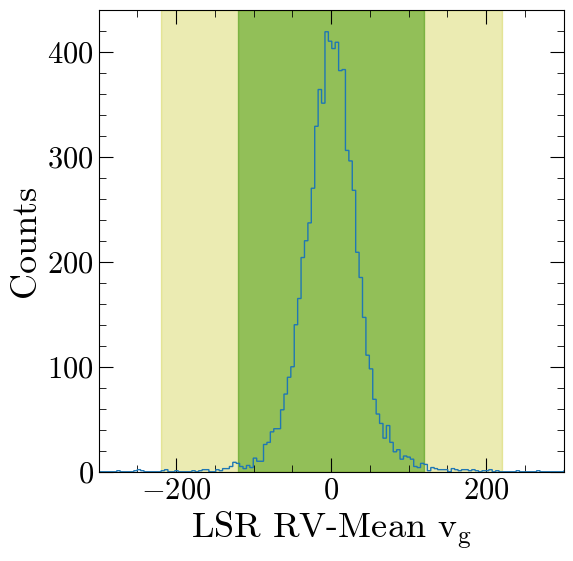

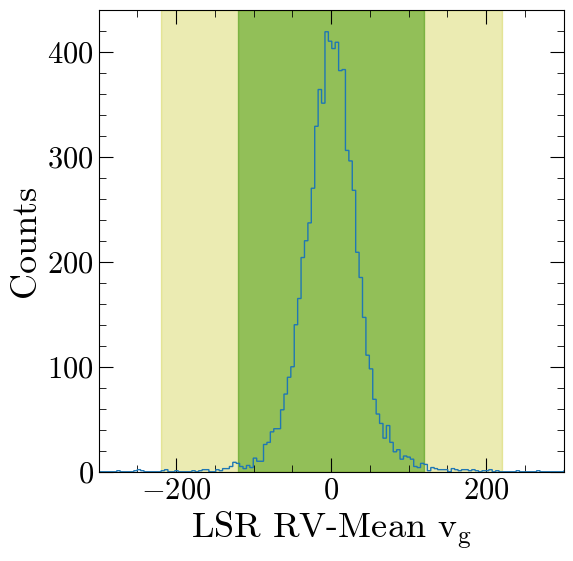

In [35]:
out=halo_cut(eSDSS_tab_tempdep,120,plot=True)
out=halo_cut(eSDSS_tab_tempdep,220,plot=True)

### Implement a quality cut of -120<rv_corv_lsr_vg<120 to remove halo WDs

In [36]:
print(len(SDSSV_tab_tempdep),len(eSDSS_tab_tempdep))
print('')

print('SDSSV')
SDSSV_tab_tempdep=halo_cut(SDSSV_tab_tempdep,120)
print('eSDSS')
eSDSS_tab_tempdep=halo_cut(eSDSS_tab_tempdep,120)

print('')
print(len(SDSSV_tab_tempdep),len(eSDSS_tab_tempdep))

2934 7331

SDSSV
mean grav redshift= 31.947326231262753
eSDSS
mean grav redshift= 26.972653217630587

2887 7242


# FINAL SAMPLE SIZE:
### SDSSV=2887 individual WDs
### eSDSS=7242 individual WDs


# Asymmetric Drift Correction

### It is important that this correction represent the asymmetric drift of the population used  to characterize the temperature dependence of WD structure. For other subsets of this catalog used for different purposes, this correction should be re-calculated.

https://www.aanda.org/articles/aa/full_html/2013/09/aa21559-13/aa21559-13.html
- The asymmetric drift of a stellar population is defined as the difference between the velocity of a hypothetical set of stars possessing perfectly circular orbits and the mean rotation velocity of the population under consideration. The velocity of the former is called the standard of rest.
- If the measurements are made at the solar Galactocentric radius, it is the local standard of rest (LSR). The determination of the LSR corresponds to measuring the peculiar motion (U⊙,V⊙,W⊙) of the Sun, where U⊙ is the velocity of the Sun in the direction of the Galactic centre, V⊙ in the direction of the Galactic rotation, and W⊙ in the vertical direction.
- While measuring U⊙ and W⊙ is relatively straightforward, V⊙ requires a sophisticated asymmetric drift correction for its measurement. The asymmetric drift is the difference of the local circular speed $v_c$ and the mean rotational speed of the stellar population. The asymmetric drift corresponds (traditionally with a minus sign to yield positive values for $V_a$) to the measured mean rotational velocity of the stellar sample corrected by the reflex motion of the Sun.
- The sun is moving in the l=90 direction and that is the direction where the asymmetric drift correction needs to be ADDED, because the starts in this direction are rotating a little too slowly due to the asymmetric drift.
- So, we expect the RVs of stars in the l=90 direction to be less than those in the l=270 direction. This is what we find below.

### Show presence of asymmetric drift

In [27]:
SDSSV_tab_unique=SDSSV_tab.drop_duplicates(subset='gaia_dr3_source_id')
eSDSS_tab_unique=eSDSS_tab.drop_duplicates(subset='gaia_dr3_source_id')

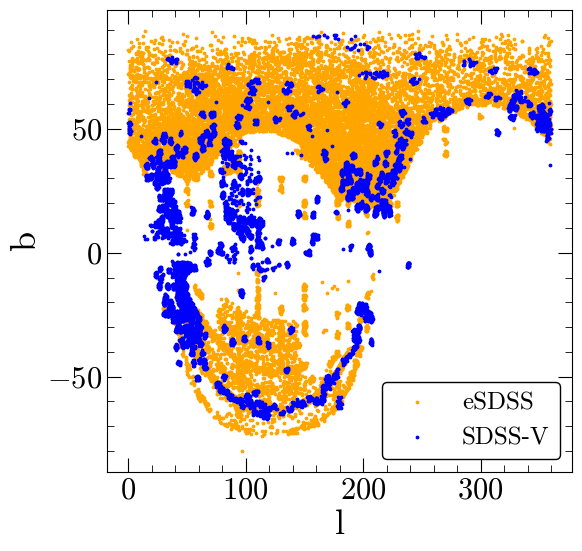

In [28]:
#look at the sky coverage
fig, ax1 =plt.subplots(1,1,figsize=(6,6))
plt.style.use('stefan.mplstyle')
ax1.scatter(eSDSS_tab_unique['l'],eSDSS_tab_unique['b'],s=3,color='orange',label='eSDSS')
ax1.scatter(SDSSV_tab_unique['l'],SDSSV_tab_unique['b'],s=3,color='blue',label='SDSS-V')
ax1.set_xlabel('l')
ax1.set_ylabel('b')
ax1.legend()

Full Sample
345
32
-24.665364112854903

772
174
-10.877048644160377


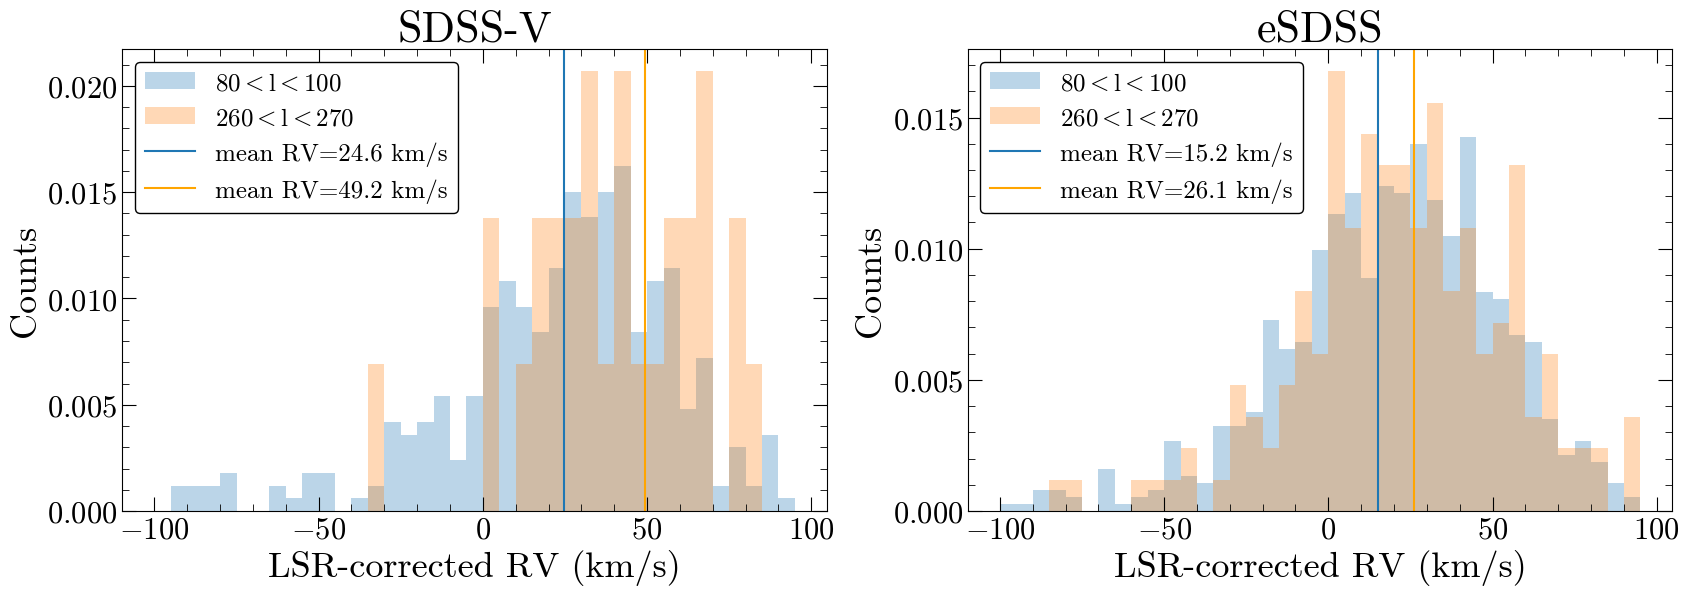

Temperature Dependence Sample
285
24
-14.439626099084649

575
123
-1.3792239741935468


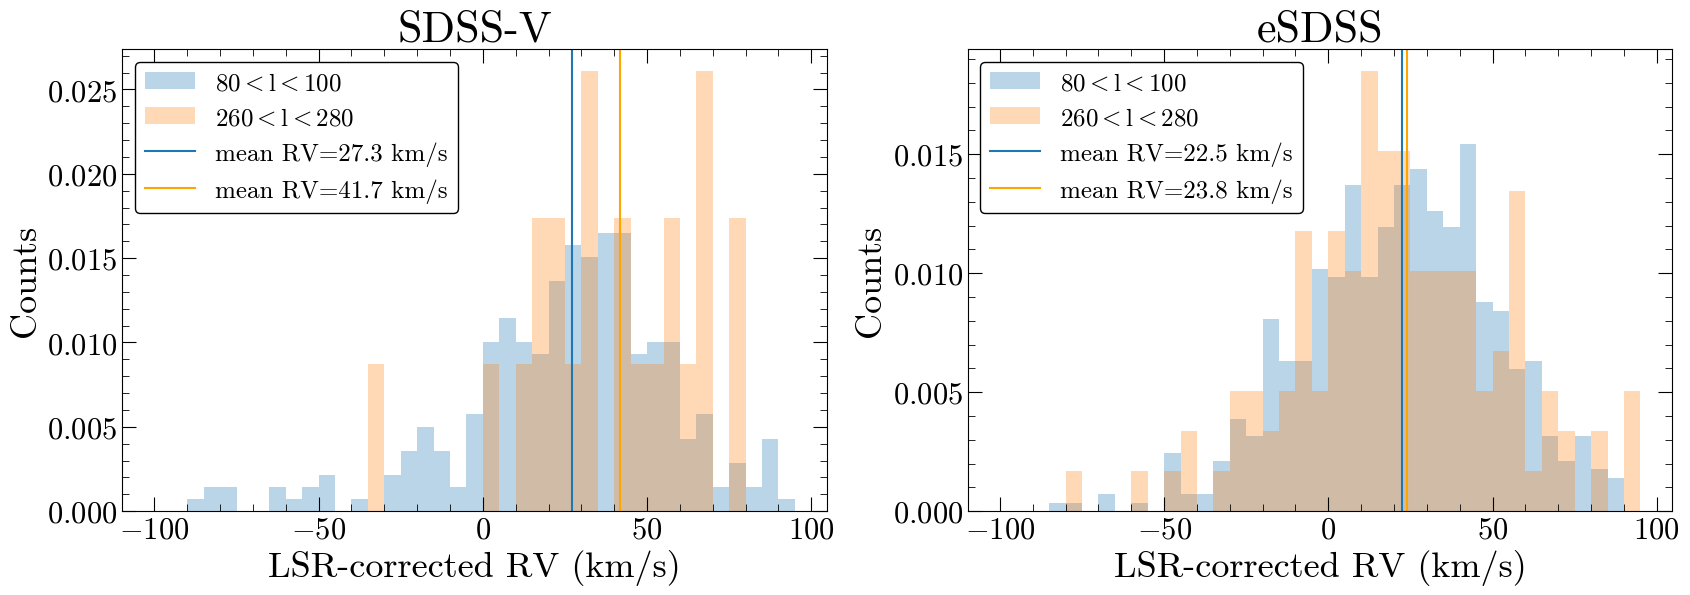

In [38]:
#look at asymmetric drift by plotting LSR-corrected RV distributions
bins=np.arange(-100,100,5)

print('Full Sample')

#make quality cut of snr=10 to get relliable RVs
snr_cut=10
SDSSV_tab_cut=SDSSV_tab_unique.query('snr_coadd>@snr_cut')
eSDSS_tab_cut=eSDSS_tab_unique.query('snr_coadd>@snr_cut')

fig, (ax1,ax2) =plt.subplots(1,2,figsize=(20,6))
l90=SDSSV_tab_cut.query('80<l<100')
l270=SDSSV_tab_cut.query('260<l<280')
print(len(l90))
print(len(l270))
ax1.hist(l90['rv_corv_lsr'],bins=bins,density=True,alpha=0.3,label='$\mathrm{80<l<100}$')
ax1.hist(l270['rv_corv_lsr'],bins=bins,density=True,alpha=0.3,label='$\mathrm{260<l<270}$')
ax1.axvline(x = np.mean(l90['rv_corv_lsr']),label='mean RV='+str(np.round(np.mean(l90['rv_corv_lsr']),1))+' km/s')
ax1.axvline(x = np.mean(l270['rv_corv_lsr']),color='orange',label='mean RV='+str(np.round(np.mean(l270['rv_corv_lsr']),1))+' km/s')
ax1.set_xlabel(r'LSR-corrected RV (km/s)')
ax1.set_ylabel(r'Counts')
ax1.legend()
ax1.set_title('SDSS-V')
print(np.mean(l90['rv_corv_lsr'])-np.mean(l270['rv_corv_lsr']))

print('')

l90=eSDSS_tab_cut.query('80<l<100')
l270=eSDSS_tab_cut.query('260<l<280')
print(len(l90))
print(len(l270))
ax2.hist(l90['rv_corv_lsr'],bins=bins,density=True,alpha=0.3,label='$\mathrm{80<l<100}$')
ax2.hist(l270['rv_corv_lsr'],bins=bins,density=True,alpha=0.3,label='$\mathrm{260<l<270}$')
ax2.axvline(x = np.mean(l90['rv_corv_lsr']),label='mean RV='+str(np.round(np.mean(l90['rv_corv_lsr']),1))+' km/s')
ax2.axvline(x = np.mean(l270['rv_corv_lsr']),color='orange',label='mean RV='+str(np.round(np.mean(l270['rv_corv_lsr']),1))+' km/s')
ax2.set_xlabel(r'LSR-corrected RV (km/s)')
ax2.set_ylabel(r'Counts')
ax2.legend()
ax2.set_title('eSDSS')
print(np.mean(l90['rv_corv_lsr'])-np.mean(l270['rv_corv_lsr']))
plt.show()

print('Temperature Dependence Sample')

#make quality cut of snr=10 to get relliable RVs
snr_cut=10
SDSSV_tab_cut=SDSSV_tab_tempdep.query('snr_coadd>@snr_cut')
eSDSS_tab_cut=eSDSS_tab_tempdep.query('snr_coadd>@snr_cut')

fig, (ax1,ax2) =plt.subplots(1,2,figsize=(20,6))
l90=SDSSV_tab_cut.query('80<l<100')
l270=SDSSV_tab_cut.query('260<l<280')
print(len(l90))
print(len(l270))
ax1.hist(l90['rv_corv_lsr'],bins=bins,density=True,alpha=0.3,label='$\mathrm{80<l<100}$')
ax1.hist(l270['rv_corv_lsr'],bins=bins,density=True,alpha=0.3,label='$\mathrm{260<l<280}$')
ax1.axvline(x = np.mean(l90['rv_corv_lsr']),label='mean RV='+str(np.round(np.mean(l90['rv_corv_lsr']),1))+' km/s')
ax1.axvline(x = np.mean(l270['rv_corv_lsr']),color='orange',label='mean RV='+str(np.round(np.mean(l270['rv_corv_lsr']),1))+' km/s')
ax1.set_xlabel(r'LSR-corrected RV (km/s)')
ax1.set_ylabel(r'Counts')
ax1.legend()
ax1.set_title('SDSS-V')
print(np.mean(l90['rv_corv_lsr'])-np.mean(l270['rv_corv_lsr']))

print('')

l90=eSDSS_tab_cut.query('80<l<100')
l270=eSDSS_tab_cut.query('260<l<280')
print(len(l90))
print(len(l270))
ax2.hist(l90['rv_corv_lsr'],bins=bins,density=True,alpha=0.3,label='$\mathrm{80<l<100}$')
ax2.hist(l270['rv_corv_lsr'],bins=bins,density=True,alpha=0.3,label='$\mathrm{260<l<280}$')
ax2.axvline(x = np.mean(l90['rv_corv_lsr']),label='mean RV='+str(np.round(np.mean(l90['rv_corv_lsr']),1))+' km/s')
ax2.axvline(x = np.mean(l270['rv_corv_lsr']),color='orange',label='mean RV='+str(np.round(np.mean(l270['rv_corv_lsr']),1))+' km/s')
ax2.set_xlabel(r'LSR-corrected RV (km/s)')
ax2.set_ylabel(r'Counts')
ax2.legend()
ax2.set_title('eSDSS')
print(np.mean(l90['rv_corv_lsr'])-np.mean(l270['rv_corv_lsr']))

### Calculate velocity dispersion
Also check that the velocity dispersion as a function of temperature (aka color) and logg/radius (aka mass) is consistent

In [39]:
def dispersion_plot(table,bin_nums,bin_ranges,bin_centers,bin_id_key,RV_key):
    #calculate the mean and std of the RVs for each bin
    mean_RVs=[]
    dispersions=[]
    num_obs_per_bin=[]
    for i in range(len(bin_nums)):
        tmp=table.query(bin_id_key+'=='+str(bin_nums[i]))
        rv=np.array(tmp[RV_key].to_list())
        if len(rv)>0:
            #calculate mean and std of RVs
            mean_RV=np.average(rv)
            std_RV=np.std(rv)
        else: #if bin is empty fill with nan values
            mean_RV=np.nan
            std_RV=np.nan
        #record results
        mean_RVs.append(mean_RV)
        dispersions.append(std_RV)
        #record how many observations used in averaging
        num_obs=len(tmp)
        num_obs_per_bin.append(num_obs)
        
    table=pd.DataFrame()
    table[bin_id_key]=bin_nums
    table['bin_range']=bin_ranges
    table['bin_center']=bin_centers
    table['mean_rvs']=mean_RVs
    table['v_dispersion']=dispersions
    table['num_obs_per_bin']=num_obs_per_bin
    
    #re-order by bin_id
    table=table.sort_values(by=[bin_id_key])
    
    return(table)

In [40]:
def velocity_dispersion(table,verbose=False,plot=False):
    
    #calculate the velocity dispersion of the lsr corrected rvs
    avg_v=np.mean(table['rv_corv_lsr'])
    sigma_v=np.std(table['rv_corv_lsr'])
    if verbose:
        print("mean velocity=",avg_v," km/s")
        print("velocity dispersion=",sigma_v," km/s")
        print('sigma^2=',sigma_v**2)
        
    #drop any nans
    table=table.dropna(subset=['teff_phot','radius_phot','logg_prf_coadd'])
    #reset the indices
    indices=np.arange(0,len(table))
    table.set_index(indices,inplace=True)
        
    if plot==True:
        #check that the velocity dispersion as a function of temperature (aka color) and logg/radius (aka mass)
        #is consistent
        
        #bin by photometric teff
        t_bins=np.round(np.arange(1000,134000,4000),1)
        t_bin_ranges=[]
        t_bin_half_pts=[]
        for i in range(len(t_bins)-1):
            array=[t_bins[i],t_bins[i+1]]
            half=0.5*(t_bins[i]+t_bins[i+1])
            t_bin_ranges.append(array)
            t_bin_half_pts.append(half)
        t_bin_nums=np.arange(0,len(t_bin_ranges))
        t_bin_ids=[]
        t_bin_id_ranges=[]
        t_bin_id_centers=[]
        for i in range(len(table)):
            teff=table['teff_phot'][i]
            for j in range(len(t_bin_ranges)):
                if t_bin_ranges[j][0]<teff<=t_bin_ranges[j][1]:
                    t_bin_ids.append(j)
                    t_bin_id_ranges.append(t_bin_ranges[j])
                    t_bin_id_centers.append(t_bin_half_pts[j])
        table['teff_bin_id']=t_bin_ids
        table['teff_bin_range']=t_bin_id_ranges
        table['teff_bin_center']=t_bin_id_centers
        
        #bin by surface gravity
        g_bins=np.round(np.arange(5.7,10.1,0.1),1)
        g_bin_ranges=[]
        g_bin_centers=[]
        for i in range(len(g_bins)-1):
            array=[g_bins[i],g_bins[i+1]]
            half=0.5*(g_bins[i]+g_bins[i+1])
            g_bin_ranges.append(array)
            g_bin_centers.append(half)
        g_bin_nums=np.arange(0,len(g_bin_ranges))
        g_bin_ids=[]
        g_bin_id_ranges=[]
        g_bin_id_centers=[]
        for i in range(len(table)):
            logg=table['logg_prf_coadd'][i]
            for j in range(len(g_bin_ranges)):
                if g_bin_ranges[j][0]<logg<=g_bin_ranges[j][1]:
                    g_bin_ids.append(j)
                    g_bin_id_ranges.append(g_bin_ranges[j])
                    g_bin_id_centers.append(g_bin_centers[j])
        table['logg_bin_id']=g_bin_ids
        table['logg_bin_range']=g_bin_id_ranges
        table['logg_bin_center']=g_bin_id_centers
        
        
        #radius bins
        r_bins=np.round(np.arange(0,0.055,0.002),3)
        r_bin_ranges=[]
        r_bin_centers=[]
        for i in range(len(r_bins)-1):
            array=[r_bins[i],r_bins[i+1]]
            half=0.5*(r_bins[i]+r_bins[i+1])
            r_bin_ranges.append(array)
            r_bin_centers.append(half)
        r_bin_nums=np.arange(0,len(r_bin_ranges))
        #bin by radius
        r_bin_ids=[]
        r_bin_id_ranges=[]
        r_bin_id_centers=[]
        for i in range(len(table)):
            radius=table['radius_phot'][i]
            for j in range(len(r_bin_ranges)):
                if r_bin_ranges[j][0]<radius<r_bin_ranges[j][1]:
                    r_bin_ids.append(j)
                    r_bin_id_ranges.append(r_bin_ranges[j])
                    r_bin_id_centers.append(r_bin_centers[j])
        table['radius_bin_id']=r_bin_ids
        table['radius_bin_range']=r_bin_id_ranges
        table['radius_bin_center']=r_bin_id_centers
        
        dispersions_logg=dispersion_plot(table,g_bin_nums,g_bin_ranges,g_bin_centers,'logg_bin_id','rv_corv_lsr')
        dispersions_radius=dispersion_plot(table,r_bin_nums,r_bin_ranges,r_bin_centers,'radius_bin_id','rv_corv_lsr')
        dispersions_teff=dispersion_plot(table,t_bin_nums,t_bin_ranges,t_bin_half_pts,'teff_bin_id','rv_corv_lsr')

        min_num_obs=10
        fig, (ax1,ax2,ax3) =plt.subplots(1,3,figsize=(18,6),sharey=True)
        plt.style.use('stefan.mplstyle')
        
        ax1.scatter(dispersions_logg.query('num_obs_per_bin>@min_num_obs')['bin_center'],dispersions_logg.query('num_obs_per_bin>@min_num_obs')['v_dispersion'])
        ax1.axhline(sigma_v,label="Mean Velocity Dispersion\n="+str(np.round(sigma_v,1))+" km/s")
        ax1.set_xlabel('Logg (dex)')
        ax2.scatter(dispersions_radius.query('num_obs_per_bin>@min_num_obs')['bin_center'],dispersions_radius.query('num_obs_per_bin>@min_num_obs')['v_dispersion'])
        ax2.axhline(sigma_v)
        ax2.set_xlabel('Radius ($R_\odot$)')
        ax3.scatter(dispersions_teff.query('num_obs_per_bin>@min_num_obs')['bin_center'],dispersions_teff.query('num_obs_per_bin>@min_num_obs')['v_dispersion'])
        ax3.axhline(sigma_v)
        ax3.set_xlabel('Photometric Teff (K)')
        
        ax1.set_ylim(0,200)
        ax1.set_ylabel('Velocity Dispersion (km/s)')
        ax1.legend()
        fig.suptitle("Variation in Velocity Dispersion for Bins with $\mathrm{>}$"+str(min_num_obs)+" Observations",fontsize=40)
        
        table=table.drop(columns=['teff_bin_id','teff_bin_range','teff_bin_center'])
    return(sigma_v)


Full Sample
SDSSV
mean velocity= 28.773388197355455  km/s
velocity dispersion= 65.46350131363131  km/s
sigma^2= 4285.470004239808

eSDSS
mean velocity= 23.194811379425683  km/s
velocity dispersion= 124.30546045661289  km/s
sigma^2= 15451.847499330552


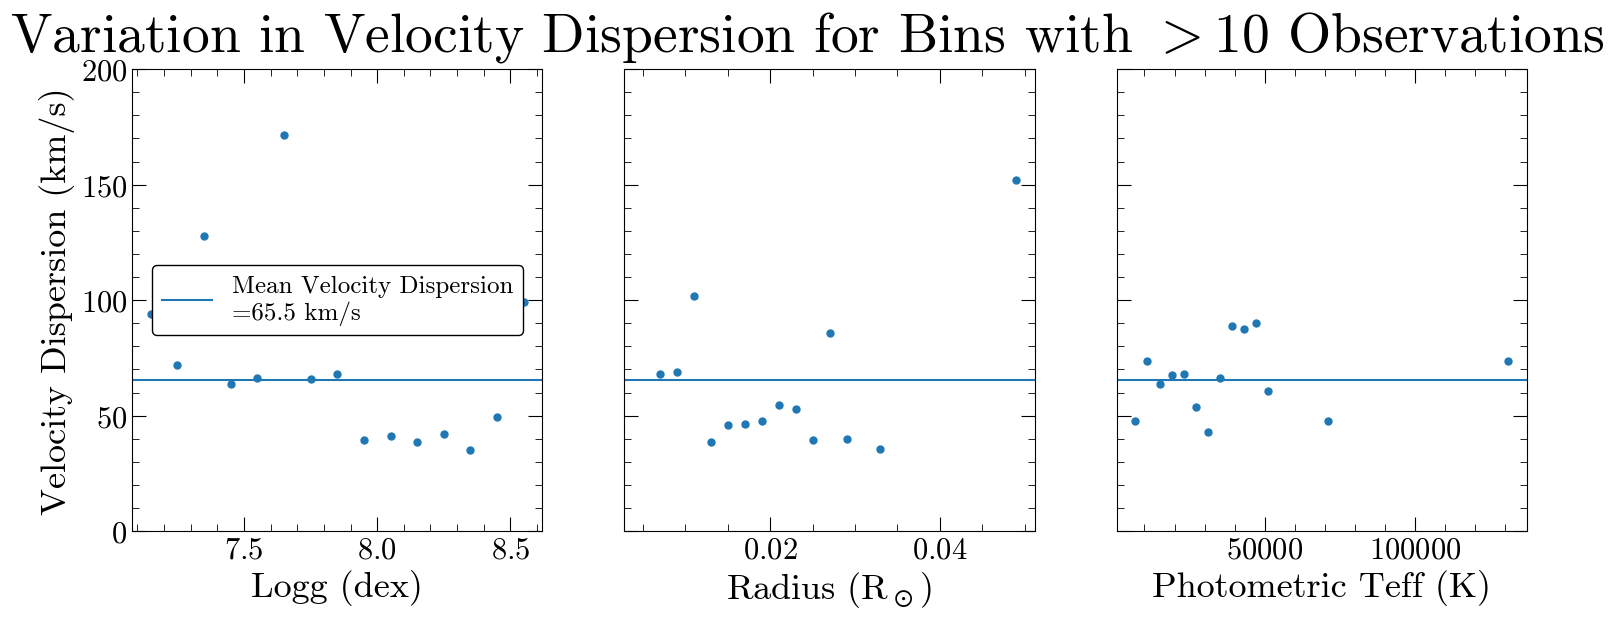

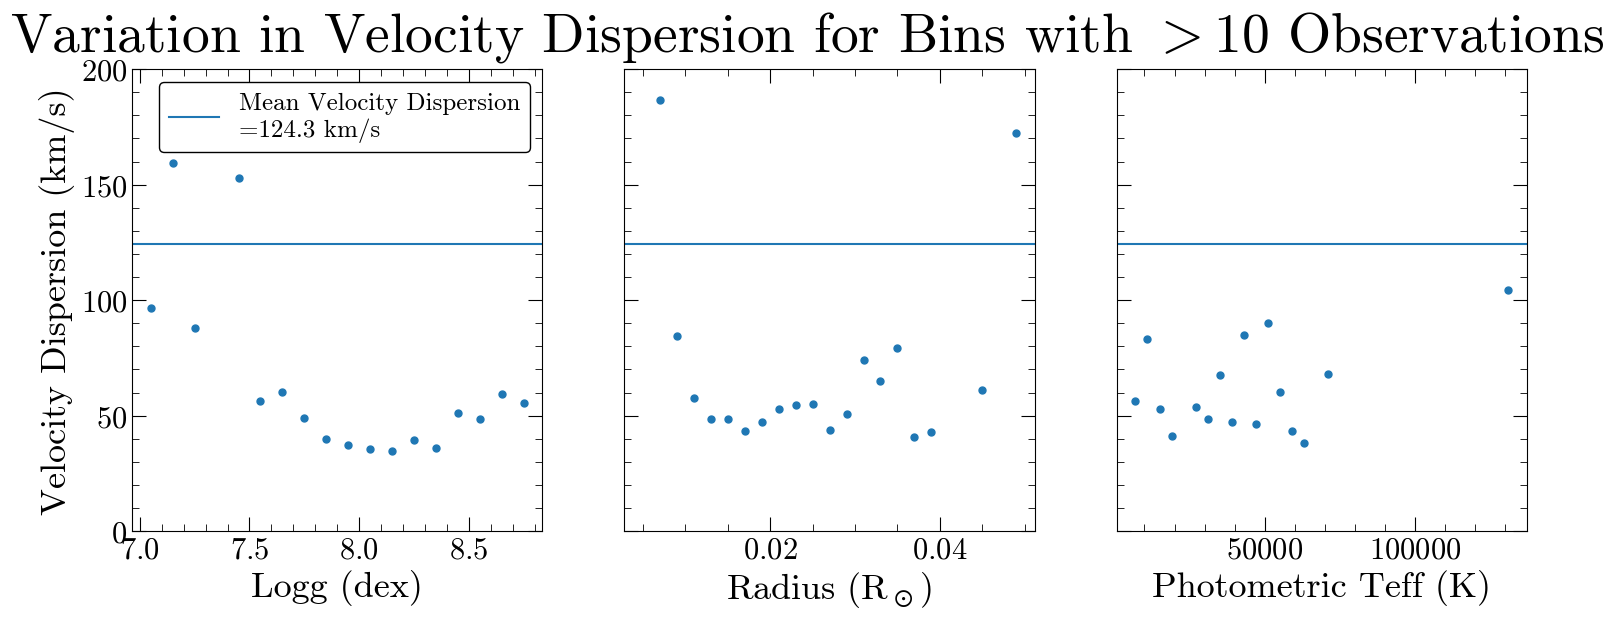

Temperature Dependence Sample
SDSSV
mean velocity= 33.25155245549317  km/s
velocity dispersion= 36.94524545058356  km/s
sigma^2= 1364.9511614038654

eSDSS
mean velocity= 27.043621807217797  km/s
velocity dispersion= 34.03208829761003  km/s
sigma^2= 1158.1830338963257


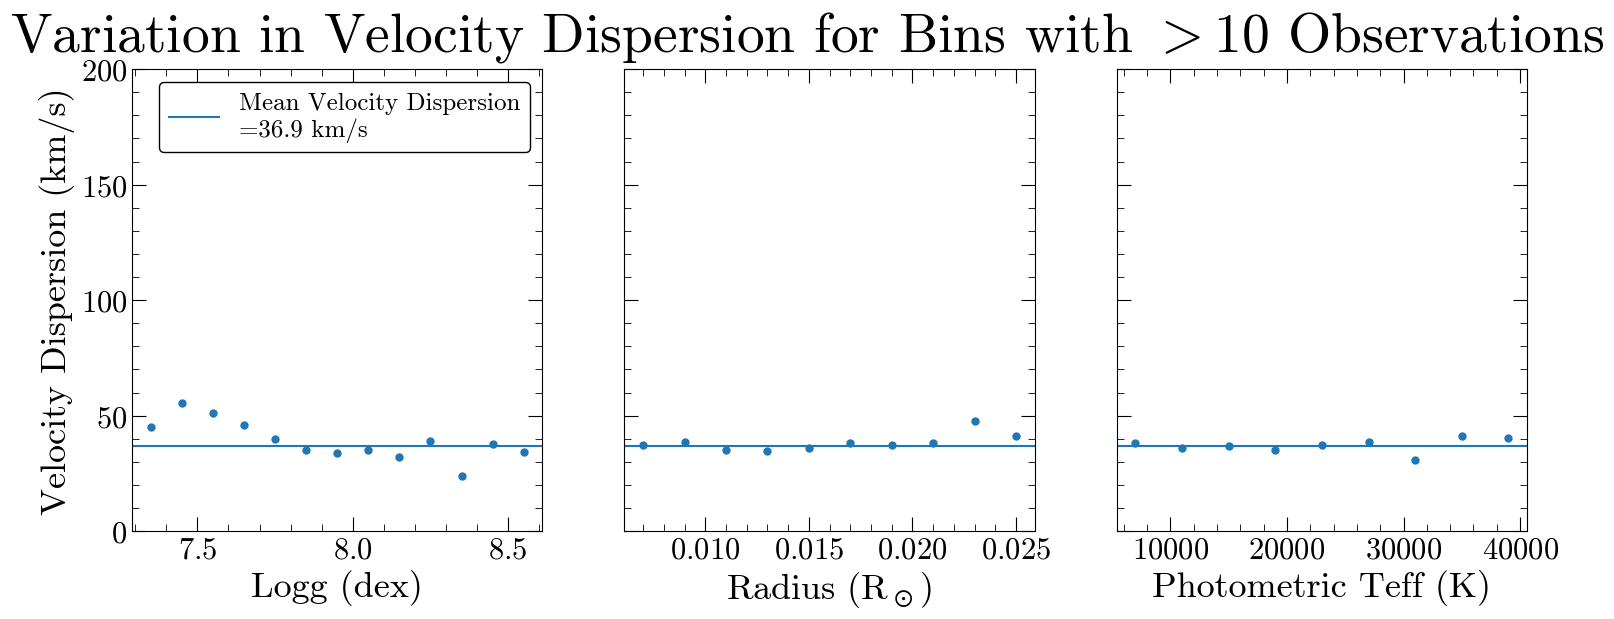

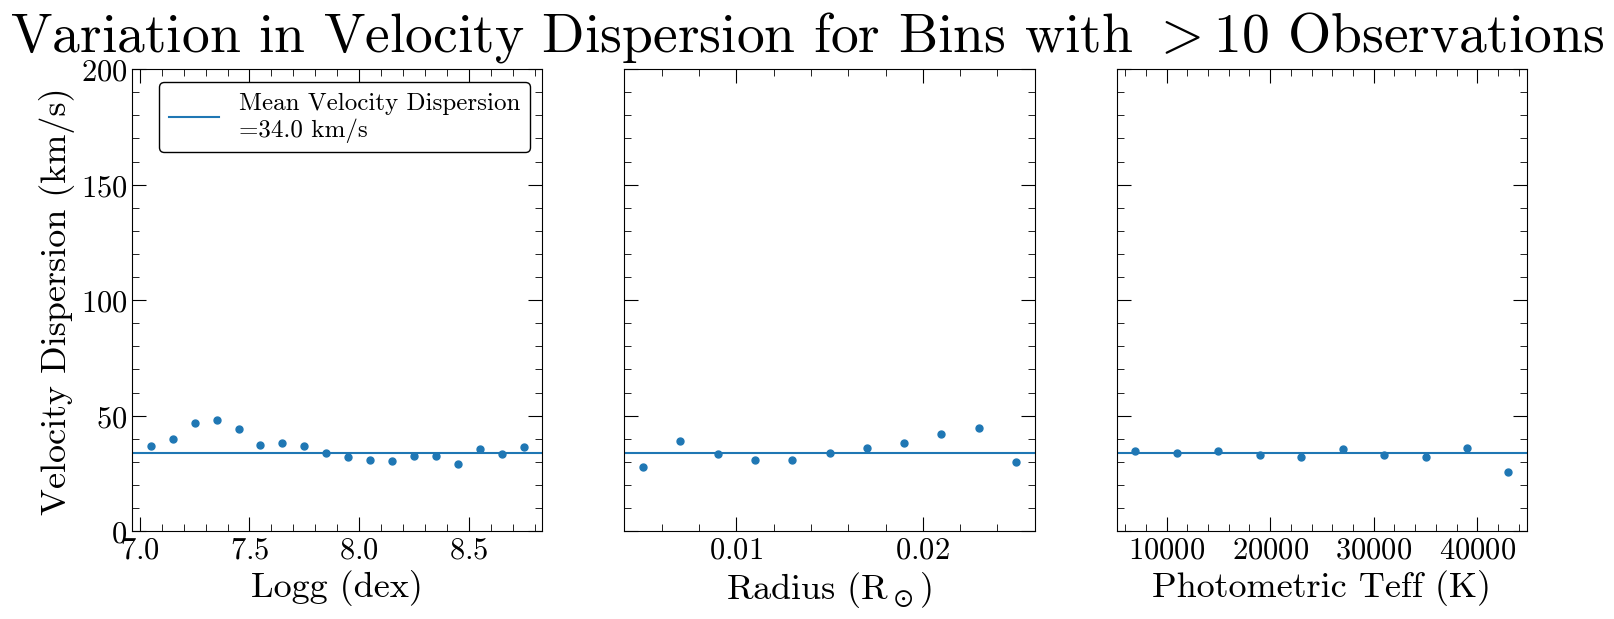

In [41]:
print('Full Sample')
#make quality cut of snr=10 to get relliable RVs
snr_cut=10
SDSSV_tab_cut=SDSSV_tab_unique.query('snr_coadd>@snr_cut')
eSDSS_tab_cut=eSDSS_tab_unique.query('snr_coadd>@snr_cut')
print('SDSSV')
SDSSV_full_sigma_v=velocity_dispersion(SDSSV_tab_cut,verbose=True,plot=True)
print('')
print('eSDSS')
eSDSS_full_sigma_v=velocity_dispersion(eSDSS_tab_cut,verbose=True,plot=True)
plt.show()

print('Temperature Dependence Sample')
SDSSV_tab_cut=SDSSV_tab_tempdep #tempdep samples already have snr>10 cut
eSDSS_tab_cut=eSDSS_tab_tempdep
print('SDSSV')
SDSSV_sigma_v=velocity_dispersion(SDSSV_tab_cut,verbose=True,plot=True)
print('')
print('eSDSS')
eSDSS_sigma_v=velocity_dispersion(eSDSS_tab_cut,verbose=True,plot=True)
plt.show()


### Turning velocity dispersion into asymmetric drift
- For the full sample with snr>10 cut
    - The overall velocity dispersion is ~ 65 km/s for SDSS-V amd ~124 km/s for eSDSS 
        - This is very different from the temperature dependence sample, showing the importance of measuring asymmetric drift for particular science cases with different selection effects picking out different populations of WDs
    - Binning in Logg/Radius/Teff results in dispersions varying between 30-190 km/s for bins with >10 entries.
        - Much higher velocity dispersions at low logg and small/large radii
  
- For the temperature dependence sample
    - The overall velocity dispersion is ~37 km/s for SDSS-V and ~34 km/s for eSDSS. 
        - SDSS-V has more WD observations in the galactic plane than eSDSS and had very different WD targeting strategies, possibily accounting for this offset.
    - Binning in Logg/Radius/Teff results in dispersions varying between 30-60 km/s for bins with >10 entries.
        - Overall, see no trend in velocity dispersion with Teff. See slight trend where lower mass (low logg, high radius) objects have higher asymmetric drift. This is possibly due to binary evolution as lower mass WDs more likely to be in binaries.

Fig. 3 of https://ui.adsabs.harvard.edu/abs/2010MNRAS.403.1829S/abstract plots asymmetric drift as a function of velocity dispersion squared.

### Our sigma_v^2 is ~1400km/s for SDSS-V and ~1200 km/s for eSDSS which correspond to an asymmetric drift of 10 and 8 km/s respectively.

### Apply the asymmetric drift correction

In [42]:
def asym_corr(table,asym_drift):
    #asym_drift=asymmetric drift in km/s
    
    #convert l, b, and distance (which are in galactic coordinates) to a cartesian representation
    coords_cartesian=SkyCoord(l=table['l'].to_list()*u.deg, 
                       b=table['b'].to_list()*u.deg, 
                       distance=table['r_med_geo'].to_list()*u.pc,frame='galactic')
    coords_cartesian.representation_type = 'cartesian'
    
    
    #make a sky coord object with the WD spatial coordinates and the asymmetric drift
    sc_asym = SkyCoord(u=coords_cartesian.u.value*u.pc, 
                       v=coords_cartesian.v.value*u.pc, 
                       w=coords_cartesian.w.value*u.pc,
                       U=np.full(len(coords_cartesian),0)*u.km/u.s,
                       V=np.full(len(coords_cartesian),-asym_drift)*u.km/u.s,
                       W=np.full(len(coords_cartesian),0)*u.km/u.s,
                       representation_type=CartesianRepresentation,differential_type=CartesianDifferential,frame='galactic')
    #convert to LSR
    sc_asym_lsr=sc_asym.lsr
    
    #add the radial velocity correction due to asym drift to the RV_corv_LSR
    table['rv_corv_asym_corr']=table['rv_corv_lsr']+sc_asym_lsr.radial_velocity.value
    table['asym_corr']=sc_asym_lsr.radial_velocity.value
    
    return(table)

In [43]:
SDSSV_tab_tempdep=asym_corr(SDSSV_tab_tempdep,10)
eSDSS_tab_tempdep=asym_corr(eSDSS_tab_tempdep,8)

In [44]:
print(min(SDSSV_tab_tempdep['asym_corr']),max(SDSSV_tab_tempdep['asym_corr']))
print(min(eSDSS_tab_tempdep['asym_corr']),max(eSDSS_tab_tempdep['asym_corr']))

print(np.median(np.abs(SDSSV_tab_tempdep['asym_corr'])))
print(np.median(np.abs(eSDSS_tab_tempdep['asym_corr'])))

print(np.mean(SDSSV_tab_tempdep['asym_corr']))
print(np.mean(eSDSS_tab_tempdep['asym_corr']))

-13.445238072304251 13.420273942500149
-13.91324093875442 13.89496650251026
6.97676611803735
6.386303551498038
0.9828473982238186
2.0541176907490755


# Combine the SDSS-V and eSDSS tables

In [45]:
#combine the two tables, for any object in both tables, 
#take the weighted mean of the SDSS-V and eSDSS measurements

#add flag for whether object is SDSS-V or early SDSS
SDSSV_tab_tempdep['sdssv_flag']=np.full(len(SDSSV_tab_tempdep),True)
eSDSS_tab_tempdep['sdssv_flag']=np.full(len(eSDSS_tab_tempdep),False)

#combine the data sets
tab_tempdep=SDSSV_tab_tempdep.append(eSDSS_tab_tempdep)
#reset the indices
indices=np.arange(0,len(tab_tempdep))
tab_tempdep.set_index(indices,inplace=True)

/var/folders/ny/bjybyvhj6s9_2ms5cmld1xbc0000gn/T/ipykernel_12371/541929266.py:9: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  tab_tempdep=SDSSV_tab_tempdep.append(eSDSS_tab_tempdep)


In [46]:
def weighted_mean(x,e_x,df):
    x_list=np.array(df[x].to_list())
    e_x_list=np.array(df[e_x].to_list())
    #calculate weights
    x_weights=(1/e_x_list)**2
    #calculate mean x and error on mean
    mean_x=np.average(x_list,weights=x_weights)
    e_mean_x=1/np.sqrt(np.sum(x_weights))
    return(mean_x,e_mean_x)

In [47]:
overlap_mask=tab_tempdep.duplicated(subset=['gaia_dr3_source_id'])
overlap=tab_tempdep[overlap_mask]
overlap_ids=overlap['gaia_dr3_source_id'].unique()
for gaia_id in overlap_ids:
    tmp=tab_tempdep.query('gaia_dr3_source_id==@gaia_id')
    
    #get weighted mean parameters
    mean_rv_corv_coadd,e_mean_rv_corv_coadd=weighted_mean('rv_corv_coadd','e_rv_corv_coadd_full',tmp)
    mean_rv_corv_lsr,e_mean_rv_corv_lsr=weighted_mean('rv_corv_lsr','e_rv_corv_coadd_full',tmp)
    mean_rv_corv_asym_corr,e_rv_corv_asym_corr=weighted_mean('rv_corv_asym_corr','e_rv_corv_coadd_full',tmp)
    mean_teff_prf_coadd,e_mean_teff_prf_coadd=weighted_mean('teff_prf_coadd','e_teff_prf_coadd_full',tmp)
    mean_logg_prf_coadd,e_mean_logg_prf_coadd=weighted_mean('logg_prf_coadd','e_logg_prf_coadd_full',tmp)
    mean_radius_phot,e_mean_radius_phot=weighted_mean('radius_phot','e_radius_phot_full',tmp)
    mean_teff_phot,e_mean_teff_phot=weighted_mean('teff_phot','e_teff_phot_full',tmp)
    mean_mass_rad_logg,e_mean_mass_rad_logg=weighted_mean('mass_rad_logg','e_mass_rad_logg',tmp)
    mean_mass_logg_theory,e_mean_mass_logg_theory=weighted_mean('mass_logg_theory','e_mass_logg_theory',tmp)
    mean_mass_rad_theory,e_mean_mass_rad_theory=weighted_mean('mass_rad_theory','e_mass_rad_theory',tmp)
    
    #update combined sample to have weigthed mean parameters
    ind=tmp.index
    tab_tempdep['rv_corv_coadd'].loc[ind]=mean_rv_corv_coadd
    tab_tempdep['e_rv_corv_coadd_full'].loc[ind]=e_mean_rv_corv_coadd
    tab_tempdep['rv_corv_lsr'].loc[ind]=mean_rv_corv_lsr
    tab_tempdep['rv_corv_asym_corr'].loc[ind]=mean_rv_corv_asym_corr
    tab_tempdep['teff_prf_coadd'].loc[ind]=mean_teff_prf_coadd
    tab_tempdep['e_teff_prf_coadd_full'].loc[ind]=e_mean_teff_prf_coadd
    tab_tempdep['logg_prf_coadd'].loc[ind]=mean_logg_prf_coadd
    tab_tempdep['e_logg_prf_coadd_full'].loc[ind]=e_mean_logg_prf_coadd
    tab_tempdep['radius_phot'].loc[ind]=mean_radius_phot
    tab_tempdep['e_radius_phot_full'].loc[ind]=e_mean_radius_phot
    tab_tempdep['teff_phot'].loc[ind]=mean_teff_phot
    tab_tempdep['e_teff_phot_full'].loc[ind]=e_mean_teff_phot
    tab_tempdep['mass_rad_logg'].loc[ind]=mean_mass_rad_logg
    tab_tempdep['e_mass_rad_logg'].loc[ind]=e_mean_mass_rad_logg
    tab_tempdep['mass_logg_theory'].loc[ind]=mean_mass_logg_theory
    tab_tempdep['e_mass_logg_theory'].loc[ind]=e_mean_mass_logg_theory
    tab_tempdep['mass_rad_theory'].loc[ind]=mean_mass_rad_theory
    tab_tempdep['e_mass_rad_theory'].loc[ind]=e_mean_mass_rad_theory


In [48]:
#drop duplicate gaia_dr3_source_ids
print(len(tab_tempdep))
tab_tempdep=tab_tempdep.drop_duplicates(subset='gaia_dr3_source_id')
print(len(tab_tempdep))
#reset the indices
indices=np.arange(0,len(tab_tempdep))
tab_tempdep.set_index(indices,inplace=True)
#overlap is size of difference=723 objects

10129
9406


# Bin the temperature dependence sample

### By photometric radius

In [49]:
r_bins=np.round(np.arange(0,0.055,0.002),3)
print(r_bins)

#get the range and center for each bin
r_bin_ranges=[]
r_bin_centers=[]
for i in range(len(r_bins)-1):
    array=[r_bins[i],r_bins[i+1]]
    half=0.5*(r_bins[i]+r_bins[i+1])
    r_bin_ranges.append(array)
    r_bin_centers.append(half)
r_bin_nums=np.arange(0,len(r_bin_ranges))

#save the bin info
np.savez('csv/radius_bins',bins=r_bins,ranges=r_bin_ranges,centers=r_bin_centers,nums=r_bin_nums)

[0.    0.002 0.004 0.006 0.008 0.01  0.012 0.014 0.016 0.018 0.02  0.022
 0.024 0.026 0.028 0.03  0.032 0.034 0.036 0.038 0.04  0.042 0.044 0.046
 0.048 0.05  0.052 0.054]


Text(0.5, 1.0, 'eSDSS')

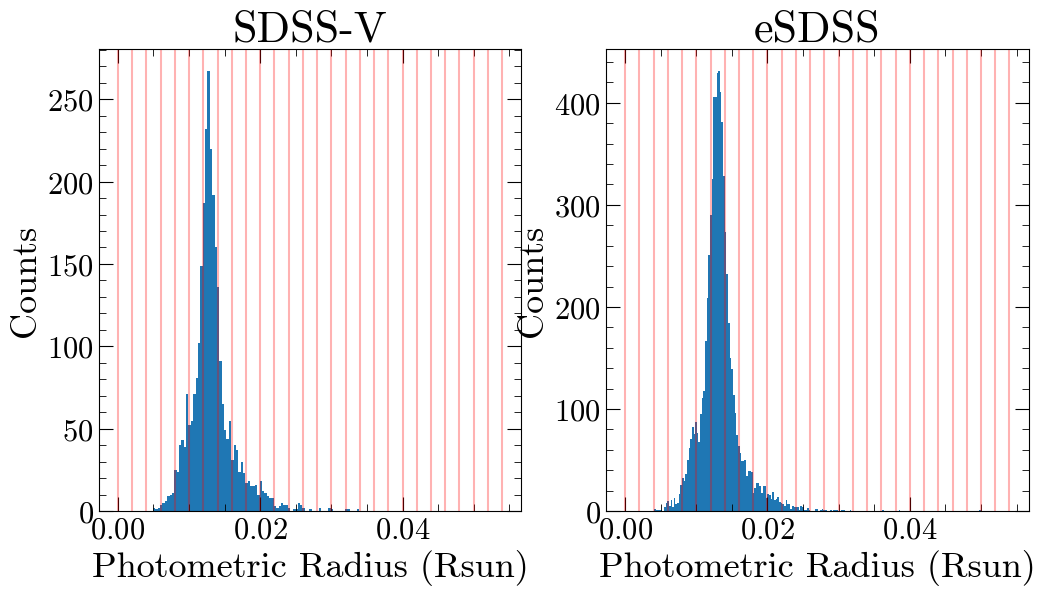

In [50]:
fig, (ax1,ax2) =plt.subplots(1,2,figsize=(12,6))

ax1.hist(SDSSV_tab_tempdep['radius_phot'])
for i in range(len(r_bins)):
    ax1.axvline(x = r_bins[i], color = 'r',alpha=0.3)
ax1.set_xlabel(r'Photometric Radius (Rsun)')
ax1.set_ylabel(r'Counts')
ax1.set_title('SDSS-V')

ax2.hist(eSDSS_tab_tempdep['radius_phot'])
for i in range(len(r_bins)):
    ax2.axvline(x = r_bins[i], color = 'r',alpha=0.3)
ax2.set_xlabel(r'Photometric Radius (Rsun)')
ax2.set_ylabel(r'Counts')
ax2.set_title('eSDSS')

In [51]:
def bin_by_radius(table,verbose=False):
    #bin by radius
    r_bin_ids=[]
    r_bin_id_ranges=[]
    r_bin_id_centers=[]
    for i in range(len(table)):
        radius=table['radius_phot'][i]
        for j in range(len(r_bin_ranges)):
            if r_bin_ranges[j][0]<radius<r_bin_ranges[j][1]:
                r_bin_ids.append(j)
                r_bin_id_ranges.append(r_bin_ranges[j])
                r_bin_id_centers.append(r_bin_centers[j])
    table['radius_bin_id']=r_bin_ids
    table['radius_bin_range']=r_bin_id_ranges
    table['radius_bin_center']=r_bin_id_centers
    
    if verbose==True:
        for i in range(len(r_bin_ranges)):
            bin_num=r_bin_nums[i]
            bin_range=r_bin_ranges[i]
            tmp=table.query('radius_bin_id==@bin_num')
            print('Bin id=', bin_num,' Bin range=',bin_range,' Rsun, Number of WDs in bin=',len(tmp))
            
    return(table)

In [52]:
SDSSV_tab_tempdep=bin_by_radius(SDSSV_tab_tempdep)
eSDSS_tab_tempdep=bin_by_radius(eSDSS_tab_tempdep)
tab_tempdep=bin_by_radius(tab_tempdep)

### By spectroscopic Logg

In [53]:
g_bins=np.round(np.arange(7,9.1,0.1),1)
print(g_bins)

g_bin_ranges=[]
g_bin_centers=[]
for i in range(len(g_bins)-1):
    array=[g_bins[i],g_bins[i+1]]
    half=0.5*(g_bins[i]+g_bins[i+1])
    g_bin_ranges.append(array)
    g_bin_centers.append(half)
g_bin_nums=np.arange(0,len(g_bin_ranges))

#save the bin info
np.savez('csv/logg_bins',bins=g_bins,ranges=g_bin_ranges,centers=g_bin_centers,nums=g_bin_nums)

[7.  7.1 7.2 7.3 7.4 7.5 7.6 7.7 7.8 7.9 8.  8.1 8.2 8.3 8.4 8.5 8.6 8.7
 8.8 8.9 9. ]


Text(0.5, 1.0, 'eSDSS')

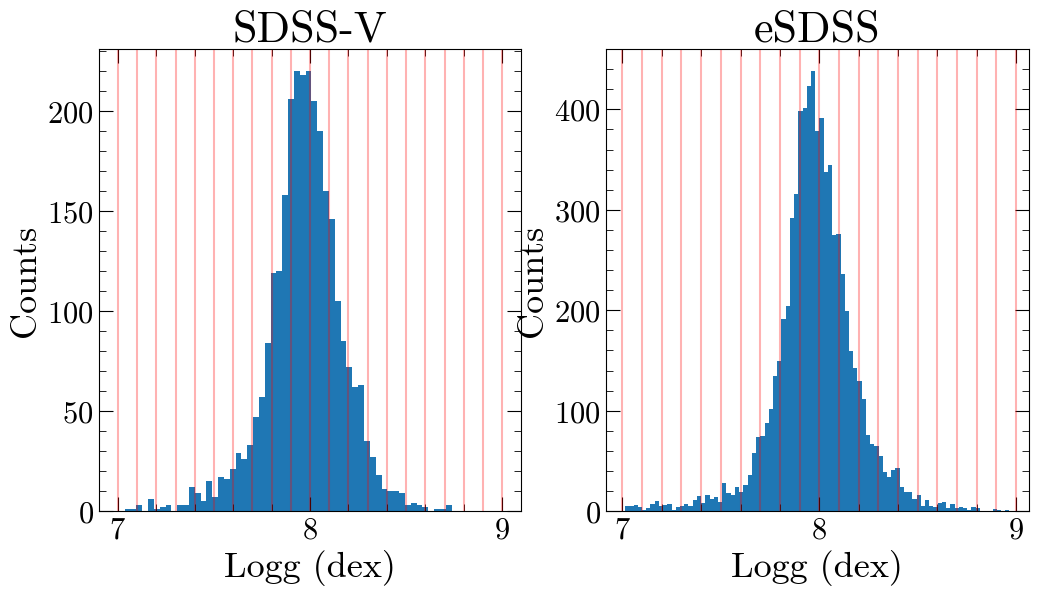

In [54]:
fig, (ax1,ax2) =plt.subplots(1,2,figsize=(12,6))

ax1.hist(SDSSV_tab_tempdep['logg_prf_coadd'])
for i in range(len(g_bins)):
    ax1.axvline(x = g_bins[i], color = 'r',alpha=0.3)
ax1.set_xlabel(r'Logg (dex)')
ax1.set_ylabel(r'Counts')
ax1.set_title('SDSS-V')

ax2.hist(eSDSS_tab_tempdep['logg_prf_coadd'])
for i in range(len(g_bins)):
    ax2.axvline(x = g_bins[i], color = 'r',alpha=0.3)
ax2.set_xlabel(r'Logg (dex)')
ax2.set_ylabel(r'Counts')
ax2.set_title('eSDSS')


In [55]:
def bin_by_logg(table,verbose=False):
    #bin by logg
    
    g_bin_ids=[]
    g_bin_id_ranges=[]
    g_bin_id_centers=[]
    for i in range(len(table)):
        logg=table['logg_prf_coadd'][i]
        for j in range(len(g_bin_ranges)):
            if g_bin_ranges[j][0]<logg<=g_bin_ranges[j][1]:
                g_bin_ids.append(j)
                g_bin_id_ranges.append(g_bin_ranges[j])
                g_bin_id_centers.append(g_bin_centers[j])
    table['logg_bin_id']=g_bin_ids
    table['logg_bin_range']=g_bin_id_ranges
    table['logg_bin_center']=g_bin_id_centers
    
    if verbose==True:
        for i in range(len(g_bin_ranges)):
            bin_num=g_bin_nums[i]
            bin_range=g_bin_ranges[i]
            tmp=table.query('logg_bin_id==@bin_num')
            print('Bin id=', bin_num,' Bin range=',bin_range,' dex, Number of WDs in bin=',len(tmp))
    return(table)

In [56]:
SDSSV_tab_tempdep=bin_by_logg(SDSSV_tab_tempdep)
eSDSS_tab_tempdep=bin_by_logg(eSDSS_tab_tempdep)
tab_tempdep=bin_by_logg(tab_tempdep)

# Save the tables
Save separate tables for SDSSV and eSDSS, also save combined table

In [57]:
SDSSV_tab_tempdep.to_csv('csv/SDSSV_tempdep_sample.csv',index=False)
eSDSS_tab_tempdep.to_csv('csv/eSDSS_tempdep_sample.csv',index=False)
tab_tempdep.to_csv('csv/tempdep_sample.csv',index=False)

# Add flag indicating whether object was used in temperature dependence sample and asymmetric drift corrected RVs to the full sample dataframes

In [59]:
SDSSV_tab_tempdep_merge=SDSSV_tab_tempdep[['gaia_dr3_source_id','rv_corv_asym_corr','asym_corr']]
eSDSS_tab_tempdep_merge=eSDSS_tab_tempdep[['gaia_dr3_source_id','rv_corv_asym_corr','asym_corr']]

SDSSV_tab_tempdep_merge['tempdep_catalog_flag']=np.full(len(SDSSV_tab_tempdep_merge),True)
eSDSS_tab_tempdep_merge['tempdep_catalog_flag']=np.full(len(eSDSS_tab_tempdep_merge),True)

SDSSV_tab=pd.merge(left=SDSSV_tab,right=SDSSV_tab_tempdep_merge,on='gaia_dr3_source_id',how="outer")
#replace all nans in flag columns with False
SDSSV_tab['tempdep_catalog_flag']=SDSSV_tab['tempdep_catalog_flag'].fillna(False)

eSDSS_tab=pd.merge(left=eSDSS_tab,right=eSDSS_tab_tempdep_merge,on='gaia_dr3_source_id',how="outer")
#replace all nans in flag columns with False
eSDSS_tab['tempdep_catalog_flag']=eSDSS_tab['tempdep_catalog_flag'].fillna(False)

#save as .csv
SDSSV_tab.to_csv('csv/SDSSV_DA_df.csv',index=False)
eSDSS_tab.to_csv('csv/eSDSS_DA_df.csv',index=False)

#save to backup
SDSSV_tab.to_csv('csv/SDSSV_DA_df_nb06.csv',index=False)
eSDSS_tab.to_csv('csv/eSDSS_DA_df_nb06.csv',index=False)

# Save the final catalogs as .fits files to be published as a SDSS Value Added Catalog (VAC)

In [60]:
#save the new .fits files

#drop unnecessary columns and re-order columns
SDSSV_tab_dropped=SDSSV_tab[['gaia_dr3_source_id','fieldid','mjd','catalogid','snr','p_da','ra','dec','l','b','r_med_geo','r_lo_geo','r_hi_geo',
                            'pmra','pmra_error','pmdec','pmdec_error','phot_g_mean_flux','phot_g_mean_flux_error',
                            'phot_g_mean_mag','phot_bp_mean_flux','phot_bp_mean_flux_error','phot_bp_mean_mag','phot_rp_mean_flux',
                            'phot_rp_mean_flux_error','phot_rp_mean_mag','phot_bp_rp_excess_factor','no_gaia_phot','clean',
                            'psf_mag_u','psf_mag_g','psf_mag_r','psf_mag_i','psf_mag_z','psf_magerr_u','psf_magerr_g',
                            'psf_magerr_r','psf_magerr_i','psf_magerr_z','psf_flux_u','psf_flux_g','psf_flux_r','psf_flux_i',
                            'psf_flux_z','psf_fluxivar_u','psf_fluxivar_g','psf_fluxivar_r','psf_fluxivar_i','psf_fluxivar_z',
                            'mag_ab_u','magerr_ab_u','mag_ab_g','magerr_ab_g','mag_ab_r','magerr_ab_r','mag_ab_i','magerr_ab_i',
                            'mag_ab_z','magerr_ab_z','no_sdss_phot','rv_falcon','e_rv_falcon','falcon_flag','logg_raddi',
                            'e_logg_raddi','mass_raddi','e_mass_raddi','radius_raddi','rv_raddi','e_rv_raddi','teff_raddi','e_teff_raddi',
                            'e_radius_raddi','raddi_flag','teff_anguiano','e_teff_anguiano','mass_anguiano','e_mass_anguiano','logg_anguiano',
                            'e_logg_anguiano','rv_anguiano','e_rv_anguiano','radius_anguiano','e_radius_anguiano','anguiano_flag',
                            'teff_gentile','e_teff_gentile','logg_gentile','e_logg_gentile','mass_gentile','e_mass_gentile','radius_gentile',
                            'e_radius_gentile','gentile_flag','teff_koester','e_teff_koester','logg_koester','e_logg_koester','koester_flag',
                            'teff_kepler','e_teff_kepler','logg_kepler','e_logg_kepler','rv_kepler','e_rv_kepler','mass_kepler',
                            'e_mass_kepler','radius_kepler','e_radius_kepler','kepler_flag','snr_coadd','nspec_coadd',
                            'rv_corv_ind','e_rv_corv_ind','teff_corv_ind',
                            'logg_corv_ind','rv_corv_coadd','e_rv_corv_coadd','teff_corv_coadd','logg_corv_coadd',
                            'e_rv_corv_ind_full','e_rv_corv_coadd_full','rv_corv_mean','e_rv_corv_mean','nspec_mean_rv_corv','teff_prf_ind',
                            'e_teff_prf_ind','logg_prf_ind','e_logg_prf_ind','teff_prf_coadd','e_teff_prf_coadd','logg_prf_coadd',
                            'e_logg_prf_coadd','e_teff_prf_ind_full','e_logg_prf_ind_full','e_teff_prf_coadd_full','e_logg_prf_coadd_full',
                            'teff_prf_mean','e_teff_prf_mean','logg_prf_mean','e_logg_prf_mean','nspec_mean_teff','nspec_mean_logg',
                            'av_lo','u_ext_lo','g_ext_lo','r_ext_lo','i_ext_lo','z_ext_lo','gaia_g_ext_lo','gaia_bp_ext_lo','gaia_rp_ext_lo',
                            'u_dered_lo','g_dered_lo','r_dered_lo','i_dered_lo','z_dered_lo','gaia_g_dered_lo','gaia_bp_dered_lo',
                            'gaia_rp_dered_lo','av_med','u_ext_med','g_ext_med','r_ext_med','i_ext_med','z_ext_med','gaia_g_ext_med',
                            'gaia_bp_ext_med','gaia_rp_ext_med','u_dered_med','g_dered_med','r_dered_med','i_dered_med','z_dered_med',
                            'gaia_g_dered_med','gaia_bp_dered_med','gaia_rp_dered_med','av_hi','u_ext_hi','g_ext_hi','r_ext_hi','i_ext_hi',
                            'z_ext_hi','gaia_g_ext_hi','gaia_bp_ext_hi','gaia_rp_ext_hi','u_dered_hi','g_dered_hi','r_dered_hi','i_dered_hi',
                            'z_dered_hi','gaia_g_dered_hi','gaia_bp_dered_hi','gaia_rp_dered_hi','phot_used','phot_radius_sdss_lo',
                            'e_phot_radius_sdss_lo','phot_teff_sdss_lo','e_phot_teff_sdss_lo','phot_redchi_sdss_lo','phot_radius_gaia_lo',
                            'e_phot_radius_gaia_lo','phot_teff_gaia_lo','e_phot_teff_gaia_lo','phot_redchi_gaia_lo','phot_radius_sdss_med',
                            'e_phot_radius_sdss_med','phot_teff_sdss_med','e_phot_teff_sdss_med','phot_redchi_sdss_med','phot_radius_gaia_med',
                            'e_phot_radius_gaia_med','phot_teff_gaia_med','e_phot_teff_gaia_med','phot_redchi_gaia_med','phot_radius_sdss_hi',
                            'e_phot_radius_sdss_hi','phot_teff_sdss_hi','e_phot_teff_sdss_hi','phot_redchi_sdss_hi','phot_radius_gaia_hi',
                            'e_phot_radius_gaia_hi','phot_teff_gaia_hi','e_phot_teff_gaia_hi','phot_redchi_gaia_hi','phot_logg_sdss_lo','e_phot_logg_sdss_lo','sdss_logg_flag_lo',
                            'gaia_logg_flag_lo','phot_logg_sdss_med','e_phot_logg_sdss_med','sdss_logg_flag_med','gaia_logg_flag_med',
                            'phot_logg_sdss_hi','e_phot_logg_sdss_hi','sdss_logg_flag_hi','gaia_logg_flag_hi',
                            'radius_phot_sdss','e_radius_phot_sdss','radius_phot_gaia','e_radius_phot_gaia','teff_phot_sdss',
                            'e_teff_phot_sdss','teff_phot_gaia','e_teff_phot_gaia','phot_err_sdss','phot_err_gaia',
                            'radius_phot','e_radius_phot','teff_phot','e_teff_phot','e_radius_phot_full','e_teff_phot_full','mass_rad_logg',
                            'e_mass_rad_logg','mass_logg_theory','e_mass_logg_theory','mass_rad_theory','e_mass_rad_theory','rv_corv_lsr',
                            'rv_corv_asym_corr','asym_corr','tempdep_catalog_flag','eta','ruwe','binary_flag','speed_lsr','thin_disk_flag']]

eSDSS_tab_dropped=eSDSS_tab[['gaia_dr3_source_id','plate','mjd','fiber','snr','spec_avail','ra','dec','l','b','r_med_geo','r_lo_geo','r_hi_geo',
                            'pmra','pmra_error','pmdec','pmdec_error','phot_g_mean_flux','phot_g_mean_flux_error',
                            'phot_g_mean_mag','phot_bp_mean_flux','phot_bp_mean_flux_error','phot_bp_mean_mag','phot_rp_mean_flux',
                            'phot_rp_mean_flux_error','phot_rp_mean_mag','phot_bp_rp_excess_factor','no_gaia_phot','clean',
                            'psf_mag_u','psf_mag_g','psf_mag_r','psf_mag_i','psf_mag_z','psf_magerr_u','psf_magerr_g',
                            'psf_magerr_r','psf_magerr_i','psf_magerr_z','psf_flux_u','psf_flux_g','psf_flux_r','psf_flux_i',
                            'psf_flux_z','psf_fluxivar_u','psf_fluxivar_g','psf_fluxivar_r','psf_fluxivar_i','psf_fluxivar_z',
                            'mag_ab_u','magerr_ab_u','mag_ab_g','magerr_ab_g','mag_ab_r','magerr_ab_r','mag_ab_i','magerr_ab_i',
                            'mag_ab_z','magerr_ab_z','no_sdss_phot',
                            'teff_gentile','e_teff_gentile','logg_gentile','e_logg_gentile','mass_gentile','e_mass_gentile','radius_gentile',
                            'e_radius_gentile','sdss_dr','teff_sdss_dr','e_teff_sdss_dr','logg_sdss_dr','e_logg_sdss_dr','teff1d_sdss_dr',
                            'e_teff1d_sdss_dr','logg1d_sdss_dr','e_logg1d_sdss_dr','rv_sdss_dr','e_rv_sdss_dr','mass_sdss_dr','e_mass_sdss_dr',
                            'mass1d_sdss_dr','e_mass1d_sdss_dr','radius_sdss_dr','e_radius_sdss_dr','radius1d_sdss_dr','e_radius1d_sdss_dr',
                            'snr_coadd','nspec_coadd',
                            'rv_corv_ind','e_rv_corv_ind','teff_corv_ind',
                            'logg_corv_ind','rv_corv_coadd','e_rv_corv_coadd','teff_corv_coadd','logg_corv_coadd',
                            'e_rv_corv_ind_full','e_rv_corv_coadd_full','rv_corv_mean','e_rv_corv_mean','nspec_mean_rv_corv','teff_prf_ind',
                            'e_teff_prf_ind','logg_prf_ind','e_logg_prf_ind','teff_prf_coadd','e_teff_prf_coadd','logg_prf_coadd',
                            'e_logg_prf_coadd','e_teff_prf_ind_full','e_logg_prf_ind_full','e_teff_prf_coadd_full','e_logg_prf_coadd_full',
                            'teff_prf_mean','e_teff_prf_mean','logg_prf_mean','e_logg_prf_mean','nspec_mean_teff','nspec_mean_logg',
                            'av_lo','u_ext_lo','g_ext_lo','r_ext_lo','i_ext_lo','z_ext_lo','gaia_g_ext_lo','gaia_bp_ext_lo','gaia_rp_ext_lo',
                            'u_dered_lo','g_dered_lo','r_dered_lo','i_dered_lo','z_dered_lo','gaia_g_dered_lo','gaia_bp_dered_lo',
                            'gaia_rp_dered_lo','av_med','u_ext_med','g_ext_med','r_ext_med','i_ext_med','z_ext_med','gaia_g_ext_med',
                            'gaia_bp_ext_med','gaia_rp_ext_med','u_dered_med','g_dered_med','r_dered_med','i_dered_med','z_dered_med',
                            'gaia_g_dered_med','gaia_bp_dered_med','gaia_rp_dered_med','av_hi','u_ext_hi','g_ext_hi','r_ext_hi','i_ext_hi',
                            'z_ext_hi','gaia_g_ext_hi','gaia_bp_ext_hi','gaia_rp_ext_hi','u_dered_hi','g_dered_hi','r_dered_hi','i_dered_hi',
                            'z_dered_hi','gaia_g_dered_hi','gaia_bp_dered_hi','gaia_rp_dered_hi','phot_used','phot_radius_sdss_lo',
                            'e_phot_radius_sdss_lo','phot_teff_sdss_lo','e_phot_teff_sdss_lo','phot_redchi_sdss_lo','phot_radius_gaia_lo',
                            'e_phot_radius_gaia_lo','phot_teff_gaia_lo','e_phot_teff_gaia_lo','phot_redchi_gaia_lo','phot_radius_sdss_med',
                            'e_phot_radius_sdss_med','phot_teff_sdss_med','e_phot_teff_sdss_med','phot_redchi_sdss_med','phot_radius_gaia_med',
                            'e_phot_radius_gaia_med','phot_teff_gaia_med','e_phot_teff_gaia_med','phot_redchi_gaia_med','phot_radius_sdss_hi',
                            'e_phot_radius_sdss_hi','phot_teff_sdss_hi','e_phot_teff_sdss_hi','phot_redchi_sdss_hi','phot_radius_gaia_hi',
                            'e_phot_radius_gaia_hi','phot_teff_gaia_hi','e_phot_teff_gaia_hi','phot_redchi_gaia_hi','phot_logg_sdss_lo','e_phot_logg_sdss_lo','sdss_logg_flag_lo',
                            'gaia_logg_flag_lo','phot_logg_sdss_med','e_phot_logg_sdss_med','sdss_logg_flag_med','gaia_logg_flag_med',
                            'phot_logg_sdss_hi','e_phot_logg_sdss_hi','sdss_logg_flag_hi','gaia_logg_flag_hi',
                            'radius_phot_sdss','e_radius_phot_sdss','radius_phot_gaia','e_radius_phot_gaia','teff_phot_sdss',
                            'e_teff_phot_sdss','teff_phot_gaia','e_teff_phot_gaia','phot_err_sdss','phot_err_gaia',
                            'radius_phot','e_radius_phot','teff_phot','e_teff_phot','e_radius_phot_full','e_teff_phot_full','mass_rad_logg',
                            'e_mass_rad_logg','mass_logg_theory','e_mass_logg_theory','mass_rad_theory','e_mass_rad_theory','rv_corv_lsr',
                            'rv_corv_asym_corr','asym_corr','tempdep_catalog_flag','eta','ruwe','binary_flag','speed_lsr','thin_disk_flag']]

#convert to astropy table
SDSSV_astpy=Table.from_pandas(SDSSV_tab_dropped)
eSDSS_astpy=Table.from_pandas(eSDSS_tab_dropped)

#write to .fits file
SDSSV_astpy.write('SDSSV_DA_df.fits', format='fits', overwrite=True)
eSDSS_astpy.write('eSDSS_DA_df.fits', format='fits', overwrite=True)

# Read back in final tables

In [61]:
SDSSV_tab_tempdep=pd.read_csv('csv/SDSSV_tempdep_sample.csv')
eSDSS_tab_tempdep=pd.read_csv('csv/eSDSS_tempdep_sample.csv')

In [62]:
SDSSV_tab=pd.read_csv('csv/SDSSV_DA_df.csv')
eSDSS_tab=pd.read_csv('csv/eSDSS_DA_df.csv')

In [63]:
#read back in
SDSSV_astpy = Table.read('SDSSV_DA_df.fits')
eSDSS_astpy = Table.read('eSDSS_DA_df.fits')

# Look into SDSS-V vs eSDSS distributions
Both for the full catalog and for the temperature dependence catalog

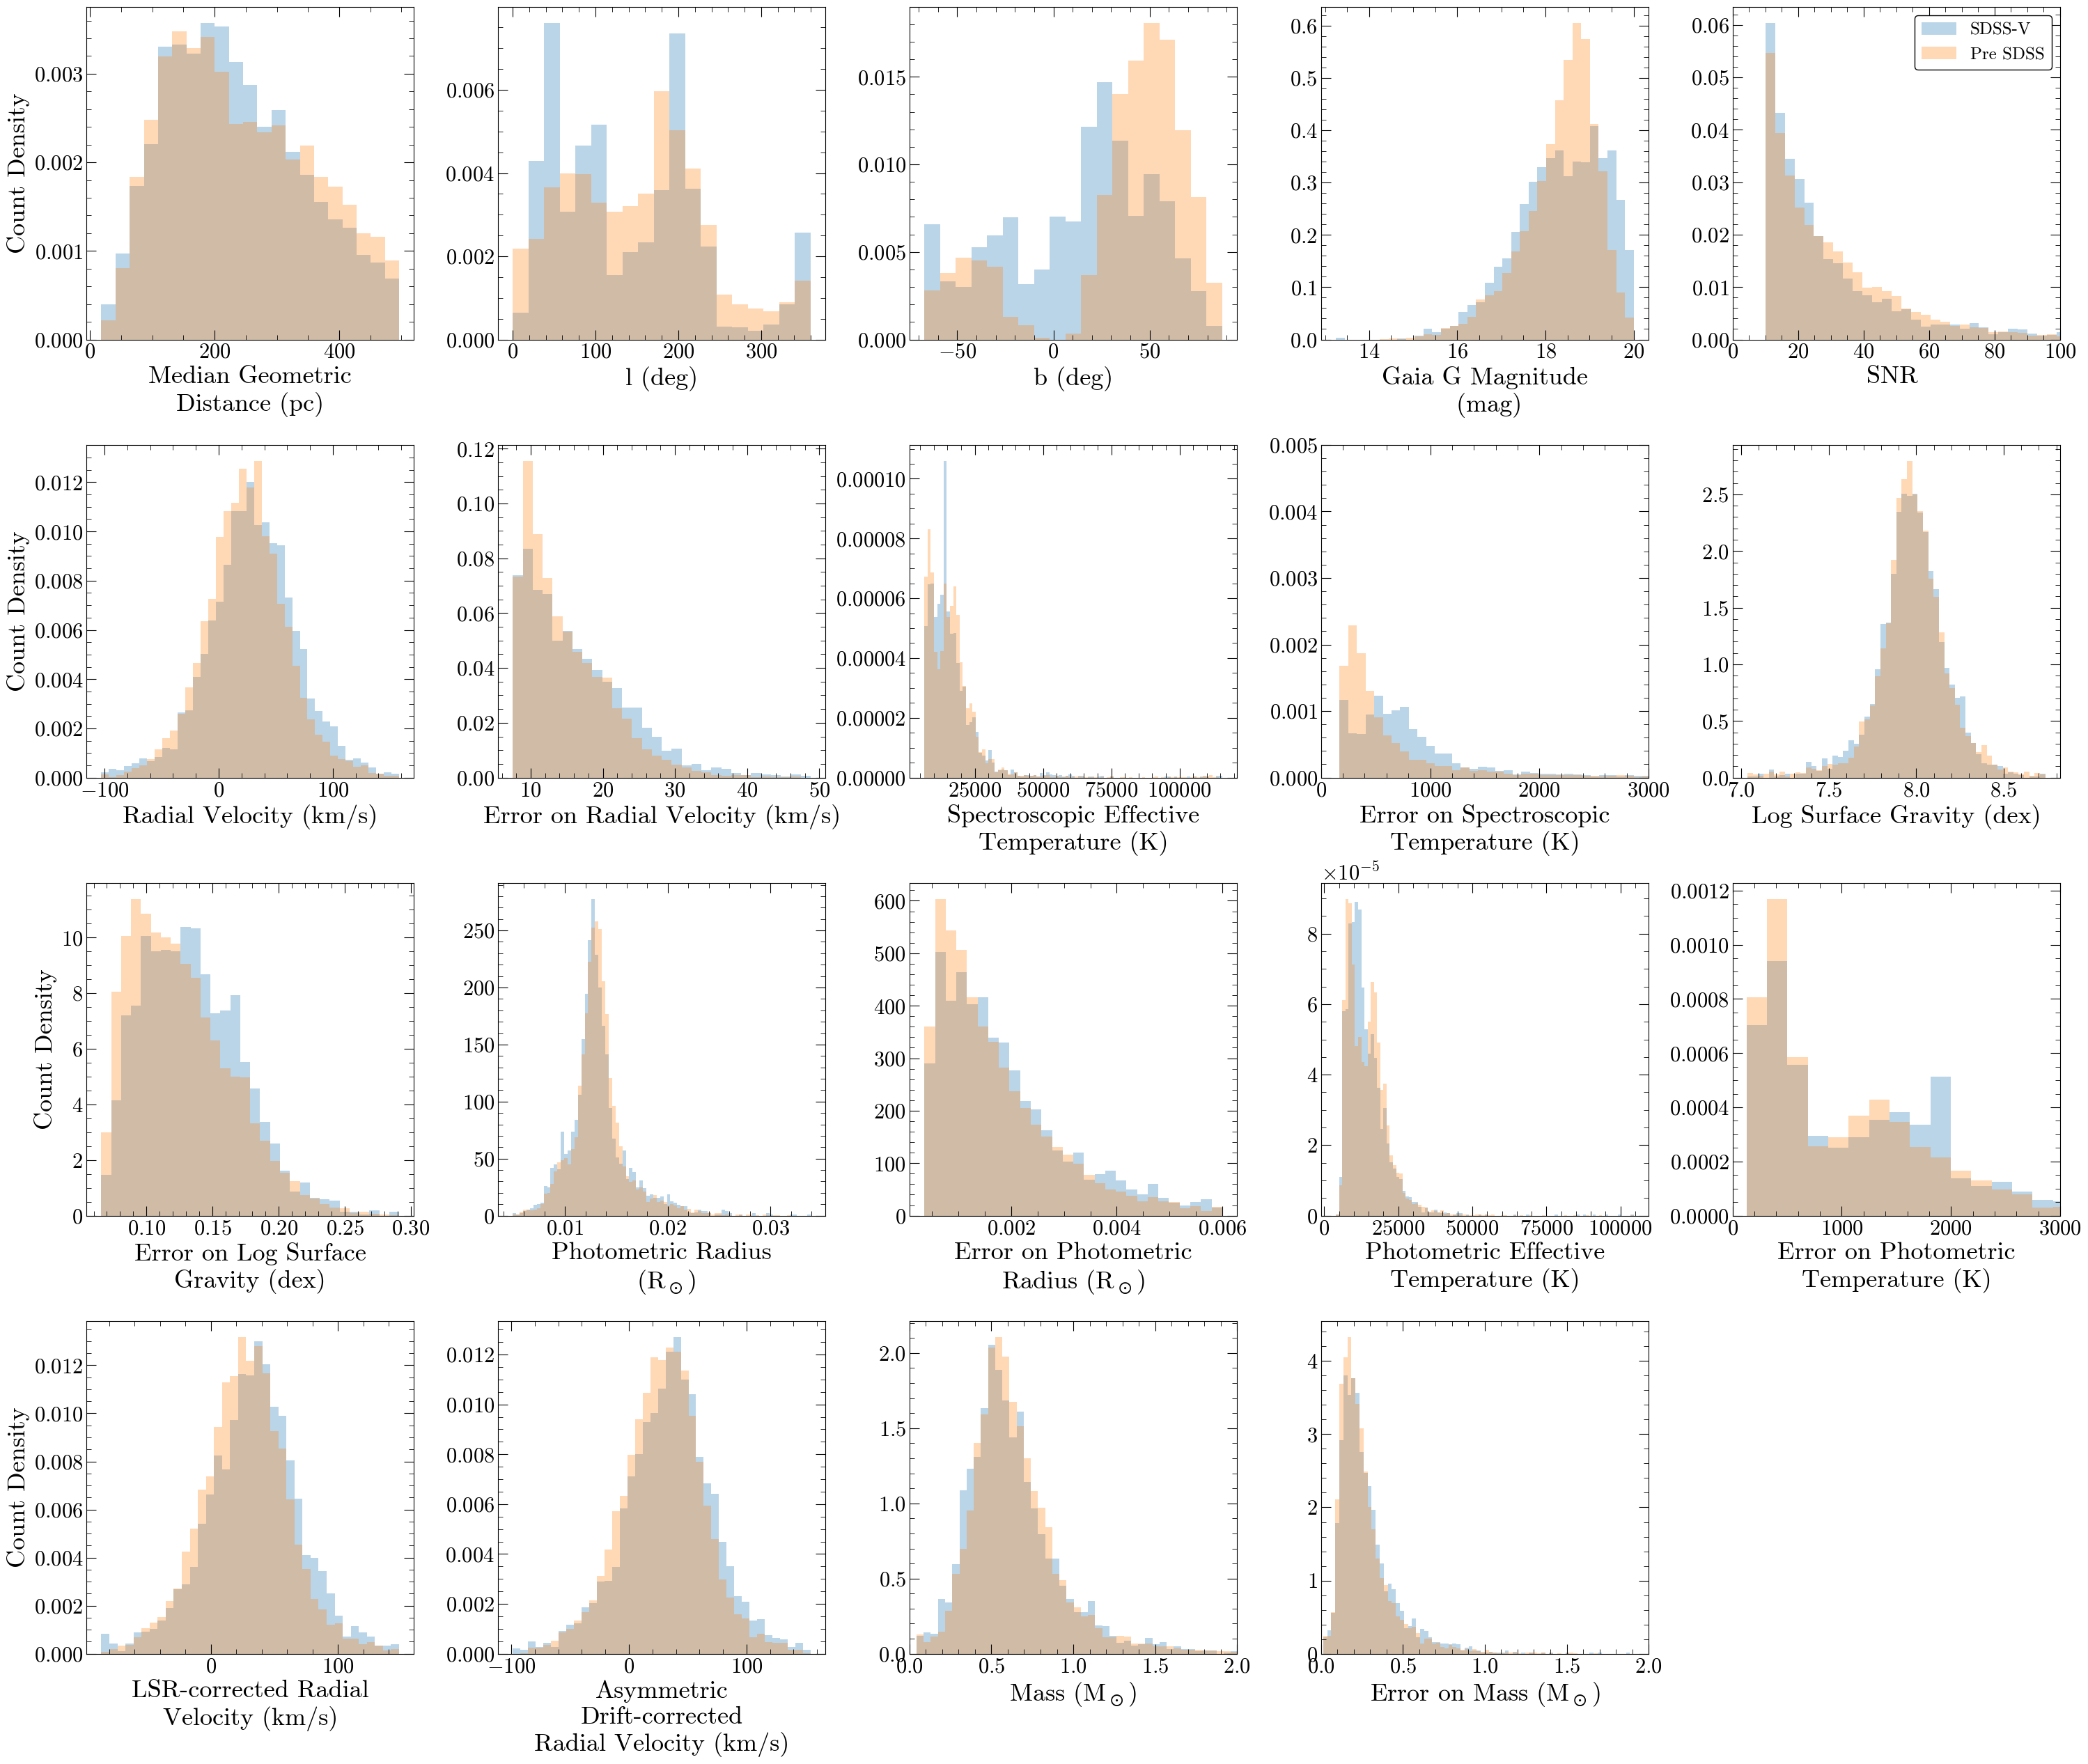

In [64]:
cols=['r_med_geo','l','b','phot_g_mean_mag','snr_coadd','rv_corv_coadd','e_rv_corv_coadd_full','teff_prf_coadd',
      'e_teff_prf_coadd_full','logg_prf_coadd','e_logg_prf_coadd_full','radius_phot','e_radius_phot_full',
      'teff_phot','e_teff_phot_full','rv_corv_lsr','rv_corv_asym_corr','mass_rad_logg','e_mass_rad_logg']
col_names=['Median Geometric\nDistance','l','b','Gaia G Magnitude\n','SNR','Radial Velocity','Error on Radial Velocity','Spectroscopic Effective\nTemperature',
           'Error on Spectroscopic\nTemperature', 'Log Surface Gravity', 'Error on Log Surface\nGravity',
           'Photometric Radius\n','Error on Photometric\nRadius','Photometric Effective\nTemperature',
           'Error on Photometric\nTemperature','LSR-corrected Radial\nVelocity',
           'Asymmetric\nDrift-corrected\nRadial Velocity','Mass','Error on Mass']
units=['(pc)','(deg)','(deg)','(mag)','','(km/s)','(km/s)','(K)','(K)','(dex)','(dex)','($R_\odot$)','($R_\odot$)','(K)','(K)','(km/s)','(km/s)','($M_\odot$)','($M_\odot$)']
lims=[0,0,0,0,[0,100],0,0,0,[0,3000],0,0,0,0,0,[0,3000],0,0,[0,2],[0,2]]

fig= plt.figure(figsize=(30,30))
plt.style.use('stefan.mplstyle')

plotnum=1
for i in range(len(cols)):
        fig.add_subplot(5,5,int(plotnum))
        (n, bins, patches) =plt.hist(SDSSV_tab_tempdep[cols[i]],density=True,alpha=0.3,label='SDSS-V')
        plt.hist(eSDSS_tab_tempdep[cols[i]],bins=bins,density=True,alpha=0.3,label='Pre SDSS')
        plt.xlabel(col_names[i]+' '+units[i])
        try:
            plt.xlim(lims[i][0],lims[i][1])
        except:
            pass
        plotnum=plotnum+1
        if i==4:
            plt.legend() 
        if i==8:
            plt.ylim(0,0.005)
        if i in (0,5,10,15):
            plt.ylabel('Count Density')
fig.tight_layout(pad=0.1)   

plt.savefig('SDSSV_vs_eSDSS_dist_tempdep.pdf')#,pad_inches=0.3)


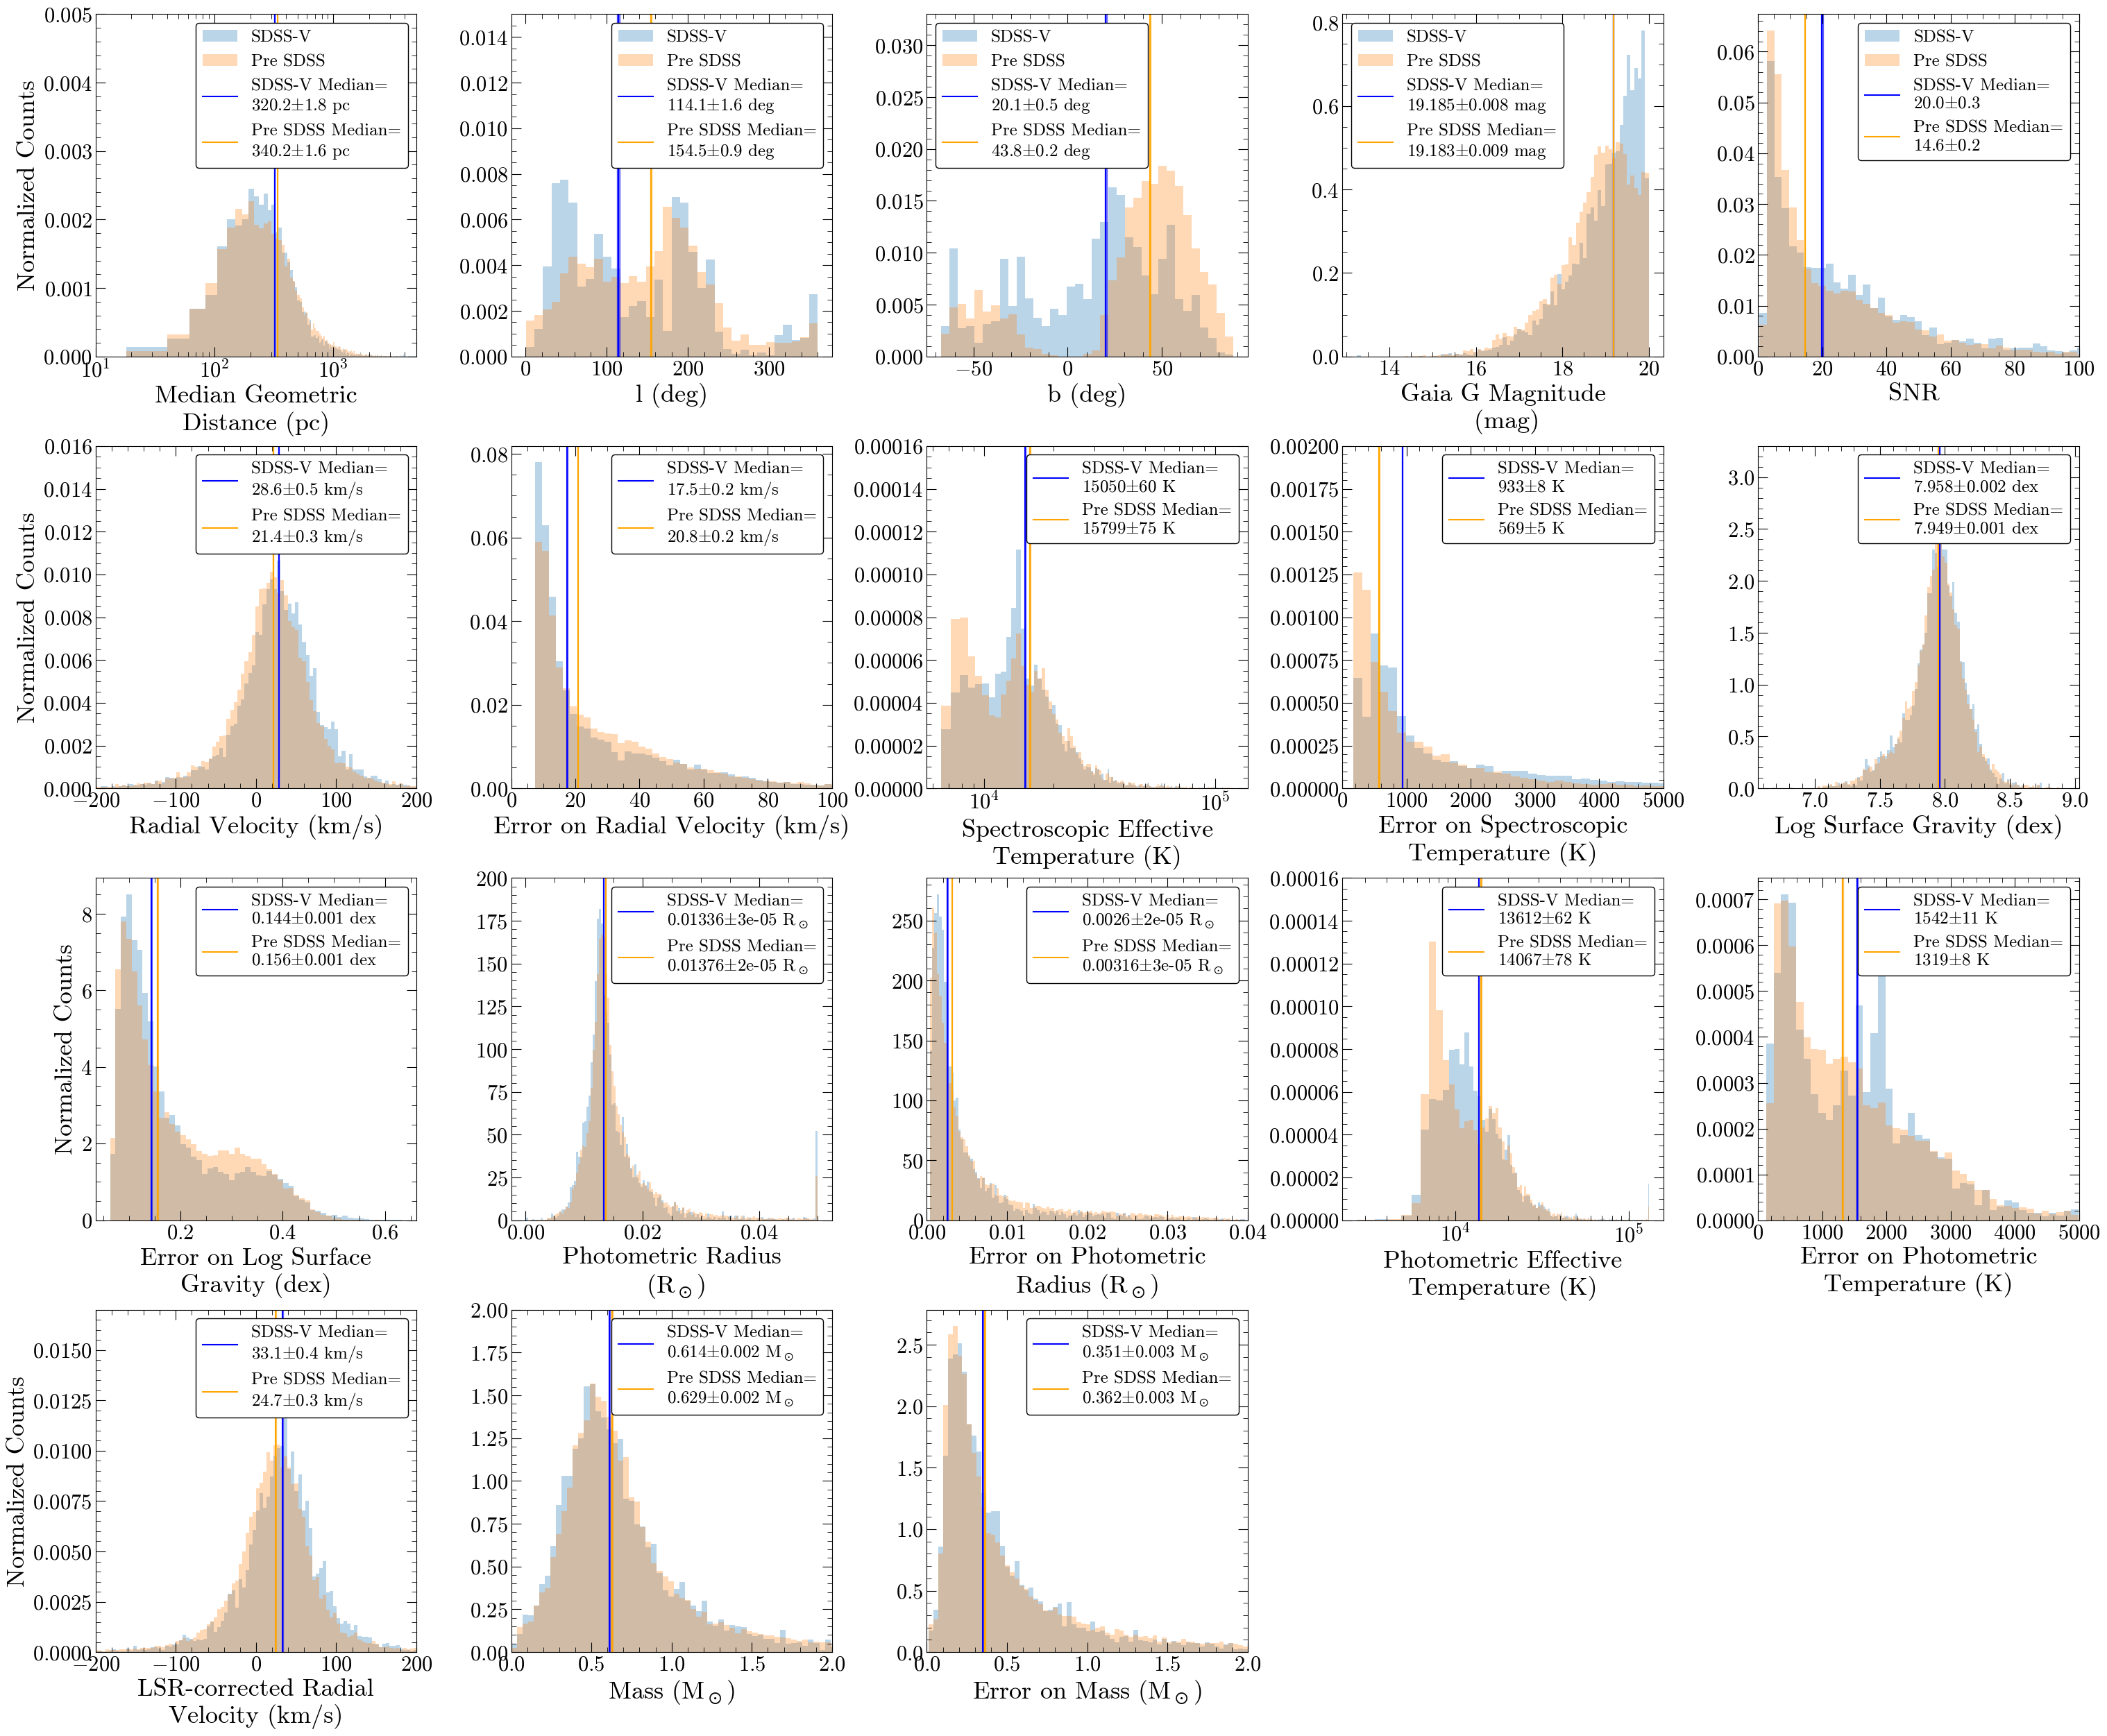

In [65]:
cols=['r_med_geo','l','b','phot_g_mean_mag','snr_coadd','rv_corv_coadd','e_rv_corv_coadd_full','teff_prf_coadd',
      'e_teff_prf_coadd_full','logg_prf_coadd','e_logg_prf_coadd_full','radius_phot','e_radius_phot_full',
      'teff_phot','e_teff_phot_full','rv_corv_lsr','mass_rad_logg','e_mass_rad_logg']
col_names=['Median Geometric\nDistance','l','b','Gaia G Magnitude\n','SNR','Radial Velocity','Error on Radial Velocity','Spectroscopic Effective\nTemperature',
           'Error on Spectroscopic\nTemperature', 'Log Surface Gravity', 'Error on Log Surface\nGravity',
           'Photometric Radius\n','Error on Photometric\nRadius','Photometric Effective\nTemperature',
           'Error on Photometric\nTemperature','LSR-corrected Radial\nVelocity','Mass','Error on Mass']
units=['(pc)','(deg)','(deg)','(mag)','','(km/s)','(km/s)','(K)','(K)','(dex)','(dex)','($R_\odot$)','($R_\odot$)','(K)','(K)','(km/s)','($M_\odot$)','($M_\odot$)']
units2=['pc','deg','deg','mag','','km/s','km/s','K','K','dex','dex','$R_\odot$','$R_\odot$','K','K','km/s','$M_\odot$','$M_\odot$']

lims=[[10,5000],0,0,0,[0,100],[-200,200],[0,100],0,[0,5000],0,0,0,[0,0.04],0,[0,5000],[-200,200],[0,2],[0,2]]
rounding=[1,1,1,3,1,1,1,1,1,3,3,5,5,1,1,1,3,3]

fig= plt.figure(figsize=(30,30))
plt.style.use('stefan.mplstyle')

plotnum=1
for i in range(len(cols)):
    #get median and uncertainty on median
    med_sdssv,std_sdssv=bootstrap_median(SDSSV_tab[cols[i]])
    med_esdss,std_esdss=bootstrap_median(eSDSS_tab[cols[i]])
    
    fig.add_subplot(5,5,int(plotnum))
    if i==12 or i==14 or i==17:
        #the dispersion in values is tripping up the histogram plotting software
        #pre-restrict the range of values
        col=cols[i]
        min_val=lims[i][0]
        max_val=lims[i][1]
        (n, bins, patches) =plt.hist(SDSSV_tab.query("{1}<`{0}` & `{0}`<{2}".format(col,min_val,max_val))[cols[i]],density=True,alpha=0.3)
        plt.hist(eSDSS_tab.query("{1}<`{0}` & `{0}`<{2}".format(col,min_val,max_val))[cols[i]],bins=bins,density=True,alpha=0.3)
    else:
        if i in (0,1,2,3,4):
            (n, bins, patches) =plt.hist(SDSSV_tab[cols[i]],density=True,alpha=0.3,label='SDSS-V')
            plt.hist(eSDSS_tab[cols[i]],bins=bins,density=True,alpha=0.3,label='Pre SDSS')
        else:
            (n, bins, patches) =plt.hist(SDSSV_tab[cols[i]],density=True,alpha=0.3)
            plt.hist(eSDSS_tab[cols[i]],bins=bins,density=True,alpha=0.3)
    if units2[i]=='K':
        plt.axvline(med_sdssv,color='blue',label='SDSS-V Median=\n'+str(int(med_sdssv))+r'$\mathrm{\pm}$'+str(int(std_sdssv))+' '+units2[i])
        plt.axvspan(med_sdssv-std_sdssv,std_sdssv+med_sdssv,color='blue',alpha=0.5)
        plt.axvline(med_esdss,color='orange',label='Pre SDSS Median=\n'+str(int(med_esdss))+r'$\mathrm{\pm}$'+str(int(std_esdss))+' '+units2[i])
        plt.axvspan(med_esdss-std_esdss,std_esdss+med_esdss,color='orange',alpha=0.5)
    else:
        plt.axvline(med_sdssv,color='blue',label='SDSS-V Median=\n'+str(np.round(med_sdssv,rounding[i]))+r'$\mathrm{\pm}$'+str(np.round(std_sdssv,rounding[i]))+' '+units2[i])
        plt.axvspan(med_sdssv-std_sdssv,std_sdssv+med_sdssv,color='blue',alpha=0.5)
        plt.axvline(med_esdss,color='orange',label='Pre SDSS Median=\n'+str(np.round(med_esdss,rounding[i]))+r'$\mathrm{\pm}$'+str(np.round(std_esdss,rounding[i]))+' '+units2[i])
        plt.axvspan(med_esdss-std_esdss,std_esdss+med_esdss,color='orange',alpha=0.5)
    plt.xlabel(col_names[i]+' '+units[i])
    plt.legend()
    try:
        plt.xlim(lims[i][0],lims[i][1])
    except:
        pass
    plotnum=plotnum+1
    if i==0:
        plt.ylim(0,0.005)
    if i==1:
        plt.ylim(0,0.015)
    if i==2:
        plt.ylim(0,0.033)
    if i==5:
        plt.ylim(0,0.016)
    if i==7:
        plt.ylim(0,0.00016)
    if i==8:
        plt.ylim(0,0.002)
    if i==9:
        plt.ylim(0,3.3)
    if i==11:
        plt.ylim(0,200)
    if i==13:
        plt.ylim(0,0.00016)
    if i==15:
        plt.ylim(0,0.017)
    if i==16:
        plt.ylim(0,2.0)
        
    if i in (0,5,10,15):
        plt.ylabel('Normalized Counts')
    if i in (0,7,13):
        plt.xscale('log')
fig.tight_layout(pad=0.1)   

plt.savefig('SDSSV_vs_eSDSS_dist_full.pdf')#,pad_inches=0.3)


### Repeat for overlap sample where same objects are in SDSS-V and eSDSS catalogs
Just look at difference in spectroscopic parameters

In [66]:
#overlap of full data sets
sdssv_ids=SDSSV_tab['gaia_dr3_source_id']
esdss_ids=eSDSS_tab['gaia_dr3_source_id']
eSDSS_overlap=eSDSS_tab[eSDSS_tab['gaia_dr3_source_id'].isin(sdssv_ids)].drop_duplicates(subset='gaia_dr3_source_id')
SDSSV_overlap=SDSSV_tab[SDSSV_tab['gaia_dr3_source_id'].isin(esdss_ids)].drop_duplicates(subset='gaia_dr3_source_id')
display(eSDSS_overlap)
display(SDSSV_overlap)

#overlap of temperature dependence data sets
sdssv_ids=SDSSV_tab_tempdep['gaia_dr3_source_id']
esdss_ids=eSDSS_tab_tempdep['gaia_dr3_source_id']
eSDSS_overlap_tempdep=eSDSS_tab_tempdep[eSDSS_tab_tempdep['gaia_dr3_source_id'].isin(sdssv_ids)]
SDSSV_overlap_tempdep=SDSSV_tab_tempdep[SDSSV_tab_tempdep['gaia_dr3_source_id'].isin(esdss_ids)]
display(eSDSS_overlap_tempdep)
display(SDSSV_overlap_tempdep)


,gaia_dr3_source_id,plate,mjd,fiber,pmf,ra,dec,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,l,b,snr_gentile,teff_gentile,e_teff_gentile,logg_gentile,e_logg_gentile,mass_gentile,e_mass_gentile,radius_gentile,e_radius_gentile,no_gaia_phot,sdss_dr,ra_sdss_dr,dec_sdss_dr,snr_sdss_dr,teff_sdss_dr,e_teff_sdss_dr,logg_sdss_dr,e_logg_sdss_dr,teff1d_sdss_dr,e_teff1d_sdss_dr,logg1d_sdss_dr,e_logg1d_sdss_dr,rv_sdss_dr,e_rv_sdss_dr,mass_sdss_dr,e_mass_sdss_dr,mass1d_sdss_dr,e_mass1d_sdss_dr,radius_sdss_dr,e_radius_sdss_dr,radius1d_sdss_dr,e_radius1d_sdss_dr,r_lo_geo,r_med_geo,r_hi_geo,no_distance,clean,prob_psf,psf_mag_u,psf_mag_g,psf_mag_r,psf_mag_i,psf_mag_z,psf_magerr_u,psf_magerr_g,psf_magerr_r,psf_magerr_i,psf_magerr_z,psf_flux_u,psf_flux_g,psf_flux_r,psf_flux_i,psf_flux_z,psf_fluxivar_u,psf_fluxivar_g,psf_fluxivar_r,psf_fluxivar_i,psf_fluxivar_z,mag_ab_u,magerr_ab_u,mag_ab_g,magerr_ab_g,mag_ab_r,magerr_ab_r,mag_ab_i,magerr_ab_i,mag_ab_z,magerr_ab_z,no_sdss_phot,snr,spec_avail,rv_corv_ind,e_rv_corv_ind,teff_corv_ind,logg_corv_ind,rv_corv_coadd,e_rv_corv_coadd,teff_corv_coadd,logg_corv_coadd,snr_coadd,nspec_coadd,eta,ruwe,binary_flag,e_rv_corv_ind_full,e_rv_corv_coadd_full,rv_corv_mean,e_rv_corv_mean,nspec_mean_rv_corv,teff_prf_ind,e_teff_prf_ind,logg_prf_ind,e_logg_prf_ind,teff_prf_coadd,e_teff_prf_coadd,logg_prf_coadd,e_logg_prf_coadd,e_teff_prf_ind_full,e_logg_prf_ind_full,e_teff_prf_coadd_full,e_logg_prf_coadd_full,teff_prf_mean,e_teff_prf_mean,logg_prf_mean,e_logg_prf_mean,nspec_mean_teff,nspec_mean_logg,av_lo,u_ext_lo,g_ext_lo,r_ext_lo,i_ext_lo,z_ext_lo,gaia_g_ext_lo,gaia_bp_ext_lo,gaia_rp_ext_lo,u_dered_lo,g_dered_lo,r_dered_lo,i_dered_lo,z_dered_lo,gaia_g_dered_lo,gaia_bp_dered_lo,gaia_rp_dered_lo,av_med,u_ext_med,g_ext_med,r_ext_med,i_ext_med,z_ext_med,gaia_g_ext_med,gaia_bp_ext_med,gaia_rp_ext_med,u_dered_med,g_dered_med,r_dered_med,i_dered_med,z_dered_med,gaia_g_dered_med,gaia_bp_dered_med,gaia_rp_dered_med,av_hi,u_ext_hi,g_ext_hi,r_ext_hi,i_ext_hi,z_ext_hi,gaia_g_ext_hi,gaia_bp_ext_hi,gaia_rp_ext_hi,u_dered_hi,g_dered_hi,r_dered_hi,i_dered_hi,z_dered_hi,gaia_g_dered_hi,gaia_bp_dered_hi,gaia_rp_dered_hi,phot_used,phot_radius_sdss_lo,e_phot_radius_sdss_lo,phot_teff_sdss_lo,e_phot_teff_sdss_lo,phot_redchi_sdss_lo,phot_radius_gaia_lo,e_phot_radius_gaia_lo,phot_teff_gaia_lo,e_phot_teff_gaia_lo,phot_redchi_gaia_lo,phot_radius_sdss_med,e_phot_radius_sdss_med,phot_teff_sdss_med,e_phot_teff_sdss_med,phot_redchi_sdss_med,phot_radius_gaia_med,e_phot_radius_gaia_med,phot_teff_gaia_med,e_phot_teff_gaia_med,phot_redchi_gaia_med,phot_radius_sdss_hi,e_phot_radius_sdss_hi,phot_teff_sdss_hi,e_phot_teff_sdss_hi,phot_redchi_sdss_hi,phot_radius_gaia_hi,e_phot_radius_gaia_hi,phot_teff_gaia_hi,e_phot_teff_gaia_hi,phot_redchi_gaia_hi,radius_phot,e_radius_phot,teff_phot,e_teff_phot,phot_logg_sdss_lo,e_phot_logg_sdss_lo,sdss_logg_flag_lo,gaia_logg_flag_lo,phot_logg_sdss_med,e_phot_logg_sdss_med,sdss_logg_flag_med,gaia_logg_flag_med,phot_logg_sdss_hi,e_phot_logg_sdss_hi,sdss_logg_flag_hi,gaia_logg_flag_hi,phot_err_sdss,phot_err_gaia,radius_phot_sdss,e_radius_phot_sdss,radius_phot_gaia,e_radius_phot_gaia,teff_phot_sdss,e_teff_phot_sdss,teff_phot_gaia,e_teff_phot_gaia,e_radius_phot_full,e_teff_phot_full,mass_rad_logg,e_mass_rad_logg,mass_logg_theory,e_mass_logg_theory,mass_rad_theory,e_mass_rad_theory,rv_corv_lsr,speed_lsr,thin_disk_flag,rv_corv_asym_corr,asym_corr,tempdep_catalog_flag
0,74698071455360,3184,54850,476,318454850476,44.726458,0.511273,-77.832683,0.248792,15.265021,0.213877,547.374558,1.266768,18.841656,285.832518,12.364519,19.198263,324.691721,19.068470,18.469217,1.115368,176.115100,-48.741906,22.0,5966.81,400.80,8.437169,0.188926,0.871187,0.124056,0.009347,0.002139,False,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

,sdss_id,gaia_dr3_source_id,fieldid,mjd,catalogid21,catalogid25,catalogid31,ra,dec,l,b,r_med_geo,r_lo_geo,r_hi_geo,bailer_jones_flags,n_exp,exptime,snr,classification,p_da,teff_snowwhite,e_teff_snowwhite,logg_snowwhite,e_logg_snowwhite,catalogid,spec_file,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_flux,phot_g_mean_flux_error,phot_g_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_bp_mean_mag,phot_rp_mean_flux,phot_rp_mean_flux_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,no_distance,no_gaia_phot,clean,prob_psf,psf_mag_u,psf_mag_g,psf_mag_r,psf_mag_i,psf_mag_z,psf_magerr_u,psf_magerr_g,psf_magerr_r,psf_magerr_i,psf_magerr_z,psf_flux_u,psf_flux_g,psf_flux_r,psf_flux_i,psf_flux_z,psf_fluxivar_u,psf_fluxivar_g,psf_fluxivar_r,psf_fluxivar_i,psf_fluxivar_z,mag_ab_u,magerr_ab_u,mag_ab_g,magerr_ab_g,mag_ab_r,magerr_ab_r,mag_ab_i,magerr_ab_i,mag_ab_z,magerr_ab_z,no_sdss_phot,rv_falcon,e_rv_falcon,falcon_flag,logg_raddi,e_logg_raddi,mass_raddi,e_mass_raddi,radius_raddi,rv_raddi,e_rv_raddi,teff_raddi,e_teff_raddi,e_radius_raddi,raddi_flag,teff_anguiano,e_teff_anguiano,mass_anguiano,e_mass_anguiano,logg_anguiano,e_logg_anguiano,snr_anguiano,rv_anguiano,e_rv_anguiano,radius_anguiano,e_radius_anguiano,anguiano_flag,teff_gentile,e_teff_gentile,logg_gentile,e_logg_gentile,mass_gentile,e_mass_gentile,radius_gentile,e_radius_gentile,gentile_flag,teff_koester,e_teff_koester,logg_koester,e_logg_koester,koester_flag,teff_kepler,e_teff_kepler,logg_kepler,e_logg_kepler,rv_kepler,e_rv_kepler,snr_kepler,mass_kepler,e_mass_kepler,radius_kepler,e_radius_kepler,kepler_flag,snowwhite_flag,rv_corv_ind,e_rv_corv_ind,teff_corv_ind,logg_corv_ind,rv_corv_coadd,e_rv_corv_coadd,teff_corv_coadd,logg_corv_coadd,snr_coadd,nspec_coadd,eta,ruwe,binary_flag,e_rv_corv_ind_full,e_rv_corv_coadd_full,rv_corv_mean,e_rv_corv_mean,nspec_mean_rv_corv,teff_prf_ind,e_teff_prf_ind,logg_prf_ind,e_logg_prf_ind,teff_prf_coadd,e_teff_prf_coadd,logg_prf_coadd,e_logg_prf_coadd,e_teff_prf_ind_full,e_logg_prf_ind_full,e_teff_prf_coadd_full,e_logg_prf_coadd_full,teff_prf_mean,e_teff_prf_mean,logg_prf_mean,e_logg_prf_mean,nspec_mean_teff,nspec_mean_logg,sdssid,av_lo,u_ext_lo,g_ext_lo,r_ext_lo,i_ext_lo,z_ext_lo,gaia_g_ext_lo,gaia_bp_ext_lo,gaia_rp_ext_lo,u_dered_lo,g_dered_lo,r_dered_lo,i_dered_lo,z_dered_lo,gaia_g_dered_lo,gaia_bp_dered_lo,gaia_rp_dered_lo,av_med,u_ext_med,g_ext_med,r_ext_med,i_ext_med,z_ext_med,gaia_g_ext_med,gaia_bp_ext_med,gaia_rp_ext_med,u_dered_med,g_dered_med,r_dered_med,i_dered_med,z_dered_med,gaia_g_dered_med,gaia_bp_dered_med,gaia_rp_dered_med,av_hi,u_ext_hi,g_ext_hi,r_ext_hi,i_ext_hi,z_ext_hi,gaia_g_ext_hi,gaia_bp_ext_hi,gaia_rp_ext_hi,u_dered_hi,g_dered_hi,r_dered_hi,i_dered_hi,z_dered_hi,gaia_g_dered_hi,gaia_bp_dered_hi,gaia_rp_dered_hi,phot_used,phot_radius_sdss_lo,e_phot_radius_sdss_lo,phot_teff_sdss_lo,e_phot_teff_sdss_lo,phot_redchi_sdss_lo,phot_radius_gaia_lo,e_phot_radius_gaia_lo,phot_teff_gaia_lo,e_phot_teff_gaia_lo,phot_redchi_gaia_lo,phot_radius_sdss_med,e_phot_radius_sdss_med,phot_teff_sdss_med,e_phot_teff_sdss_med,phot_redchi_sdss_med,phot_radius_gaia_med,e_phot_radius_gaia_med,phot_teff_gaia_med,e_phot_teff_gaia_med,phot_redchi_gaia_med,phot_radius_sdss_hi,e_phot_radius_sdss_hi,phot_teff_sdss_hi,e_phot_teff_sdss_hi,phot_redchi_sdss_hi,phot_radius_gaia_hi,e_phot_radius_gaia_hi,phot_teff_gaia_hi,e_phot_teff_gaia_hi,phot_redchi_gaia_hi,radius_phot,e_radius_phot,teff_phot,e_teff_phot,phot_logg_sdss_lo,e_phot_logg_sdss_lo,sdss_logg_flag_lo,gaia_logg_flag_lo,phot_logg_sdss_med,e_phot_logg_sdss_med,sdss_logg_flag_med,gaia_logg_flag_med,phot_logg_sdss_hi,e_phot_logg_sdss_hi,sdss_logg_flag_hi,gaia_logg_flag_hi,phot_err_sdss,phot_err_gaia,radius_phot_sdss,e_radius_phot_sdss,radius_phot_gaia,e_radius_phot_gaia,teff_phot_sdss,e_teff_phot_sdss,teff_phot_gaia,e_teff_phot_gaia,e_radius_phot_full,e_teff_phot_full,mass_rad_logg,e_mass_rad_logg,mass_logg_theory,e_mass_logg_theory,mass_rad_theory,e_mass_rad_theory,rv_corv_lsr,speed_lsr,thin_disk_flag,rv_

,gaia_dr3_source_id,ra,dec,l,b,r_med_geo,phot_g_mean_mag,pmra,pmdec,rv_corv_coadd,e_rv_corv_coadd_full,snr_coadd,nspec_coadd,teff_prf_coadd,e_teff_prf_coadd_full,logg_prf_coadd,e_logg_prf_coadd_full,phot_used,phot_err_sdss,phot_err_gaia,radius_phot,e_radius_phot_full,teff_phot,e_teff_phot_full,mass_rad_logg,e_mass_rad_logg,mass_logg_theory,e_mass_logg_theory,mass_rad_theory,e_mass_rad_theory,rv_corv_lsr,rv_corv_asym_corr,asym_corr,sdssv_flag,radius_bin_id,radius_bin_range,radius_bin_center,logg_bin_id,logg_bin_range,logg_bin_center
0,74698071455360,44.726458,0.511273,176.115100,-48.741906,67.303880,18.841656,-77.832683,15.265021,107.687179,11.598924,51.492603,4.0,33908.44,14697.860269,7.80824,0.224016,1,0.028951,15.716494,0.008811,0.000667,6216.240027,221.535054,0.181895,0.097781,0.560582,0.236665,0.897688,0.123118,95.480793,82.916973,-12.563820,False,4,"[0.008, 0.01]",0.009,8,"[7.8, 7.9]",7.85
1,152935195517952,45.925843,0.886111,176.967085,-47.621127,224.510940,17.980106,-31.145043,-27.364172,5.640172,8.266297,86.955193,3.0,13795.44,483.128381,8.02632,0.075613,1,0.026164,9.970716,0.014460,0.001084,14397.339856,621.549742,0.809503,0.185969,0.618989,0.084839,0.531417,0.087295,-6.750175,-19.425822,-12.675648,False,7,"[0.014, 0.016]",0.015,10,"[8.0, 8.1]",8.05
2,288175125714560,44.287428,0.774346,175.361855,-48.867643,153.012150,17.467531,-18.373571,-18.706614,10.442885,8.687746,60.559364,2.0,12846.64,407.345957,8.07984,0.083862,1,0.024781,13.714243,0.013135,0.000690,12415.216971,378.060023,0.755512,0.166083,0.647144,0.099306,0.584310,0.079074,-1.644372,-14.157160,-12.512788,False,6,"[0.012, 0.014]",0.013,10,"[8.0, 8.1]",8.05
174,577026966432521088,136.544176,1.373320,228.483069,30.291118,95.613920,19.083698,-72.239540,44.036680,140.321828,19.561980,17.483089,2.0,7483.92,1141.943029,7.97632,0.201437,1,0.037459,7.902261,0.008556,0.000945,7236.619127,335.430005,0.252618,0.129787,0.577388,0.216962,0.922265,0.178840,129.712059,124.274566,-5.437493,False,4,"[0.008, 0.01]",0.009,9,"[7.9, 8.0]",7.95
175,577571774444224640,136.320634,3.268051,226.452042,31.058331,205.143740,17.454714,-17.408493,-1.976078,40.738395,8.207594,88.375303,2.0,19406.24,266.075694,7.87708,0.068375,1,0.024646,10.165059,0.013200,0.000842,19257.656397,1076.182910,0.478398,0.096964,0.556157,0.062711,0.606246,0.100042,30.327869,24.884485,-5.443384,False,6,"[0.012, 0.014]",0.013,8,"[7.8, 7.9]",7.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7204,6340880465008065152,223.649994,-1.197876,354.217589,49.011385,105.791336,17.317741,-76.758504,12.742252,9.336916,8.667411,73.002080,2.0,14254.68,370.817352,8.28472,0.076819,1,0.020653,10.838106,0.009811,0.000470,12576.785027,325.679695,0.675562,0.135931,0.774372,0.094847,0.826656,0.077668,21.244190,33.680130,12.435940,False,4,"[0.008, 0.01]",0.009,12,"[8.2, 8.3]",8.25
7221,6898597773873147008,320.294965,-6.999496,44.871907,-36.336722,155.146550,16.522165,52.913439,-46.740482,-3.038477,8.366128,67.749770,1.0,23044.04,372.717121,7.92616,0.073442,1,0.019917,16.772561,0.013583,0.000577,21861.027705,1028.693571,0.567169,0.107345,0.587592,0.072530,0.595053,0.067863,5.958871,10.409547,4.450676,False,6,"[0.012, 0.014]",0.013,9,"[7.9, 8.0]",7.95
7235,6913234133360925568,313.126199,-5.792358,42.109870,-29.492282,414.209840,18.447718,-3.017551,0.501707,22.358522,19.808950,15.829727,1.0,25353.48,1293.546589,7.78436,0.148098,1,0.032102,7.704074,0.013711,0.001934,24802.508028,1875.851679,0.416942,0.184514,0.532392,0.115057,0.597981,0.195805,33.100985,39.174126,6.073141,False,6,"[0.012, 0.014]",0.013,7,"[7.7, 7.8]",7.75
7238,6913544848475076992,311.853785,-5.319693,41.907741,-28.152169,180.088440,17.105997,40.312240,1.786521,12.645377,10.713974,32.595764,1.0,18768.56,269.971356,7.80888,0.089566,1,0.019403,10.992442,0.015135,0.000650,16549.940333,391.178608,0.537497,0.120083,0.526307,0.068426,0.514521,0.040816,23.716616,30

,gaia_dr3_source_id,ra,dec,l,b,r_med_geo,phot_g_mean_mag,pmra,pmdec,rv_corv_coadd,e_rv_corv_coadd_full,snr_coadd,nspec_coadd,teff_prf_coadd,e_teff_prf_coadd_full,logg_prf_coadd,e_logg_prf_coadd_full,phot_used,phot_err_sdss,phot_err_gaia,radius_phot,e_radius_phot_full,teff_phot,e_teff_phot_full,mass_rad_logg,e_mass_rad_logg,mass_logg_theory,e_mass_logg_theory,mass_rad_theory,e_mass_rad_theory,rv_corv_lsr,rv_corv_asym_corr,asym_corr,sdssv_flag,radius_bin_id,radius_bin_range,radius_bin_center,logg_bin_id,logg_bin_range,logg_bin_center
0,74698071455360,44.726467,0.511271,176.115112,-48.741898,67.303879,18.841656,-77.832683,15.265021,73.537029,21.558246,17.888636,1.0,38274.92,9850.781665,7.88876,0.155969,1,0.028951,15.716494,0.008811,0.000667,6216.240027,221.535054,0.218948,0.085331,0.604738,0.174418,0.897688,0.123118,61.330641,48.677462,-12.653180,True,4,"[0.008, 0.01]",0.009,8,"[7.8, 7.9]",7.85
1,152935195517952,45.925846,0.886115,176.967087,-47.621120,224.510941,17.980106,-31.145043,-27.364172,-1.900241,12.885596,21.944845,1.0,14356.28,464.489606,7.98888,0.111692,1,0.026164,9.970716,0.014460,0.001084,14397.339856,621.549742,0.742640,0.221061,0.600027,0.118969,0.531417,0.087295,-14.290588,-27.037561,-12.746973,True,7,"[0.014, 0.016]",0.015,9,"[7.9, 8.0]",7.95
2,288175125714560,44.287430,0.774349,175.361862,-48.867638,153.012146,17.467531,-18.373571,-18.706614,30.287071,8.247494,71.806174,2.0,12688.16,531.053555,7.98220,0.082586,1,0.024781,13.714243,0.013135,0.000690,12415.216971,378.060023,0.603395,0.131088,0.593089,0.090085,0.584310,0.079074,18.199814,5.580643,-12.619171,True,6,"[0.012, 0.014]",0.013,9,"[7.9, 8.0]",7.95
80,577026966432521088,136.544189,1.373314,228.483093,30.291128,95.613922,19.083698,-72.239540,44.036680,102.229505,10.345566,39.768720,6.0,7720.20,3211.931979,8.14272,0.186067,1,0.037459,7.902261,0.008556,0.000945,7236.619127,335.430005,0.370565,0.178633,0.674862,0.243626,0.922265,0.178840,91.619738,87.475318,-4.144420,True,4,"[0.008, 0.01]",0.009,11,"[8.1, 8.2]",8.15
86,577571774444224640,136.320633,3.268051,226.452042,31.058329,205.143738,17.454714,-17.408493,-1.976078,34.695065,8.433915,71.381685,4.0,19806.52,665.613737,7.82024,0.072898,1,0.024646,10.165059,0.013200,0.000842,19257.656397,1076.182910,0.419710,0.088507,0.533175,0.058881,0.606246,0.100042,24.284539,20.082940,-4.201599,True,6,"[0.012, 0.014]",0.013,8,"[7.8, 7.9]",7.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2854,6340880465008065152,223.650009,-1.197877,354.217621,49.011372,105.791336,17.317741,-76.758504,12.742252,33.308663,10.241030,42.123506,2.0,14259.20,534.934986,8.32288,0.095761,1,0.020653,10.838106,0.009811,0.000470,12576.785027,325.679695,0.737607,0.177361,0.797657,0.118828,0.826656,0.077668,45.215940,57.784049,12.568109,True,4,"[0.008, 0.01]",0.009,13,"[8.3, 8.4]",8.35
2862,6898597773873147008,320.294952,-6.999489,44.871914,-36.336708,155.146545,16.522165,52.913439,-46.740482,9.775522,11.294565,28.831570,1.0,22952.84,653.941956,7.88344,0.098964,1,0.019917,16.772561,0.013583,0.000577,21861.027705,1028.693571,0.514035,0.125018,0.567002,0.092315,0.595053,0.067863,18.772874,22.086884,3.314010,True,6,"[0.012, 0.014]",0.013,8,"[7.8, 7.9]",7.85
2877,6913234133360925568,313.126190,-5.792357,42.109879,-29.492285,414.209839,18.447718,-3.017551,0.501707,8.894805,23.915683,10.759518,1.0,24955.36,1150.246979,7.96108,0.167499,1,0.032102,7.704074,0.013711,0.001934,24802.508028,1875.851679,0.626319,0.299263,0.609717,0.170456,0.597981,0.195805,19.637270,24.543078,4.905809,True,6,"[0.012, 0.014]",0.013,9,"[7.9, 8.0]",7.95
2878,6913544848475076992,311.853790,-5.319694,41.907757,-28.152184,180.088440,17.105997,40.312240,1.786521,28.868456,13.801562,23.458200,1.0,19369.92,869.481248,7.73832,0.116872,1,0.019403,10.992442,0.015135,0.000650,16549.940333,391.178608,0.456895,0.129067,0.503965,0.084220,0.514521,0.040816,39.939695,45.121780,5.18

In [67]:
#merge overlap dataframes
cols=cols=['gaia_dr3_source_id','snr_coadd','rv_corv_coadd','e_rv_corv_coadd_full','teff_prf_coadd',
      'e_teff_prf_coadd_full','logg_prf_coadd','e_logg_prf_coadd_full','rv_corv_lsr']

SDSSV_overlap=SDSSV_overlap[cols]
eSDSS_overlap=eSDSS_overlap[cols]
for col in cols[1:]:
    SDSSV_overlap=SDSSV_overlap.rename(columns={col: col+'_sdssv'})
    eSDSS_overlap=eSDSS_overlap.rename(columns={col: col+'_esdss'})
overlap=pd.merge(left=SDSSV_overlap,right=eSDSS_overlap,on='gaia_dr3_source_id')

SDSSV_overlap_tempdep=SDSSV_overlap_tempdep[cols]
eSDSS_overlap_tempdep=eSDSS_overlap_tempdep[cols]
for col in cols[1:]:
    SDSSV_overlap_tempdep=SDSSV_overlap_tempdep.rename(columns={col: col+'_sdssv'})
    eSDSS_overlap_tempdep=eSDSS_overlap_tempdep.rename(columns={col: col+'_esdss'})
overlap_tempdep=pd.merge(left=SDSSV_overlap_tempdep,right=eSDSS_overlap_tempdep,on='gaia_dr3_source_id')

In [68]:
print(np.median(overlap['snr_coadd_sdssv']))
print(np.median(overlap['snr_coadd_esdss']))

18.498803679998783
16.521582


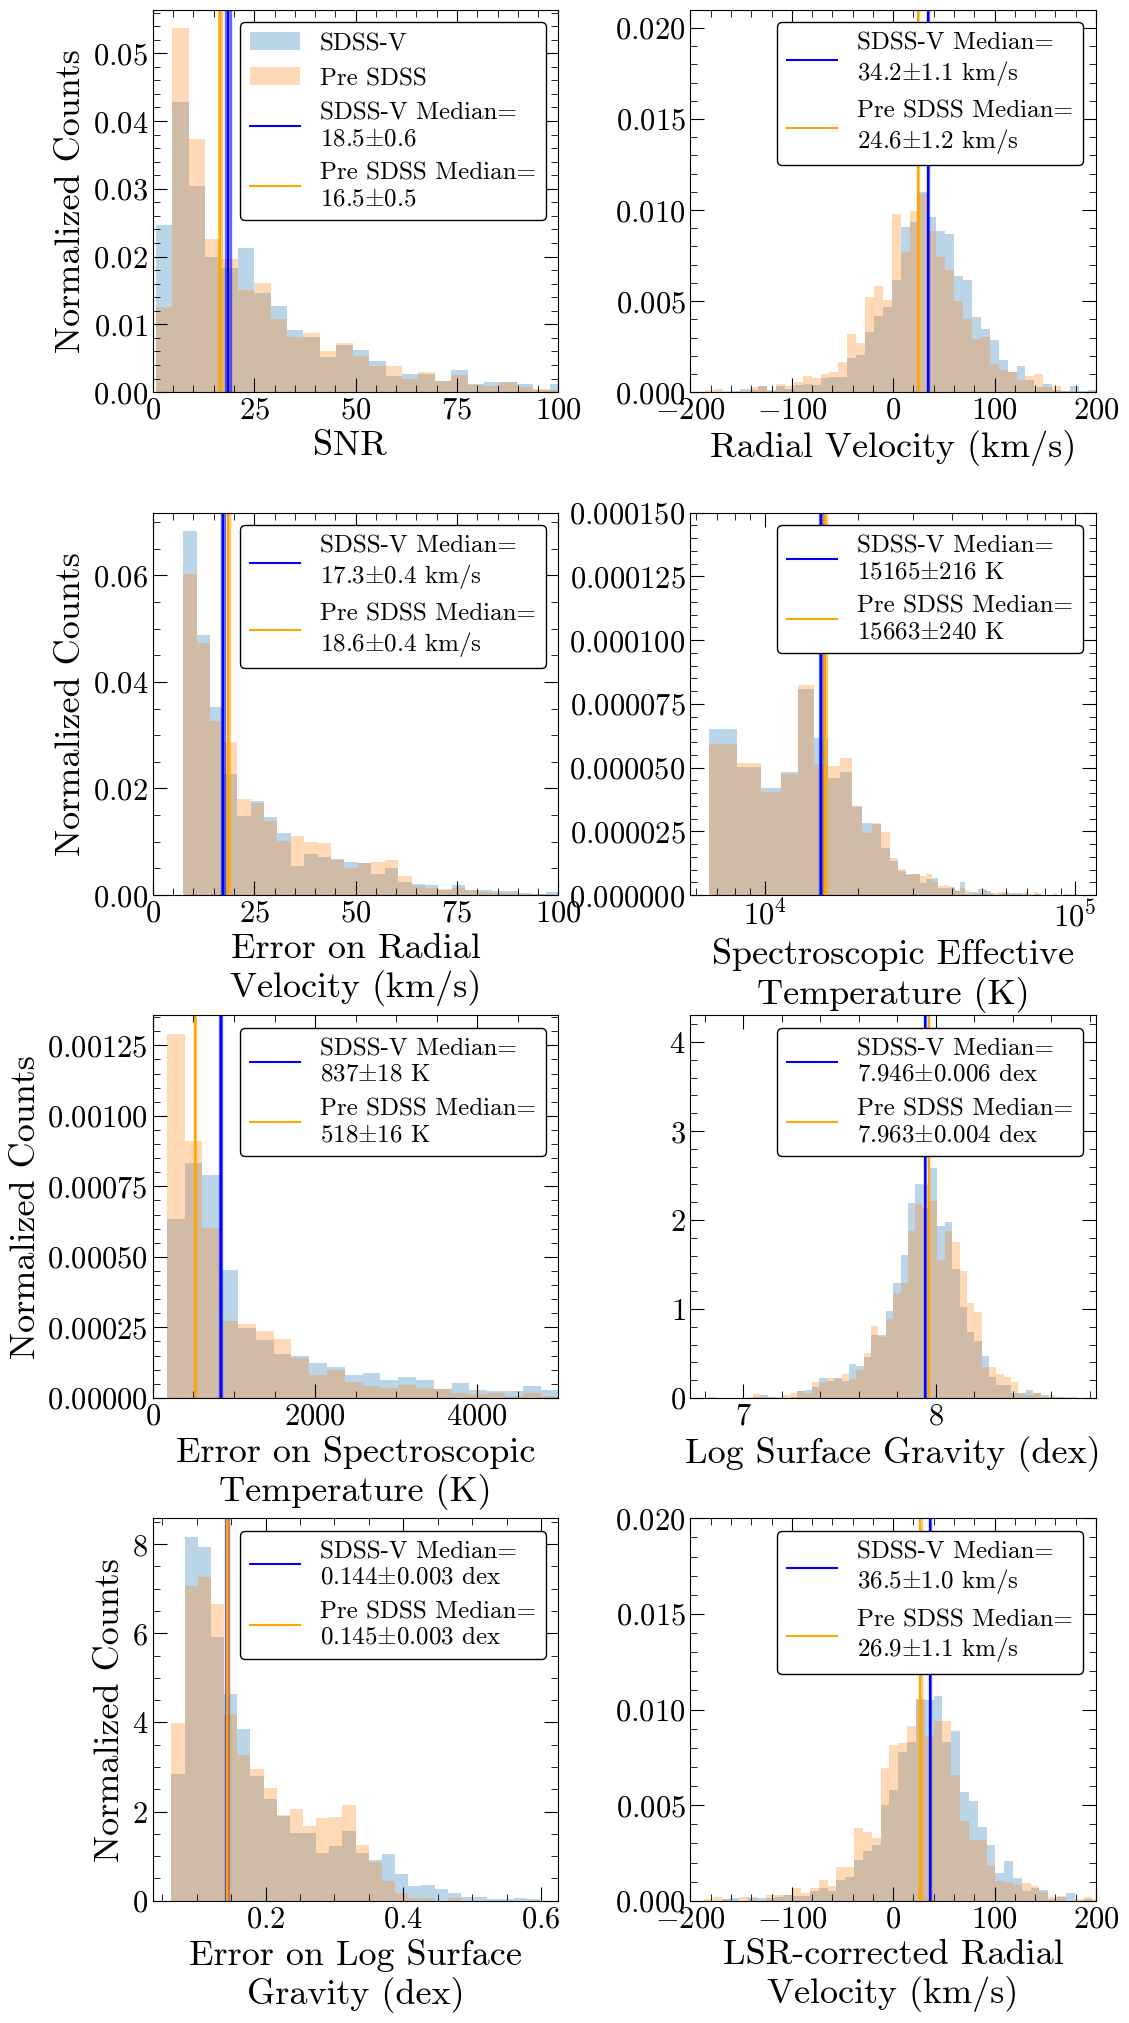

In [69]:
cols=['snr_coadd','rv_corv_coadd','e_rv_corv_coadd_full','teff_prf_coadd',
      'e_teff_prf_coadd_full','logg_prf_coadd','e_logg_prf_coadd_full','rv_corv_lsr']
col_names=['SNR','Radial Velocity','Error on Radial\nVelocity','Spectroscopic Effective\nTemperature',
           'Error on Spectroscopic\nTemperature', 'Log Surface Gravity', 'Error on Log Surface\nGravity',
           'LSR-corrected Radial\nVelocity']
units=['','(km/s)','(km/s)','(K)','(K)','(dex)','(dex)','(km/s)']
units2=['','km/s','km/s','K','K','dex','dex','km/s']
lims=[[0,100],[-200,200],[0,100],0,[0,5000],0,0,[-200,200]]
rounding=[1,1,1,1,1,3,3,1]

fig= plt.figure(figsize=(11,24))
plt.style.use('stefan.mplstyle')

plotnum=1
for i in range(len(cols)):
    #get median and uncertainty on median
    med_sdssv,std_sdssv=bootstrap_median(overlap[cols[i]+'_sdssv'])
    med_esdss,std_esdss=bootstrap_median(overlap[cols[i]+'_esdss'])
    
    fig.add_subplot(5,2,int(plotnum))
    if i==0:
        (n, bins, patches) =plt.hist(overlap[cols[i]+'_sdssv'],density=True,alpha=0.3,label='SDSS-V')
        plt.hist(overlap[cols[i]+'_esdss'],bins=bins,density=True,alpha=0.3,label='Pre SDSS')
    else:
        (n, bins, patches) =plt.hist(overlap[cols[i]+'_sdssv'],density=True,alpha=0.3)
        plt.hist(overlap[cols[i]+'_esdss'],bins=bins,density=True,alpha=0.3)
    plt.xlabel(col_names[i]+' '+units[i])
    try:
        plt.xlim(lims[i][0],lims[i][1])
    except:
        pass
    
    if units2[i]=='K':
        plt.axvline(med_sdssv,color='blue',label='SDSS-V Median=\n'+str(int(med_sdssv))+r'$\mathrm{\pm}$'+str(int(std_sdssv))+' '+units2[i])
        plt.axvspan(med_sdssv-std_sdssv,std_sdssv+med_sdssv,color='blue',alpha=0.5)
        plt.axvline(med_esdss,color='orange',label='Pre SDSS Median=\n'+str(int(med_esdss))+r'$\mathrm{\pm}$'+str(int(std_esdss))+' '+units2[i])
        plt.axvspan(med_esdss-std_esdss,std_esdss+med_esdss,color='orange',alpha=0.5)
    else:
        plt.axvline(med_sdssv,color='blue',label='SDSS-V Median=\n'+str(np.round(med_sdssv,rounding[i]))+r'$\mathrm{\pm}$'+str(np.round(std_sdssv,rounding[i]))+' '+units2[i])
        plt.axvspan(med_sdssv-std_sdssv,std_sdssv+med_sdssv,color='blue',alpha=0.5)
        plt.axvline(med_esdss,color='orange',label='Pre SDSS Median=\n'+str(np.round(med_esdss,rounding[i]))+r'$\mathrm{\pm}$'+str(np.round(std_esdss,rounding[i]))+' '+units2[i])
        plt.axvspan(med_esdss-std_esdss,std_esdss+med_esdss,color='orange',alpha=0.5)
    plt.legend()
    plotnum=plotnum+1
    if i in (0,2,4,6,8):
        plt.ylabel('Normalized Counts')
    if i==3:
        plt.xscale('log')
    if i==1:
        plt.ylim(0,0.021)
    if i==3:
        plt.ylim(0,0.00015)
    if i==5:
        plt.ylim(0,4.3)
    if i==7:
        plt.ylim(0,0.02)
fig.tight_layout(pad=0.1)   

plt.savefig('SDSSV_vs_eSDSS_overlap_full.pdf')#,pad_inches=0.3)


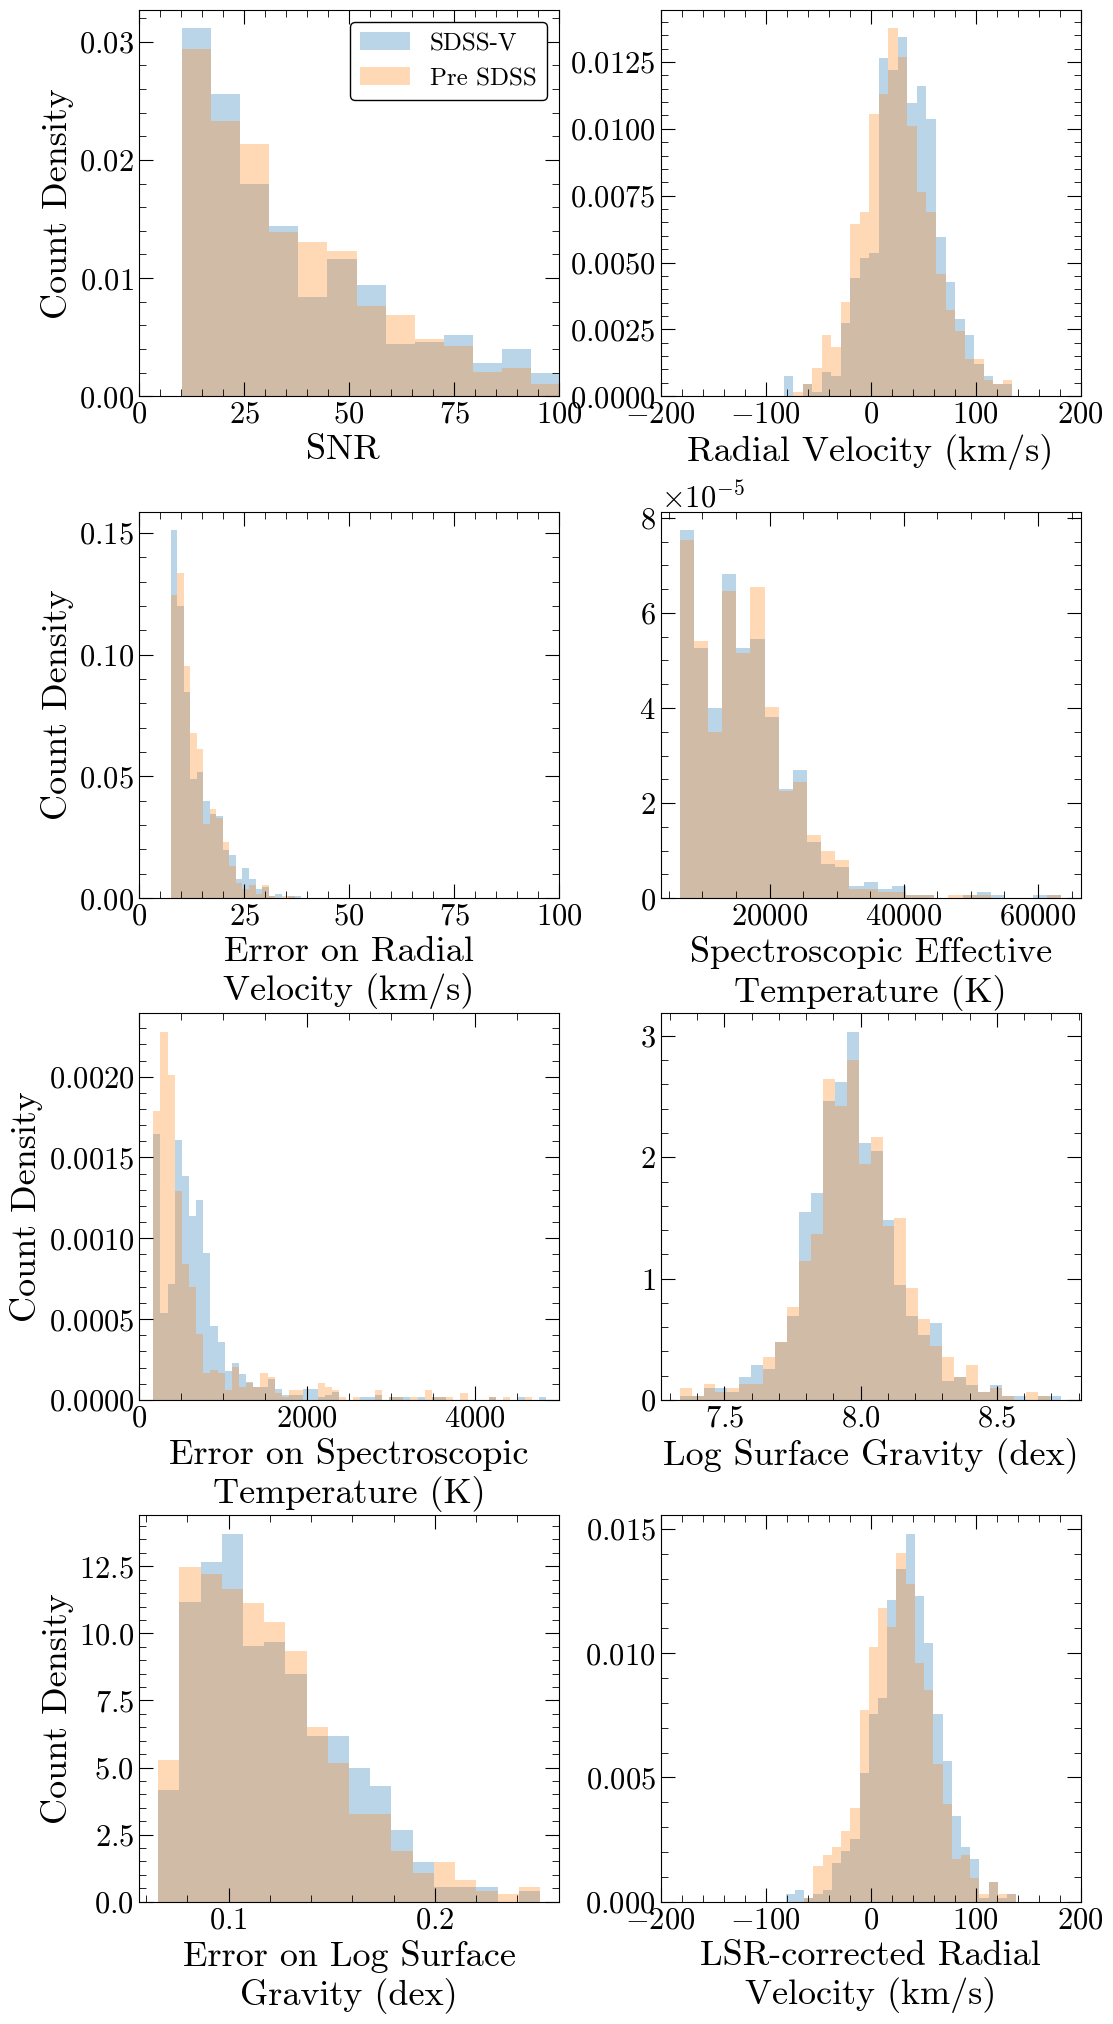

In [70]:
cols=['snr_coadd','rv_corv_coadd','e_rv_corv_coadd_full','teff_prf_coadd',
      'e_teff_prf_coadd_full','logg_prf_coadd','e_logg_prf_coadd_full','rv_corv_lsr']
col_names=['SNR','Radial Velocity','Error on Radial\nVelocity','Spectroscopic Effective\nTemperature',
           'Error on Spectroscopic\nTemperature', 'Log Surface Gravity', 'Error on Log Surface\nGravity',
           'LSR-corrected Radial\nVelocity']
units=['','(km/s)','(km/s)','(K)','(K)','(dex)','(dex)','(km/s)']
lims=[[0,100],[-200,200],[0,100],0,[0,5000],0,0,[-200,200]]

fig= plt.figure(figsize=(11,24))
plt.style.use('stefan.mplstyle')

plotnum=1
for i in range(len(cols)):
    fig.add_subplot(5,2,int(plotnum))
    #if i==9:
    (n, bins, patches) =plt.hist(overlap_tempdep[cols[i]+'_sdssv'],density=True,alpha=0.3,label='SDSS-V')
    plt.hist(overlap_tempdep[cols[i]+'_esdss'],bins=bins,density=True,alpha=0.3,label='Pre SDSS')
    plt.xlabel(col_names[i]+' '+units[i])
    try:
        plt.xlim(lims[i][0],lims[i][1])
    except:
        pass
    plotnum=plotnum+1
    if i==0:
        plt.legend() 
    if i in (0,2,4,6,8):
        plt.ylabel('Count Density')
fig.tight_layout(pad=0.1)   

plt.savefig('SDSSV_vs_eSDSS_overlap_tempdep.pdf')#,pad_inches=0.3)



In [71]:
# get difference between coadd RV/logg in SDSS-V and eSDSS
# and get difference in coadd snrs
e_rv_diffs=overlap['e_rv_corv_coadd_full_sdssv']-overlap['e_rv_corv_coadd_full_esdss']
rv_diffs=overlap['rv_corv_coadd_sdssv']-overlap['rv_corv_coadd_esdss']
e_logg_diffs=overlap['e_logg_prf_coadd_full_sdssv']-overlap['e_logg_prf_coadd_full_esdss']
logg_diffs=overlap['logg_prf_coadd_sdssv']-overlap['logg_prf_coadd_esdss']
snr_diffs=overlap['snr_coadd_sdssv']-overlap['snr_coadd_esdss']

e_rv_diffs_tempdep=overlap_tempdep['e_rv_corv_coadd_full_sdssv']-overlap_tempdep['e_rv_corv_coadd_full_esdss']
rv_diffs_tempdep=overlap_tempdep['rv_corv_coadd_sdssv']-overlap_tempdep['rv_corv_coadd_esdss']
snr_diffs_tempdep=overlap_tempdep['snr_coadd_sdssv']-overlap_tempdep['snr_coadd_esdss']

print('full sample RV std= ',np.std(overlap['rv_corv_coadd_sdssv']),np.std(overlap['rv_corv_coadd_esdss']))
print('full sample mean RV difference= ',np.mean(rv_diffs))
print('full sample mean logg difference= ',np.mean(logg_diffs))

print('')
print('Temp dep sample RV std= ',np.std(overlap_tempdep['rv_corv_coadd_sdssv']),np.std(overlap_tempdep['rv_corv_coadd_esdss']))
print('Temp dep sample mean RV difference= ',np.mean(rv_diffs_tempdep))



full sample RV std=  65.99573876800405 74.6295704694487
full sample mean RV difference=  11.497524977694907
full sample mean logg difference=  -0.014657954545454559

Temp dep sample RV std=  33.10133718990609 34.5612087465562
Temp dep sample mean RV difference=  7.710700800806045


# Photometric vs spectroscopic Teff

In [75]:
def comparison_stats(wd_table,cat1,cat2,meas_param,unit):
    
    error=wd_table[meas_param+'_'+cat1]-wd_table[meas_param+'_'+cat2]
    frac_err=error/wd_table[meas_param+'_'+cat1]
    
    #calculate the rmse between the datasets
    rmse = 0
    for i in range(len(wd_table)):
        rmse += (error[i])**2
    rmse = np.sqrt(rmse / len(wd_table))
    print(r''+meas_param+' RMSE: {:2.3f} '.format(rmse)+unit)
    
    #calculate the median absolute error between the datasets
    mae=np.median(np.abs(error))
    print(meas_param+' MAE: {:2.3f} '.format(mae)+unit)

    #calculate the bias between the datasets
    bias=np.median(error)
    print(meas_param+' BIAS: {:2.3f} '.format(bias)+unit)
    
    #calculate the median absolute fractional error
    med_frac=np.median(np.abs(frac_err))
    print(meas_param+' MED FRAC ERR: {:2.3f} '.format(med_frac))
        
    return(rmse,mae,bias,med_frac,error,frac_err)
def comparison_plots(wd_table,cat1,cat2,meas_param,unit,SDSSType='SDSSV',statx=100,staty=60,statdy=10,lim='default',
                   siegel=True,plthist=True,savefig=False):
    
    directcompplotname='DirectCompPlot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    directcompplottrendname='Trendlines_'+'DirectCompPlot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    AbsErrplotname='AbsErrplot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    Histplotname='Histplot_'+meas_param+'_'+cat1+'_'+cat2+'.png'
    
    #calculate stats
    rmse,mae,bias,med_frac,error,frac_err=comparison_stats(wd_table,cat1,cat2,meas_param,unit)
    
    #plot the agreement between the datasets, with stats
    fig, ax1 =plt.subplots(1,1,figsize=(8,8))
    plt.style.use('stefan.mplstyle')
    ax1.errorbar(wd_table[meas_param+'_'+cat1], wd_table[meas_param+'_'+cat2], xerr = wd_table['e_'+meas_param+'_'+cat1],
                 yerr = wd_table['e_'+meas_param+'_'+cat2], fmt='o', color='blue', ecolor = 'teal')
    ax1.text(statx, staty, 'RMSE = {:.3f} '.format(rmse)+unit)
    ax1.text(statx, staty-1*statdy, 'MAE = {:.3f} '.format(mae)+unit)
    ax1.text(statx, staty-2*statdy, 'Bias = {:.3f} '.format(bias)+unit)
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax1.set_ylabel(r''+meas_param+'('+cat2+') $['+unit+']$')
    maxval=max(max(wd_table[meas_param+'_'+cat1]),max(wd_table[meas_param+'_'+cat2]))
    minval=min(min(wd_table[meas_param+'_'+cat1]),min(wd_table[meas_param+'_'+cat2]))
    #plot 1 to 1 trendline
    ax1.plot([minval,maxval], [minval,maxval], color = 'black',label="1 to 1")
    ax1.legend()
    if lim!='default':
        ax1.set_xlim((lim[0],lim[1]))
        ax1.set_ylim((lim[0],lim[1]))
    if savefig==True:
        plt.savefig('plots/'+directcompplotname)
    plt.show()
    
    #plot the agreement between the datasets, with trendlines
    fig, ax1 =plt.subplots(1,1,figsize=(8,8))
    plt.style.use('stefan.mplstyle')
    ax1.errorbar(wd_table[meas_param+'_'+cat1], wd_table[meas_param+'_'+cat2], xerr = wd_table['e_'+meas_param+'_'+cat1],
                 yerr = wd_table['e_'+meas_param+'_'+cat2], fmt='o', color='blue', ecolor = 'teal')
    ax1.set_xlabel(r''+meas_param+' ('+cat1+') $['+unit+']$')
    ax1.set_ylabel(r''+meas_param+'('+cat2+') $['+unit+']$')
    #plot 1 to 1 trendline
    ax1.plot([minval,maxval], [minval,maxval], color = 'black',label="1 to 1")
    #add a linear trendlines
    if siegel==True:
        coef = stats.siegelslopes(wd_table[meas_param+'_'+cat2], wd_table[meas_param+'_'+cat1])
        poly1d_fn = np.poly1d(coef) 
        ax1.plot([minval,maxval], poly1d_fn([minval,maxval]), label="Trendline\n"+str(np.round(coef[0],2))+"*x+"+str(np.round(coef[1],2)))
    else:
        coef= np.polyfit(wd_table[meas_param+'_'+cat1],wd_table[meas_param+'_'+cat2],1)
        poly1d_fn= np.poly1d(coef) 
        ax1.plot([minval,maxval], poly1d_fn([minval,maxval]), label="Trendline\n"+str(np.round(coef[0],2))+"*x+"+str(np.round(coef[1],2)))
    ax1.legend()
    if lim!='default':
        ax1.set_xlim((lim[0],lim[1]))
        ax1.set_ylim((lim[0],lim[1]))
    if savefig==True:
        plt.savefig('plots/'+directcompplottrendname)
    plt.show()



teff RMSE: 10262.779 K
teff MAE: 872.217 K
teff BIAS: -527.667 K
teff MED FRAC ERR: 0.059 


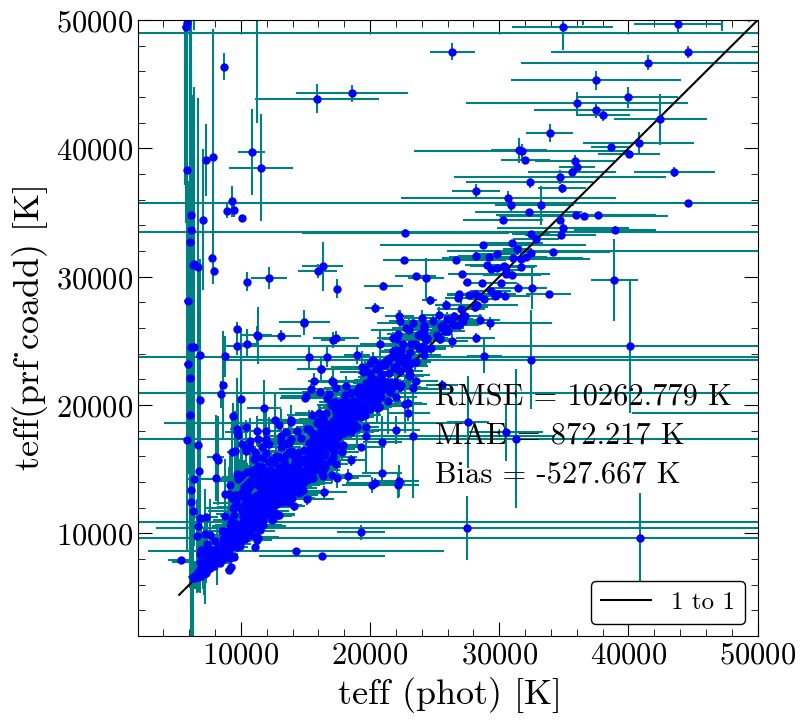

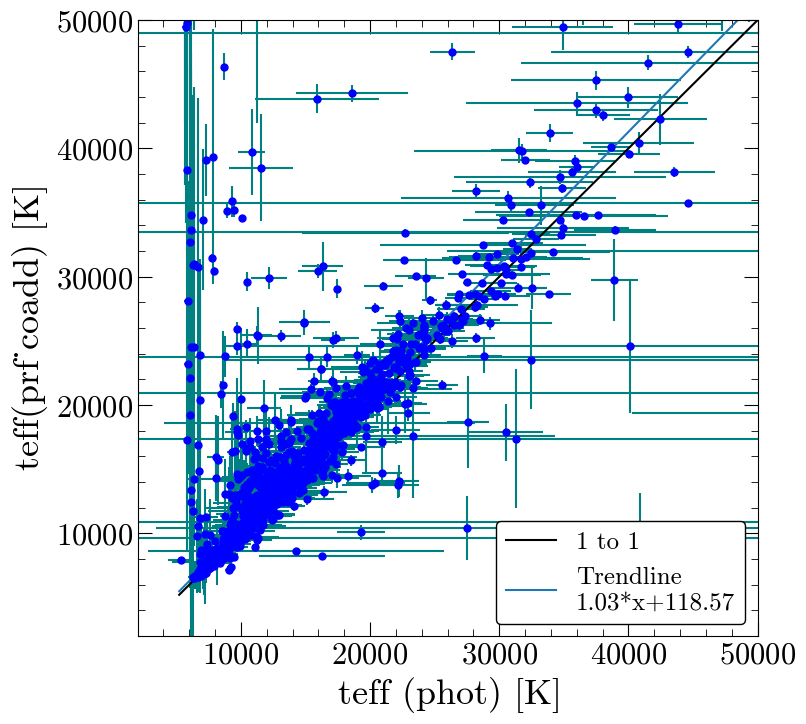

teff RMSE: 10938.071 K
teff MAE: 822.689 K
teff BIAS: -502.556 K
teff MED FRAC ERR: 0.048 


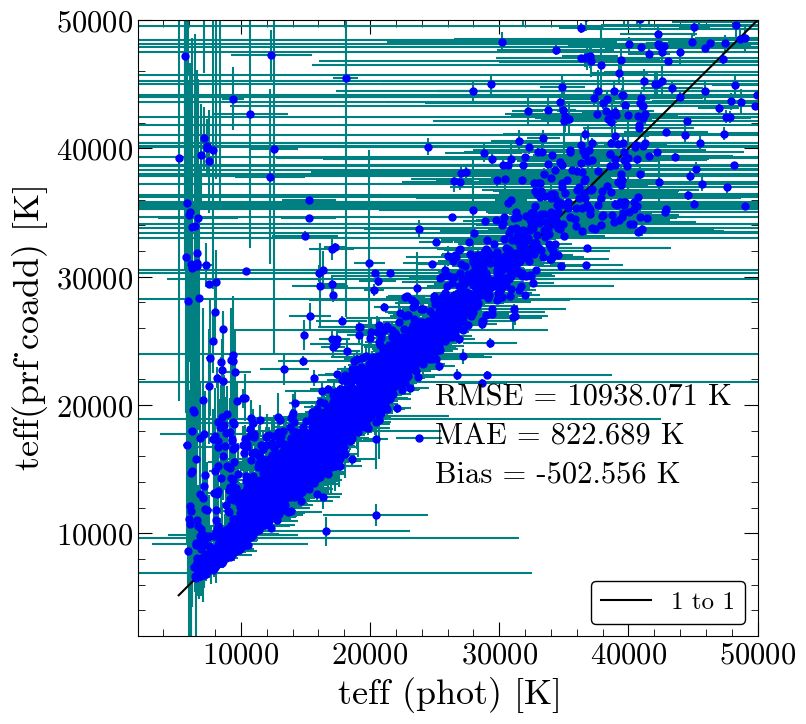

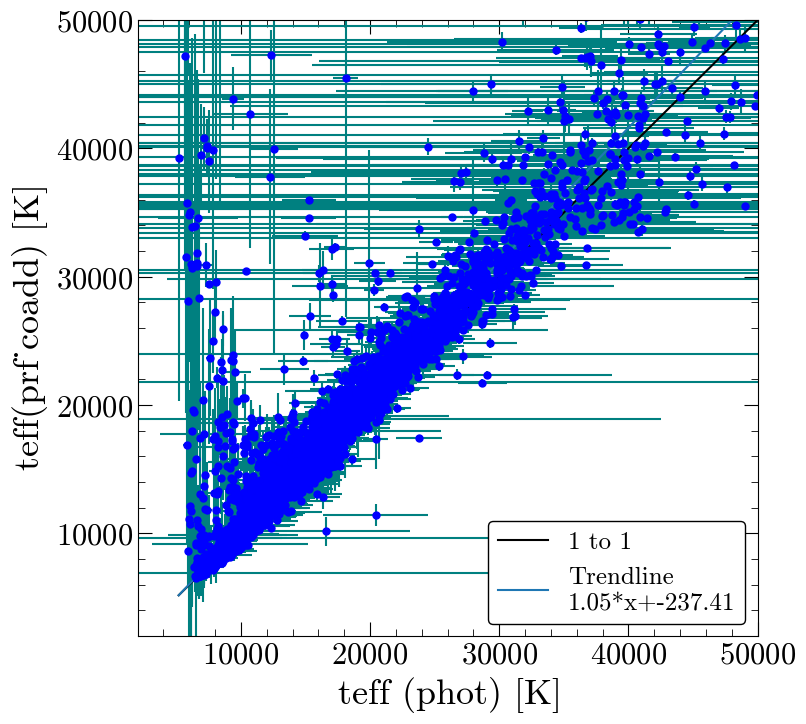

60
1383
0.04338394793926247

98
4859
0.02016875900391027


In [76]:
#compare the spectroscopic and photometric temperatures
SDSSV_tab_cut=SDSSV_tab.query('1600<teff_phot<129000 and 1600<teff_prf_coadd<129000 and snr_coadd>20').drop_duplicates(subset='gaia_dr3_source_id')
SDSSV_tab_cut=SDSSV_tab_cut.query('(phot_used==1 & phot_err_sdss<0.05) or (phot_used==2 & phot_err_gaia<10)')
#reset the indices
indices=np.arange(0,len(SDSSV_tab_cut))
SDSSV_tab_cut.set_index(indices,inplace=True)

comparison_plots(SDSSV_tab_cut,'phot','prf_coadd','teff','K',statx=25000,staty=20000,statdy=3000,lim=(2000,50000),
                   siegel=True,plthist=True,savefig=False)

#compare the spectroscopic and photometric temperatures
eSDSS_tab_cut=eSDSS_tab.query('1600<teff_phot<129000 and 1600<teff_prf_coadd<129000 and snr_coadd>20').drop_duplicates(subset='gaia_dr3_source_id')
eSDSS_tab_cut=eSDSS_tab_cut.query('(phot_used==1 & phot_err_sdss<0.05) or (phot_used==2 & phot_err_gaia<10)')
#reset the indices
indices=np.arange(0,len(eSDSS_tab_cut))
eSDSS_tab_cut.set_index(indices,inplace=True)

comparison_plots(eSDSS_tab_cut,'phot','prf_coadd','teff','K',statx=25000,staty=20000,statdy=3000,lim=(2000,50000),
                   siegel=True,plthist=True,savefig=False)

#number of anomalous 
print(len(SDSSV_tab_cut.query('5000<teff_phot<15000 and 20000<teff_prf_coadd')))
print(len(SDSSV_tab_cut))
print(len(SDSSV_tab_cut.query('5000<teff_phot<15000 and 20000<teff_prf_coadd'))/len(SDSSV_tab_cut))

print('')

print(len(eSDSS_tab_cut.query('5000<teff_phot<15000 and 20000<teff_prf_coadd')))
print(len(eSDSS_tab_cut))
print(len(eSDSS_tab_cut.query('5000<teff_phot<15000 and 20000<teff_prf_coadd'))/len(eSDSS_tab_cut))

# Completeness Estimate
### ONLY CONSIDER WDs WITHIN 1000 pc
- To estimate completeness as function of distance:
    - Get the data from the highly complete 100pc sample of https://ui.adsabs.harvard.edu/abs/2023MNRAS.518.5106J/abstract and use this to normalize our results
        - Link to catalog: https://cdsarc.cds.unistra.fr/viz-bin/cat/J/MNRAS/518/5106
    - Compare our counts as function of distance to assumption of constant WD number density as function of distance
- To estimate completeness as function of WD mass:
    - Compare our WD mass distribution to the highly complete 100pc sample (only for nearby WDs)
    - OR compare our WD mass distribution to the completeness-corrected mass distribution of https://ui.adsabs.harvard.edu/abs/2015MNRAS.452.1637R/abstract
- To estimate completeness as function of WD luminosity/teff:
    - Compare our WD teff distribution to the highly complete 100pc sample (only for nearby WDs)
    - OR compare our WD luminosity function to the completeness-corrected WDLF of https://ui.adsabs.harvard.edu/abs/2015MNRAS.452.1637R/abstract
    
### Jimenez Catalog
- In this work, we first built a highly complete volume-limited sample consisting in 12 718 WDs within 100 pc from the Sun.
- Classification of DA and non-DA WDs with an accuracy >90 per cent, tested in already spectroscopically labelled objects
- The expected contamination in our WD catalogue is very low (<0.1 per cent).
- Recently, from the GaiaDR2 catalogue, Hollands et al. (2018) estimated a space-density of 4.49 × 10−3 pc−3 for the WD population within 20 pc from the Sun. Assuming the same space-density up to 100 pc, we would expect ∼18,800 WD in this volume. This implies that the completeness of our sample is ∼70 per cent of the entire 100 pc WD population. This estimation is in agreement with Torres et al. (2022).
- Summing up the contribution of missing sources, we conclude that <10 per cent of WDs located within 100 pc are not part of our 100pc WDs classification from Gaia-DR3 & VO 5109 MNRAS 518, 5106–5122 (2023) catalogue in the colour range GBP − GRP < 0.86 mag; however, in the reddest end of the WD sequence completeness decreases and the missing source would be mainly due to the limitations of Gaia capabilities in both astrometry and photometry.
- Classified DAs and NonDAs for entire population with an effective temperature above 5500 K. A total of 8150 objects (representing the 99 per cent of objects of our catalogue in that range of temperatures) have been spectrally classified in these two main groups.
- Our analysis also allowed us to derive stellar parameters by means of photometric interpolation in updated cooling sequences from La Plata models with hydrogen-pure or helium-pure atmosphere models. This way we built, e.g. the mass distribution for DA and non-DA stars. Our results showed a bimodality in the DA mass distribution, as previously commented and already reported in the literature, with a main peak at ∼0.58 M and a secondary one at ∼0.8 M. An extended tail for WDs more massive than 0.8 M is also observed for Teff > 12 000 K that disappears for lower temperatures due to a combination of crystallization and other physical process along with incompleteness bias effects. It was also noticed that for temperatures below 7000 K the second peak fades. A possible cause is that for this low range of temperatures, crystallization starts to happen for WD less massive than 0.8 M, smoothing out the mass distribution between the two peaks

In [6]:
completeness=pd.concat([SDSSV_tab[['gaia_dr3_source_id','mass_rad_theory','teff_phot','r_med_geo']],
                        eSDSS_tab[['gaia_dr3_source_id','mass_rad_theory','teff_phot','r_med_geo']]])
completeness=completeness.drop_duplicates(subset='gaia_dr3_source_id')
completeness=completeness.query('r_med_geo<1000')
#reset the indices
indices=np.arange(0,len(completeness))
completeness.set_index(indices,inplace=True)

Sky Coverage Percentage: 41.69%


Text(0.5, 1.0, 'Sky Coverage - 41.69%')

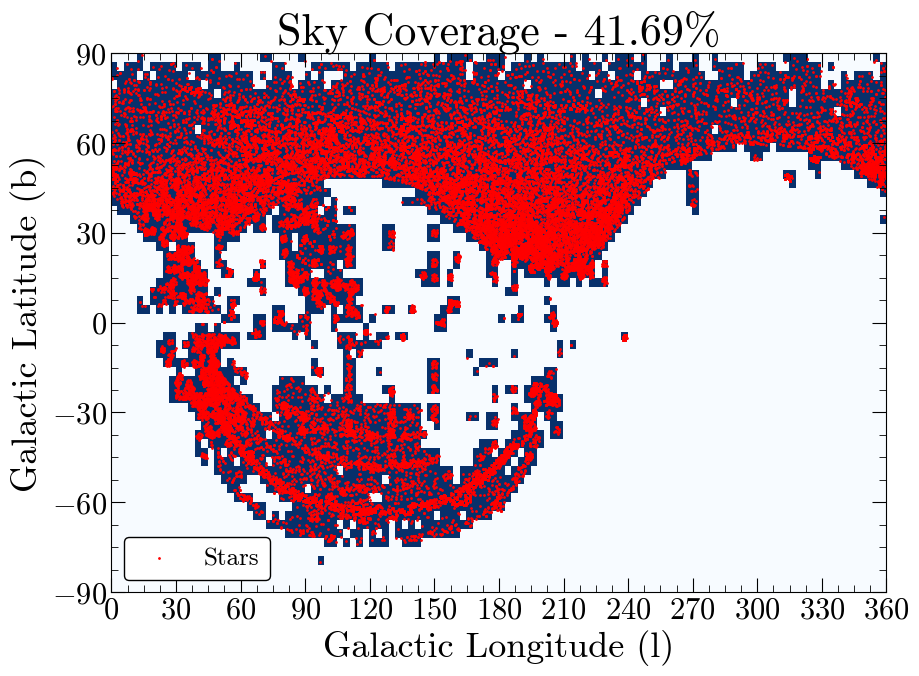

In [7]:
#characterize the sky coverage of our SDSS-V and eSDSS samples for objects within 1000 pc

l_coords=np.append(np.array(SDSSV_tab['l']),np.array(eSDSS_tab['l']))
b_coords=np.append(np.array(SDSSV_tab['b']),np.array(eSDSS_tab['b']))
stars = np.array(list(zip(l_coords, b_coords)))

# Define the grid resolution (e.g., 1 degree by 1 degree)
longitude_resolution = 3 # degrees
latitude_resolution = 3   # degrees

# Determine the range of coordinates
longitude_min, longitude_max = 0, 360
latitude_min, latitude_max = -90, 90

# Create a set to store unique grid cells
grid_cells = set()

# Map stars to grid cells
for star in stars:
    l, b = star
    # Map to grid cell (rounded to nearest resolution)
    grid_cell = (int(l // longitude_resolution), int(b // latitude_resolution))
    grid_cells.add(grid_cell)

# Calculate the total number of grid cells
total_cells = ((longitude_max - longitude_min) // longitude_resolution) * \
              ((latitude_max - latitude_min) // latitude_resolution)

# Calculate the percentage of sky covered
coverage_percent = len(grid_cells) / total_cells * 100

print(f"Sky Coverage Percentage: {coverage_percent:.2f}%")

# Plot the sky coverage
# Create a grid of longitude and latitude values
longitude_grid = np.arange(longitude_min, longitude_max, longitude_resolution)
latitude_grid = np.arange(latitude_min, latitude_max, latitude_resolution)

# Create a 2D array to represent the grid, initially all cells are empty (False)
grid = np.zeros((len(latitude_grid), len(longitude_grid)), dtype=bool)

# Fill the grid with True for occupied cells
for cell in grid_cells:
    l_index = int(cell[0] - longitude_min/longitude_resolution)
    b_index = int(cell[1] - latitude_min/latitude_resolution)
    grid[b_index, l_index] = True
    
# Plot the grid
fig, ax = plt.subplots(figsize=(10, 7))

# Draw the grid lines
ax.set_xticks(np.arange(0, 361, 30))
ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xlabel('Galactic Longitude (l)')
ax.set_ylabel('Galactic Latitude (b)')

# Plot the filled grid cells
ax.imshow(grid, cmap='Blues', origin='lower', extent=[longitude_min, longitude_max, latitude_min, latitude_max])

# Overlay the star positions on the plot
ax.scatter(stars[:, 0], stars[:, 1], color='red', s=1, label="Stars")

ax.legend()
plt.title(f"Sky Coverage - {coverage_percent:.2f}%")


In [8]:
dist_bins=np.arange(0,1100,100)
print(dist_bins)

estimated_density=4.49*10**(-3) #WD/pc^3

#get the range, center, and volume for each bin
dist_bin_ranges=[]
dist_bin_centers=[]
dist_bin_theory_counts=[]
dist_bin_theory_counts_adj=[]
for i in range(len(dist_bins)-1):
    array=[dist_bins[i],dist_bins[i+1]]
    half=0.5*(dist_bins[i]+dist_bins[i+1])
    vol=(4./3.)*np.pi*(dist_bins[i+1]**3-dist_bins[i]**3)
    theory_count=vol*estimated_density
    dist_bin_ranges.append(array)
    dist_bin_centers.append(half)
    dist_bin_theory_counts.append(theory_count)
    dist_bin_theory_counts_adj.append(0.4*theory_count)
dist_bin_nums=np.arange(0,len(dist_bin_ranges))


[   0  100  200  300  400  500  600  700  800  900 1000]


In [9]:
def bin_by_dist(table,verbose=False):
    #bin by distance
    dist_bin_ids=[]
    dist_bin_id_ranges=[]
    dist_bin_id_centers=[]
    dist_bin_id_theory_counts=[]
    for i in range(len(table)):
        dist_val=table['r_med_geo'][i]
        for j in range(len(dist_bin_ranges)):
            if dist_bin_ranges[j][0]<=dist_val<dist_bin_ranges[j][1]:
                dist_bin_ids.append(j)
                dist_bin_id_ranges.append(dist_bin_ranges[j])
                dist_bin_id_centers.append(dist_bin_centers[j])
    table['dist_bin_id']=dist_bin_ids
    table['dist_bin_range']=dist_bin_id_ranges
    table['dist_bin_center']=dist_bin_id_centers
    
    if verbose==True:
        for i in range(len(dist_bin_ranges)):
            bin_num=dist_bin_nums[i]
            bin_range=dist_bin_ranges[i]
            tmp=table.query('dist_bin_id==@bin_num')
            print('Bin id=', bin_num,' Bin range=',bin_range,' pc, Number of WDs in bin=',len(tmp))
            
    return(table)

In [10]:
completeness=bin_by_dist(completeness,verbose=True)

distance_bin_counts = completeness.groupby('dist_bin_id').size().to_list()

Bin id= 0  Bin range= [0, 100]  pc, Number of WDs in bin= 1033
Bin id= 1  Bin range= [100, 200]  pc, Number of WDs in bin= 4847
Bin id= 2  Bin range= [200, 300]  pc, Number of WDs in bin= 5336
Bin id= 3  Bin range= [300, 400]  pc, Number of WDs in bin= 4433
Bin id= 4  Bin range= [400, 500]  pc, Number of WDs in bin= 3019
Bin id= 5  Bin range= [500, 600]  pc, Number of WDs in bin= 1866
Bin id= 6  Bin range= [600, 700]  pc, Number of WDs in bin= 1218
Bin id= 7  Bin range= [700, 800]  pc, Number of WDs in bin= 875
Bin id= 8  Bin range= [800, 900]  pc, Number of WDs in bin= 677
Bin id= 9  Bin range= [900, 1000]  pc, Number of WDs in bin= 446


In [11]:
print('percent completeness in each distance bin')
print((np.array(distance_bin_counts)/np.array(dist_bin_theory_counts))*100)
print((np.array(distance_bin_counts)/np.array(dist_bin_theory_counts_adj))*100)

percent completeness in each distance bin
[5.49244063 3.68162906 1.49323194 0.63703172 0.26314694 0.10902731
 0.05099277 0.02752874 0.016588   0.00875045]
[13.73110158  9.20407265  3.73307984  1.5925793   0.65786736  0.27256827
  0.12748193  0.06882186  0.04147     0.02187614]


In [12]:
# read in 100pc sample data
jimenez_astpy = Table.read('data/J_MNRAS_518_5106_catalog.dat.gz.fits')
jimenez=jimenez_astpy.to_pandas()
jimenez_DAs=jimenez.query("SpT==b'DA    '")

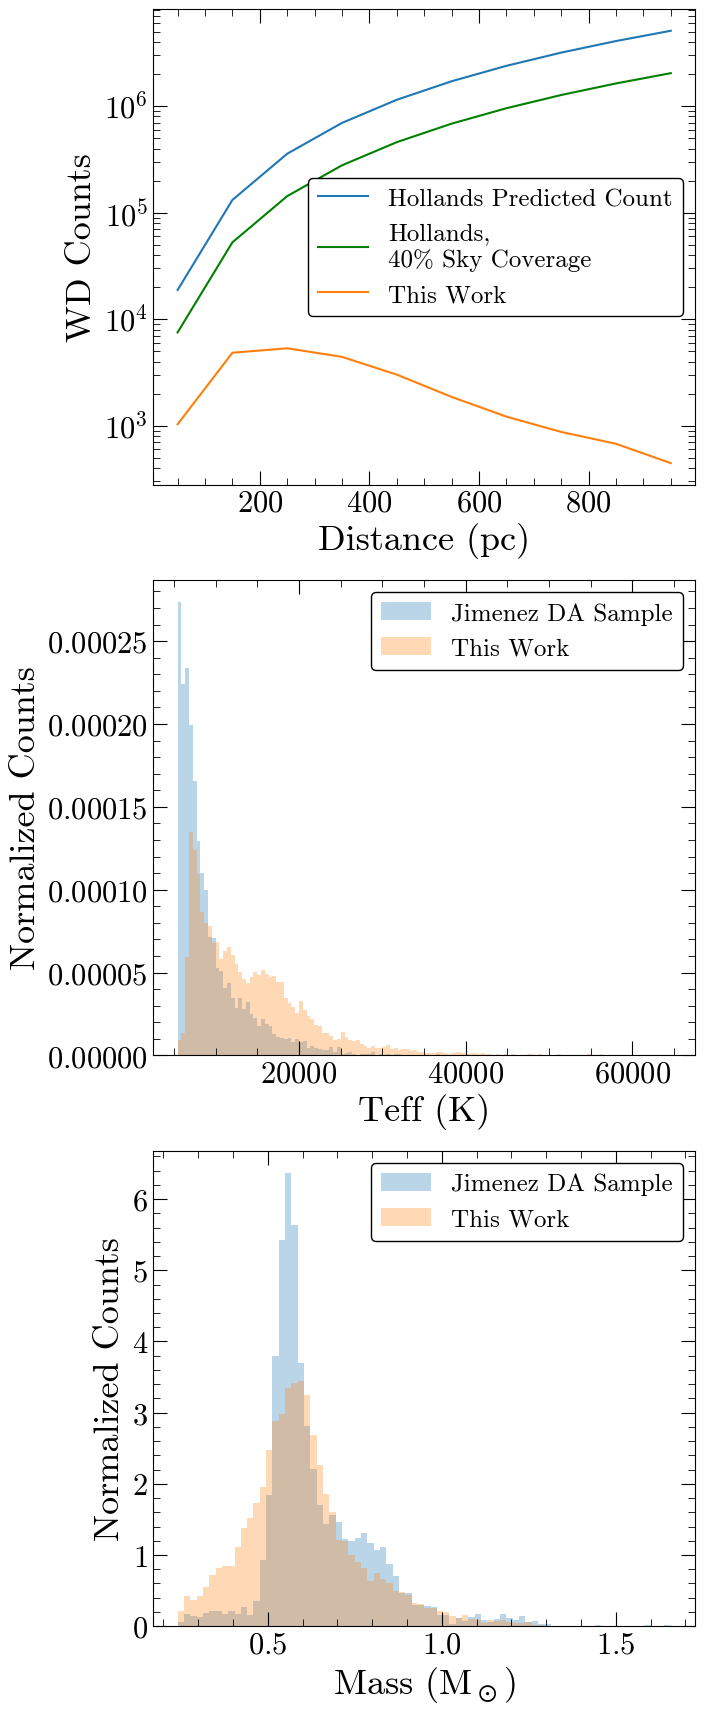

In [13]:
fig,(ax1,ax2,ax3)=plt.subplots(3,1,figsize=(7,21))

ax1.plot(dist_bin_centers,dist_bin_theory_counts,label='Hollands Predicted Count')
ax1.plot(dist_bin_centers,dist_bin_theory_counts_adj,color='green',label='Hollands,\n40% Sky Coverage')
ax1.plot(dist_bin_centers,distance_bin_counts,label='This Work')

(n, bins, patches) =ax2.hist(jimenez_DAs['Teff'],density=True,alpha=0.3,label='Jimenez DA Sample')
ax2.hist(completeness['teff_phot'],bins=bins,density=True,alpha=0.3,label='This Work')

(n, bins, patches) =ax3.hist(jimenez_DAs['Mass'],density=True,alpha=0.3,label='Jimenez DA Sample')
ax3.hist(completeness['mass_rad_theory'],density=True,alpha=0.3,bins=bins,label='This Work')

ax1.legend()
ax2.legend()
ax3.legend()

ax1.set_ylabel('WD Counts')
ax1.set_xlabel('Distance (pc)')
ax1.set_yscale('log')

ax2.set_ylabel('Normalized Counts')
ax2.set_xlabel('Teff (K)')

ax3.set_ylabel('Normalized Counts')
ax3.set_xlabel('Mass ($M_\odot$)')

plt.savefig('complete.pdf')